# AMI Deconvolutions


In [1]:
import os
import jax
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-02-05 18:36:28.386836: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/NGC1068/calslope/"
else:
    cache = "/Volumes/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/NGC1068/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/NGC1068/")

state = np.load(
    os.path.join(model_cache, "ode/test_state.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
# Build the ramp model
n_latent = 6
keys = jr.split(jr.PRNGKey(0), 3)
encoder = amigo.latent_ode_models.LatentEncoder(
    n_latent=n_latent, width=6, depth=2, key=keys[0], pools=[0, 1]
)
latent_ode = amigo.latent_ode_models.LatentODE(
    n_latent=n_latent, width=3, depth=2, key=keys[1]
)
decoder = amigo.latent_ode_models.LatentDecoder(
    n_latent=n_latent, depth=3, key=keys[2], up_samples=[1, 2], out_channels=2
)

# ramp = LatentODERamp(encoder=encoder, latent_ode=latent_ode, decoder=decoder)
ode_ramp = amigo.latent_ode_models.GainDiffusionRamp(
    encoder=encoder, latent_ode=latent_ode, decoder=decoder
)

# Loading in data

In [4]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 4)

In [5]:
source_size = 120
shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = dorito.build_model.wavelet_prior(source_size)

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    # cal_files[0:3],
    # cal_files,
    [],
    # sci_files,
    sci_files[0:1],
    # [],
    state=state,
    ramp_model=ode_ramp,
    extra_priors={
        # "wavelets": shearlets,
        # "wavelets": wavelets,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    # shearletSystem=shearletSystem,
    # sci_fit=dorito.model_fits.DynamicResolvedFit,
    sci_fit=dorito.model_fits.ResolvedFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init state
init_state = np.load(init_state_cache + "F480M.npy", allow_pickle=True)[()]
for p in [
    "positions",
    "fluxes",
    "aberrations",
    "log_distribution",
]:
    params[p] = init_state[p]
model = model.set("params", params)

model = model.set("FF", np.ones_like(model.FF))

No Teff found for NGC1068, defaulting to 4500K


In [6]:
for fs in [sci_fits, cal_fits]:
    print(f"{len(fs)} Files:")
    for f in fs:

        img = np.where(f.badpix, np.nan, f.ramp[-1])

        print(
            f"\
            TARG: {f.star}\
            FILTER: {f.filter}\
            NGROUPS: {f.ngroups}\
            PEAK: {int(np.nanmax(img))}, {np.nanmax(img) / 2**16 :.1%} sat. \
        "
        )
    print()

for fs in [sci_fits, cal_fits]:
    print(f"{len(fs)} Files:")

    for f in fs:
        grps = np.array([np.where(f.badpix, np.nan, grp) for grp in f.ramp])
        top = grps[-1]
        print(
            f"\
            TARG: {f.star}\
            FILTER: {f.filter}\
            NGROUPS: {f.ngroups}\
            PEAK: {int(np.nanmax(top))}, {np.nanmax(top) / 2**16 :.1%} sat. \
        "
        )

        for i, grp in enumerate(grps):
            print(
                f"GROUP {i}, PEAK: {int(np.nanmax(grp))}, {np.nanmax(grp) / 2**16 :.1%} sat."
            )
        # print(f"PEAK: {int(np.nanmax(img))}, {np.nanmax(img) / 2**16 :.1%} sat.")
        print()

1 Files:
            TARG: NGC1068            FILTER: F480M            NGROUPS: 4            PEAK: 28817, 44.0% sat.         

0 Files:

1 Files:
            TARG: NGC1068            FILTER: F480M            NGROUPS: 4            PEAK: 28817, 44.0% sat.         
GROUP 0, PEAK: 16461, 25.1% sat.
GROUP 1, PEAK: 20576, 31.4% sat.
GROUP 2, PEAK: 24621, 37.6% sat.
GROUP 3, PEAK: 28817, 44.0% sat.

0 Files:


F480M
F480M


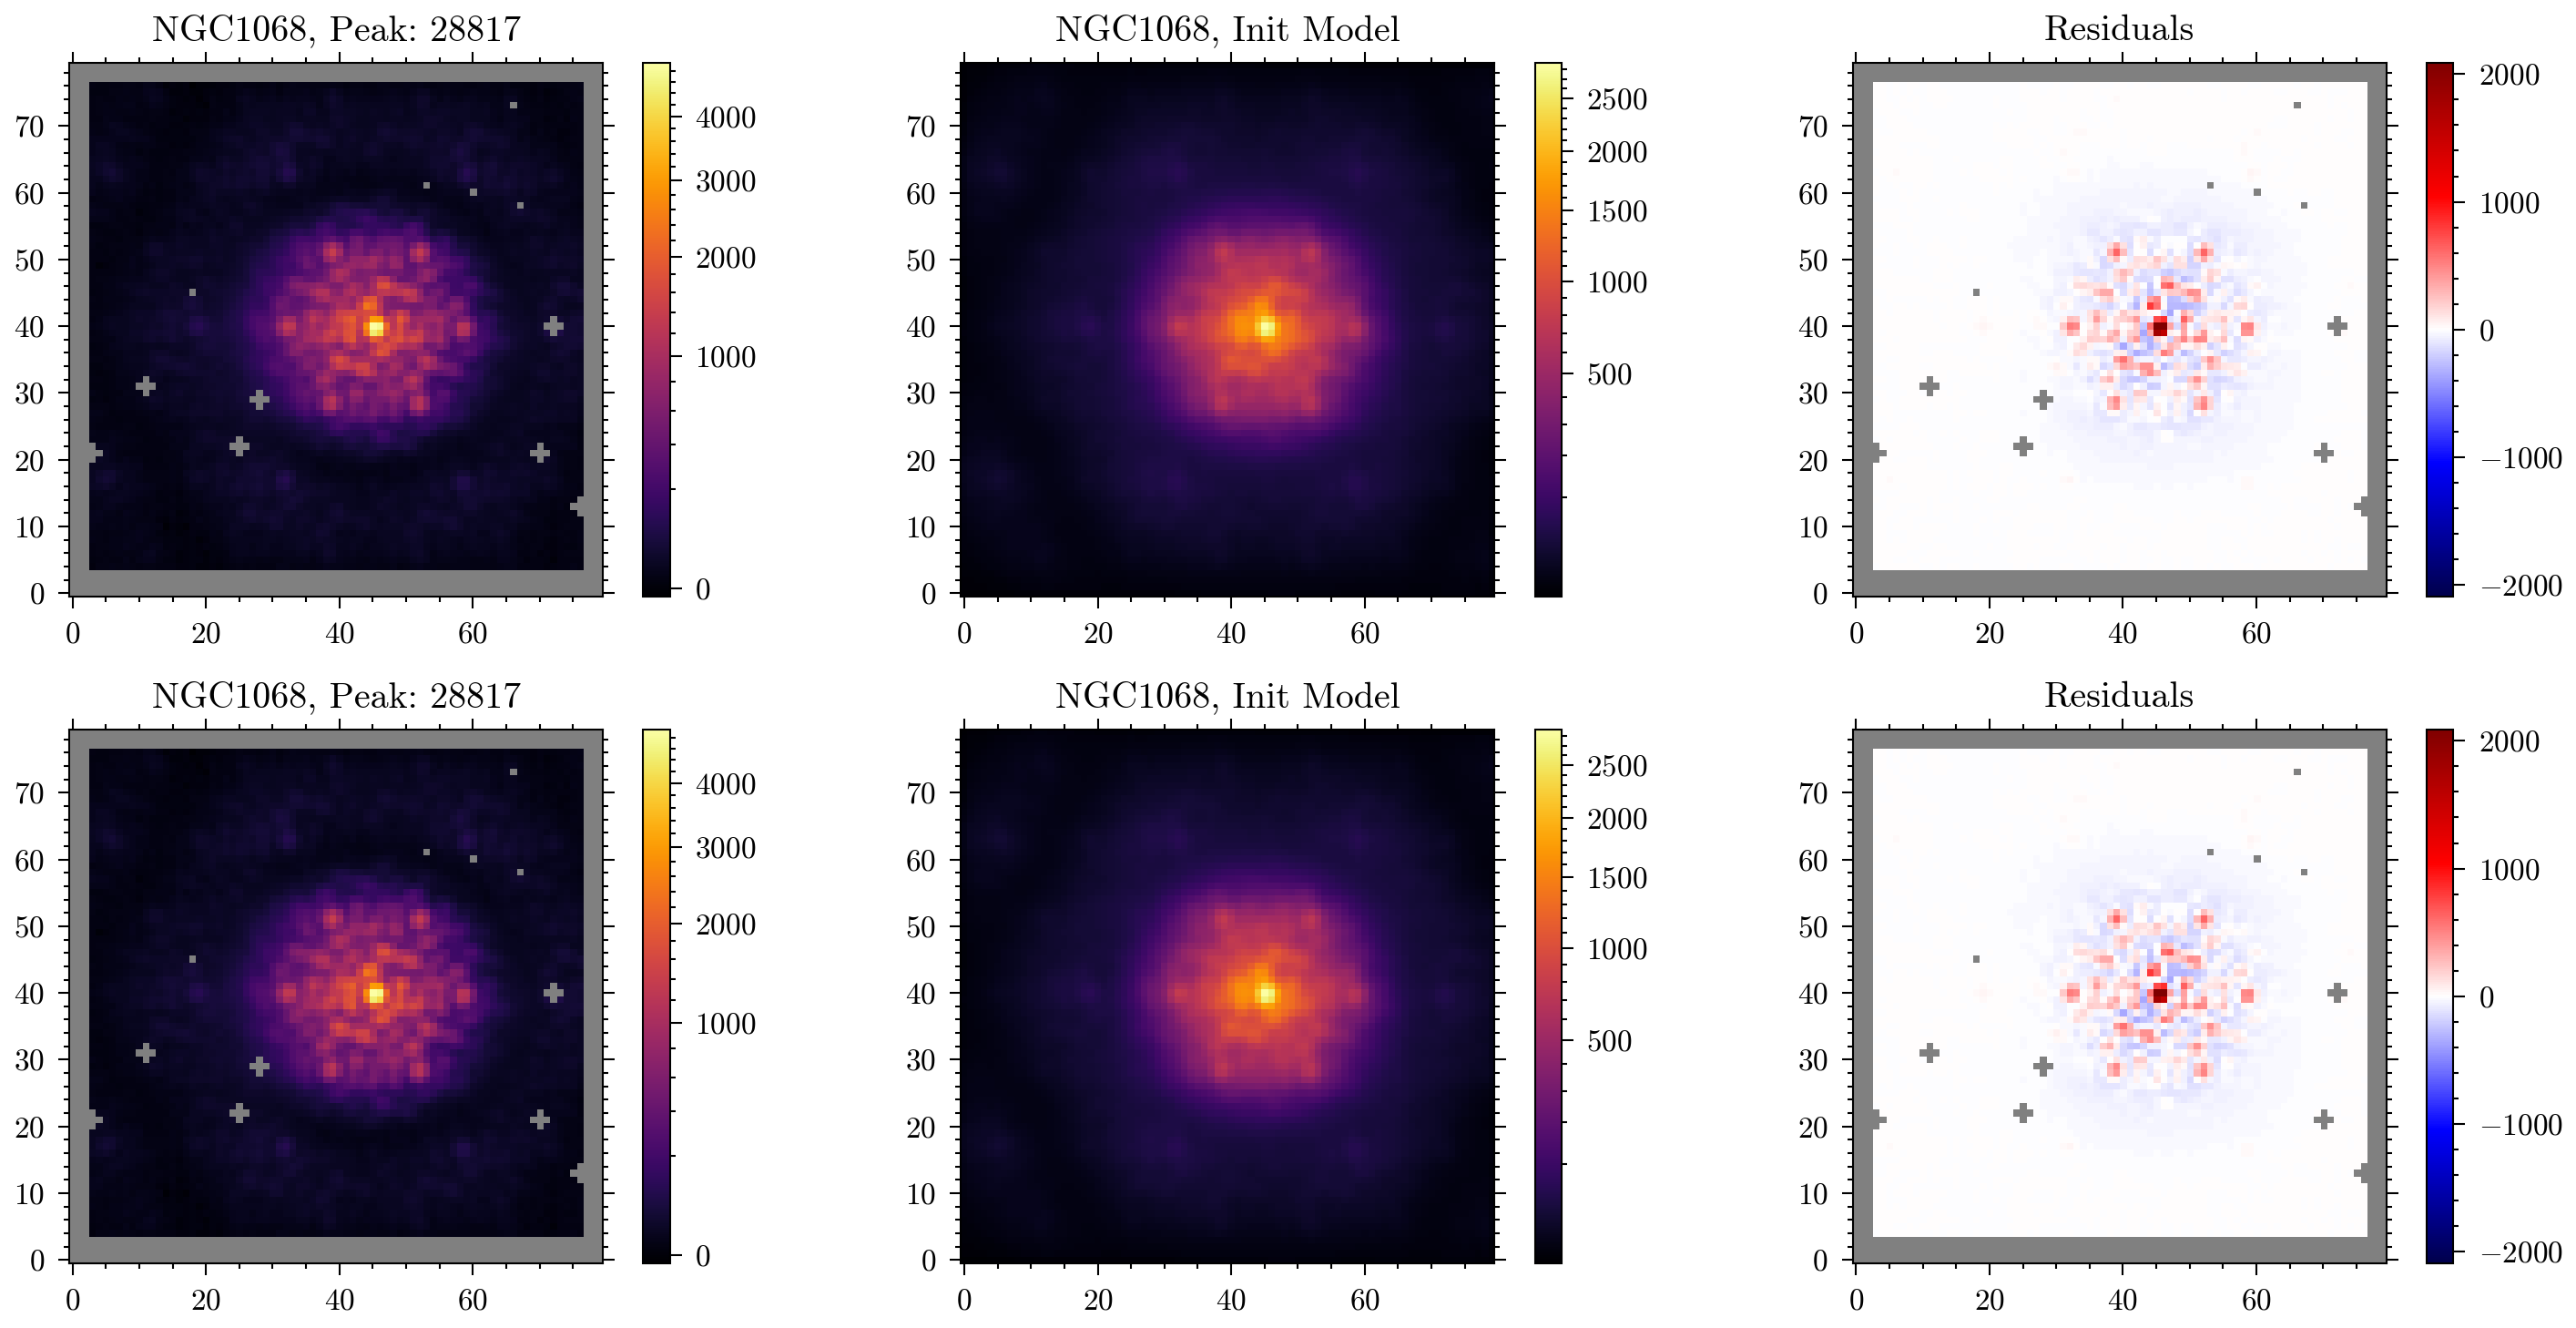

In [7]:
plt.subplots(2, 3, figsize=(10, 5))

for i in [0, -1]:
    fit = fits[i]
    slope = fits[i].slopes[-1]
    ramp = fits[i].ramp[-1]
    badpix = fits[i].badpix
    ppcount = np.nanmax(np.where(badpix, np.nan, ramp))

    print(fit.filter)

    x = np.where(badpix, np.nan, slope)
    plt.subplot(2, 3, 3 * abs(i) + 1)
    plt.imshow(x, cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
    plt.title(f"{fits[i].star}, Peak: {int(ppcount)}")
    plt.colorbar()

    init_slopes = fit(model)
    plt.subplot(2, 3, 3 * abs(i) + 2)
    plt.imshow(init_slopes[-1], cmap=inferno, norm=mpl.colors.PowerNorm(0.5))
    plt.title(f"{fits[i].star}, Init Model")
    plt.colorbar()

    plt.subplot(2, 3, 3 * abs(i) + 3)
    plt.imshow(x - init_slopes[-1], cmap=seismic, norm=mpl.colors.CenteredNorm())
    plt.title(f"Residuals")
    plt.colorbar()


plt.tight_layout()
plt.show()

In [8]:
# for grp, slope in zip(exposures[1].ramp[1:], exposures[1].slopes):

#     img = np.where(exposures[1].badpix, np.nan, grp)
#     slop = np.where(exposures[1].badpix, np.nan, slope)
#     print()

#     plt.figure(figsize=(3, 1))

#     plt.subplot(1, 2, 1)
#     plt.imshow(img)
#     plt.axis("off")
#     plt.title(f"Peak: {int(np.nanmax(img))}")
#     plt.colorbar()

#     plt.subplot(1, 2, 2)
#     plt.imshow(slop)
#     plt.axis("off")
#     plt.colorbar()

#     plt.tight_layout()
#     plt.show()

In [9]:
fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

fishers = amigo.fisher.calc_fishers(
    model.set("ramp", None),
    fits,
    # sci_exposures,
    fisher_params,
    overwrite=True,
    cache=fisher_cache,
    recalculate=False,
)

  0%|          | 0/1 [00:00<?, ?it/s]

THIS IS HAPPENING BECAUSE THE SAVED STATE WAS WHEN I WAS USING THE WRONG NORMALISATION FUNCTION

In [ ]:
n_epoch = 400

config = {
    # "positions": sgd(1e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),
    # "log_distribution": adam(2e-2, 0),  # , (10, 0.25), b1=0.7),
    "positions": sgd(2e-2, 5),
    "fluxes": sgd(2e-2, 0),
    "log_distribution": adam(2e-2, 0),  # , (10, 0.25), b1=0.7),
    # "one_on_fs": sgd(1e2, 6),
    # "wavelets": adam(5e-5, 0),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 1.0e-3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e-3,
    # "ME": None,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        "L1": dorito.stats.L1_on_wavelets,
        "QV": dorito.stats.TSV,
        "L2": dorito.stats.L2,
    },
}
final_model, losses, state, histories = amigo.fitting.optimise(
    model,
    # pds_sci_exposures,
    fits,
    fishers=fishers,
    optimisers=config,
    args=args,
    # norm_fn=dorito.stats.normalise_wavelets,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
    eps=1e-3,
)

balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

In [11]:
# # break
# sweep, coeffs, log_dists = dorito.stats.lcurve_sweep(
#     "QV",
#     # coeffs=np.logspace(0, 10, 11),
#     coeffs=[1e-3,]
#     model=model,
#     exposures=fits,
#     args=args,
#     optimisers=config,
#     fishers=fishers,
#     # args=args,
#     norm_fn=dorito.stats.normalise_distribution,
#     loss_fn=dorito.stats.regularised_loss_fn,
#     # loss_fn=zdx.combine,
#     # epochs=n_epoch,
#     epochs=400,
#     print_grads=False,
#     eps=1e-3,
# )

In [12]:
# for i, l in enumerate(log_dists):
#     plt.imshow(10 ** l["F480M"], norm=mpl.colors.PowerNorm(0.5), cmap="afmhot_10u")
#     plt.title(f"{coeffs[i]:.3e}")
#     plt.colorbar()
#     plt.show()

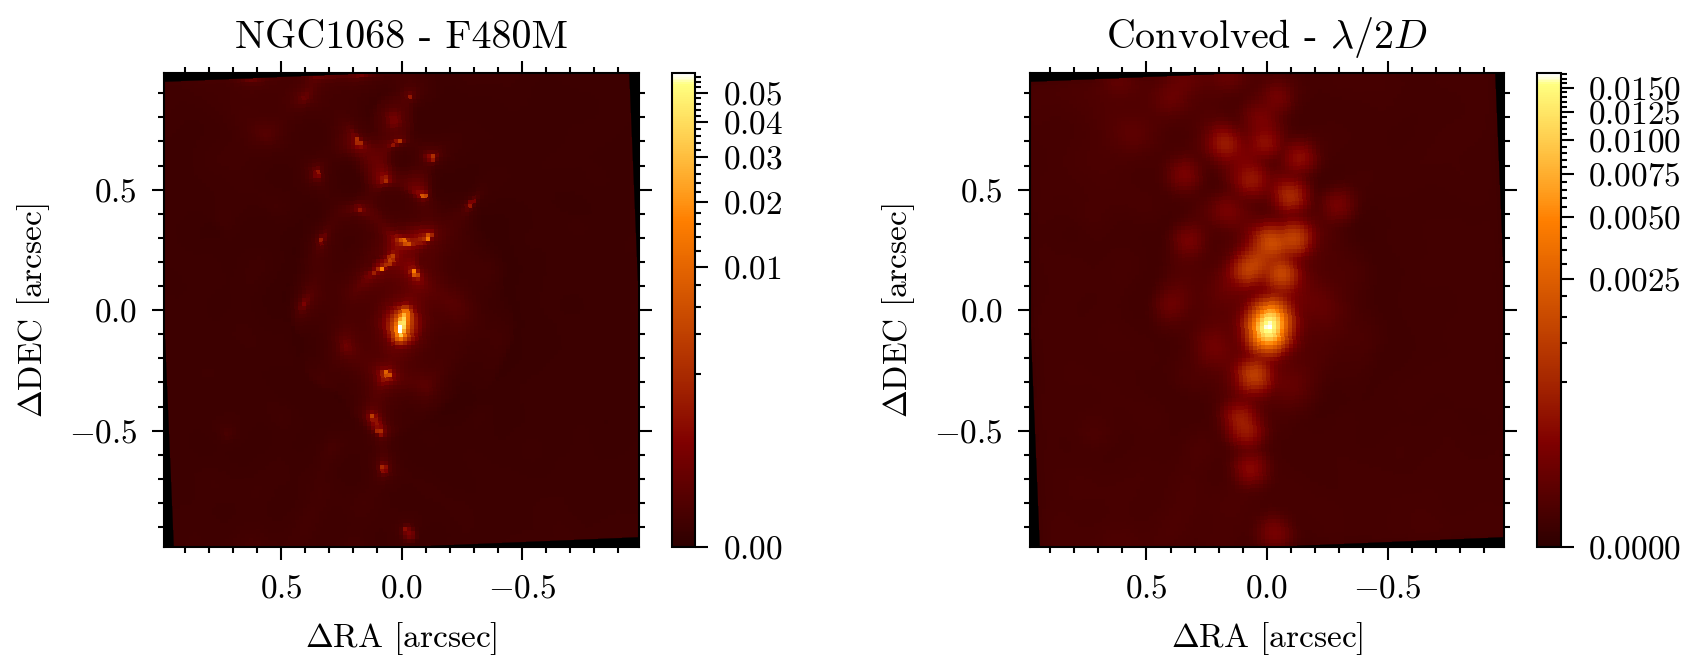

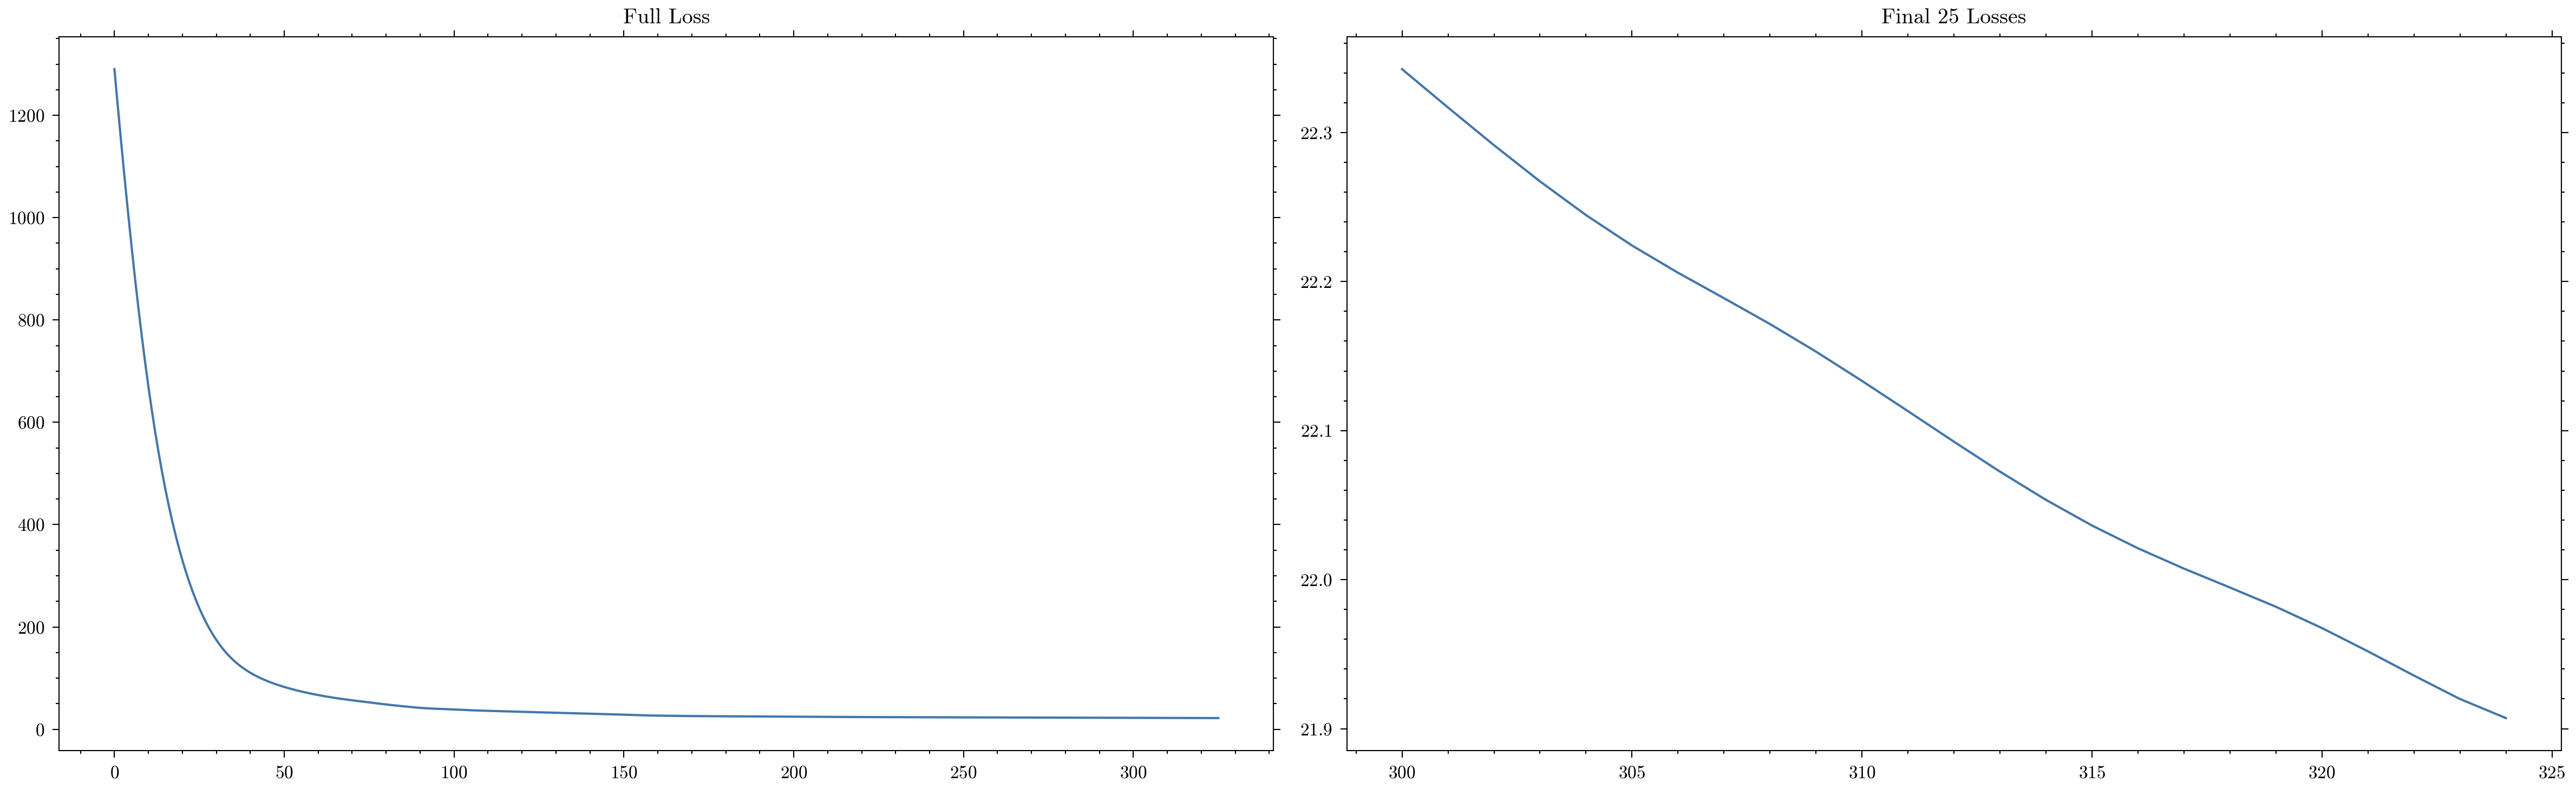

No formatting function for log_distribution


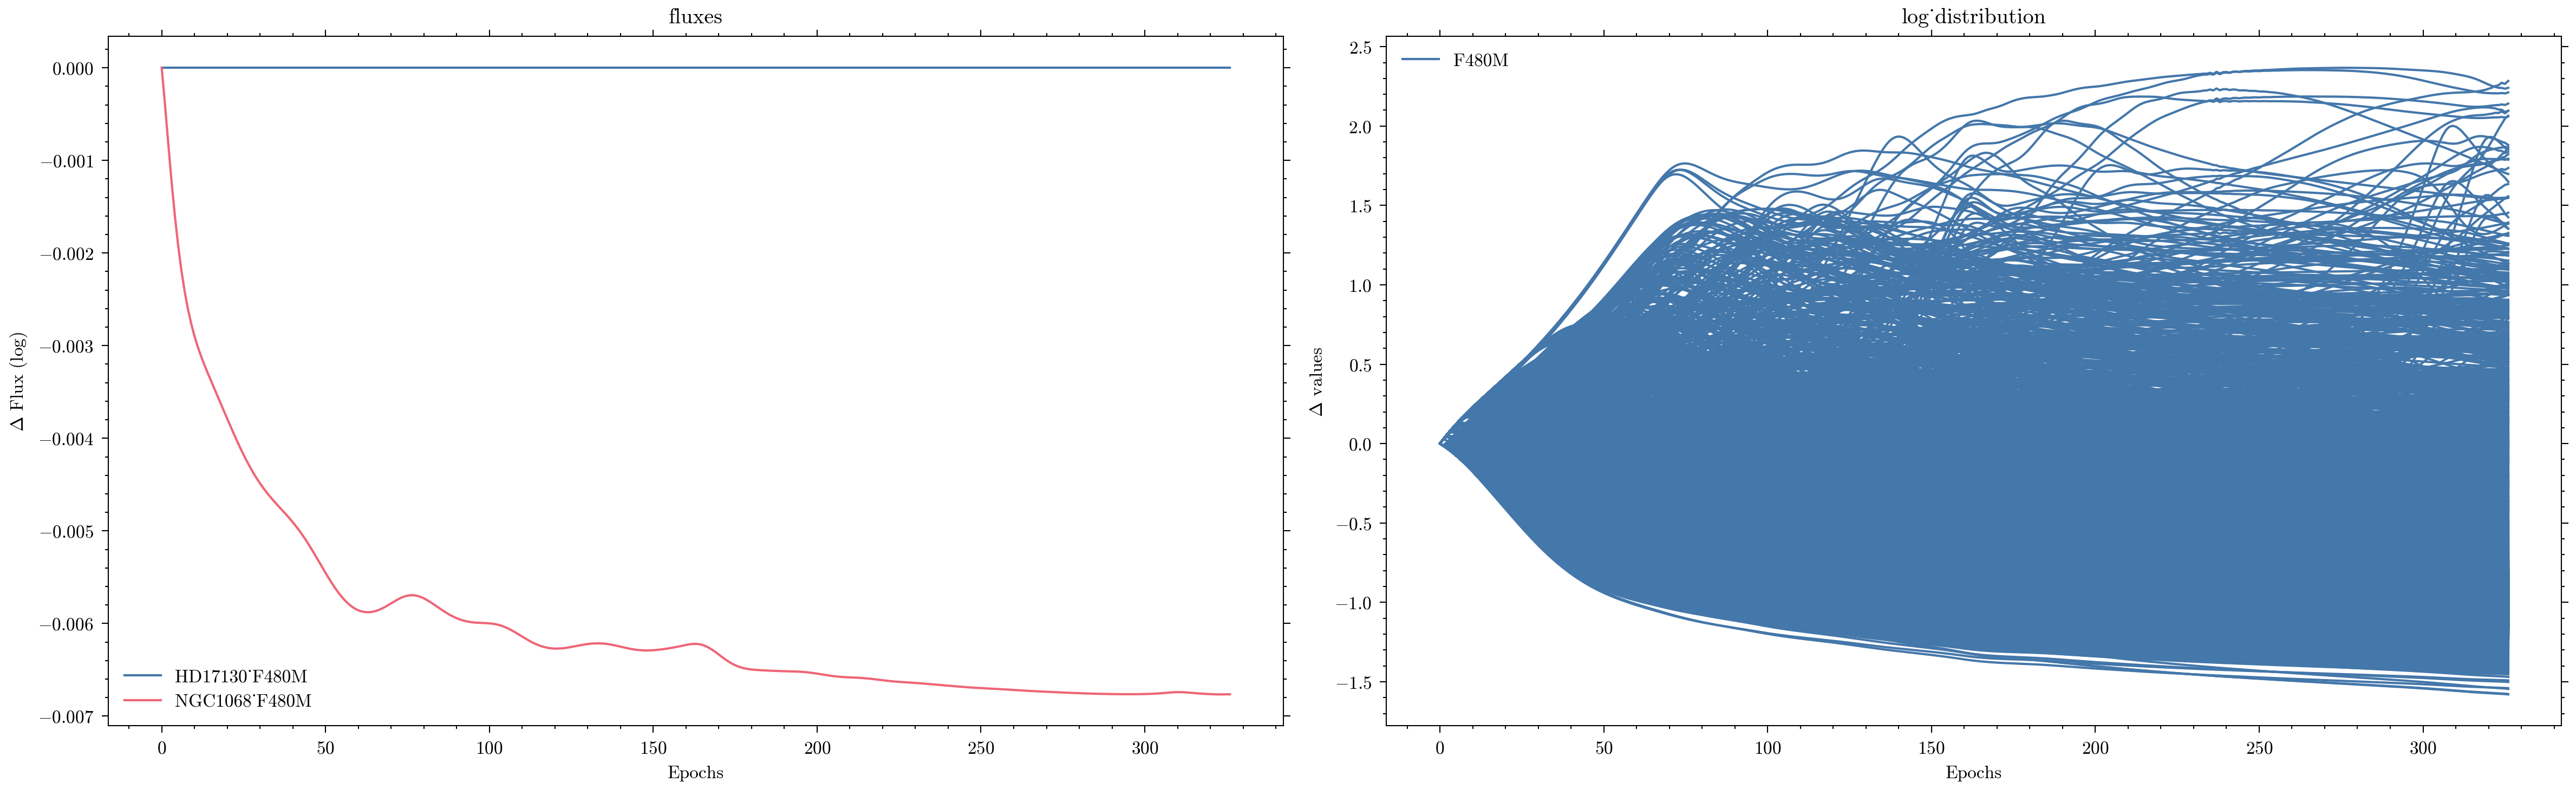

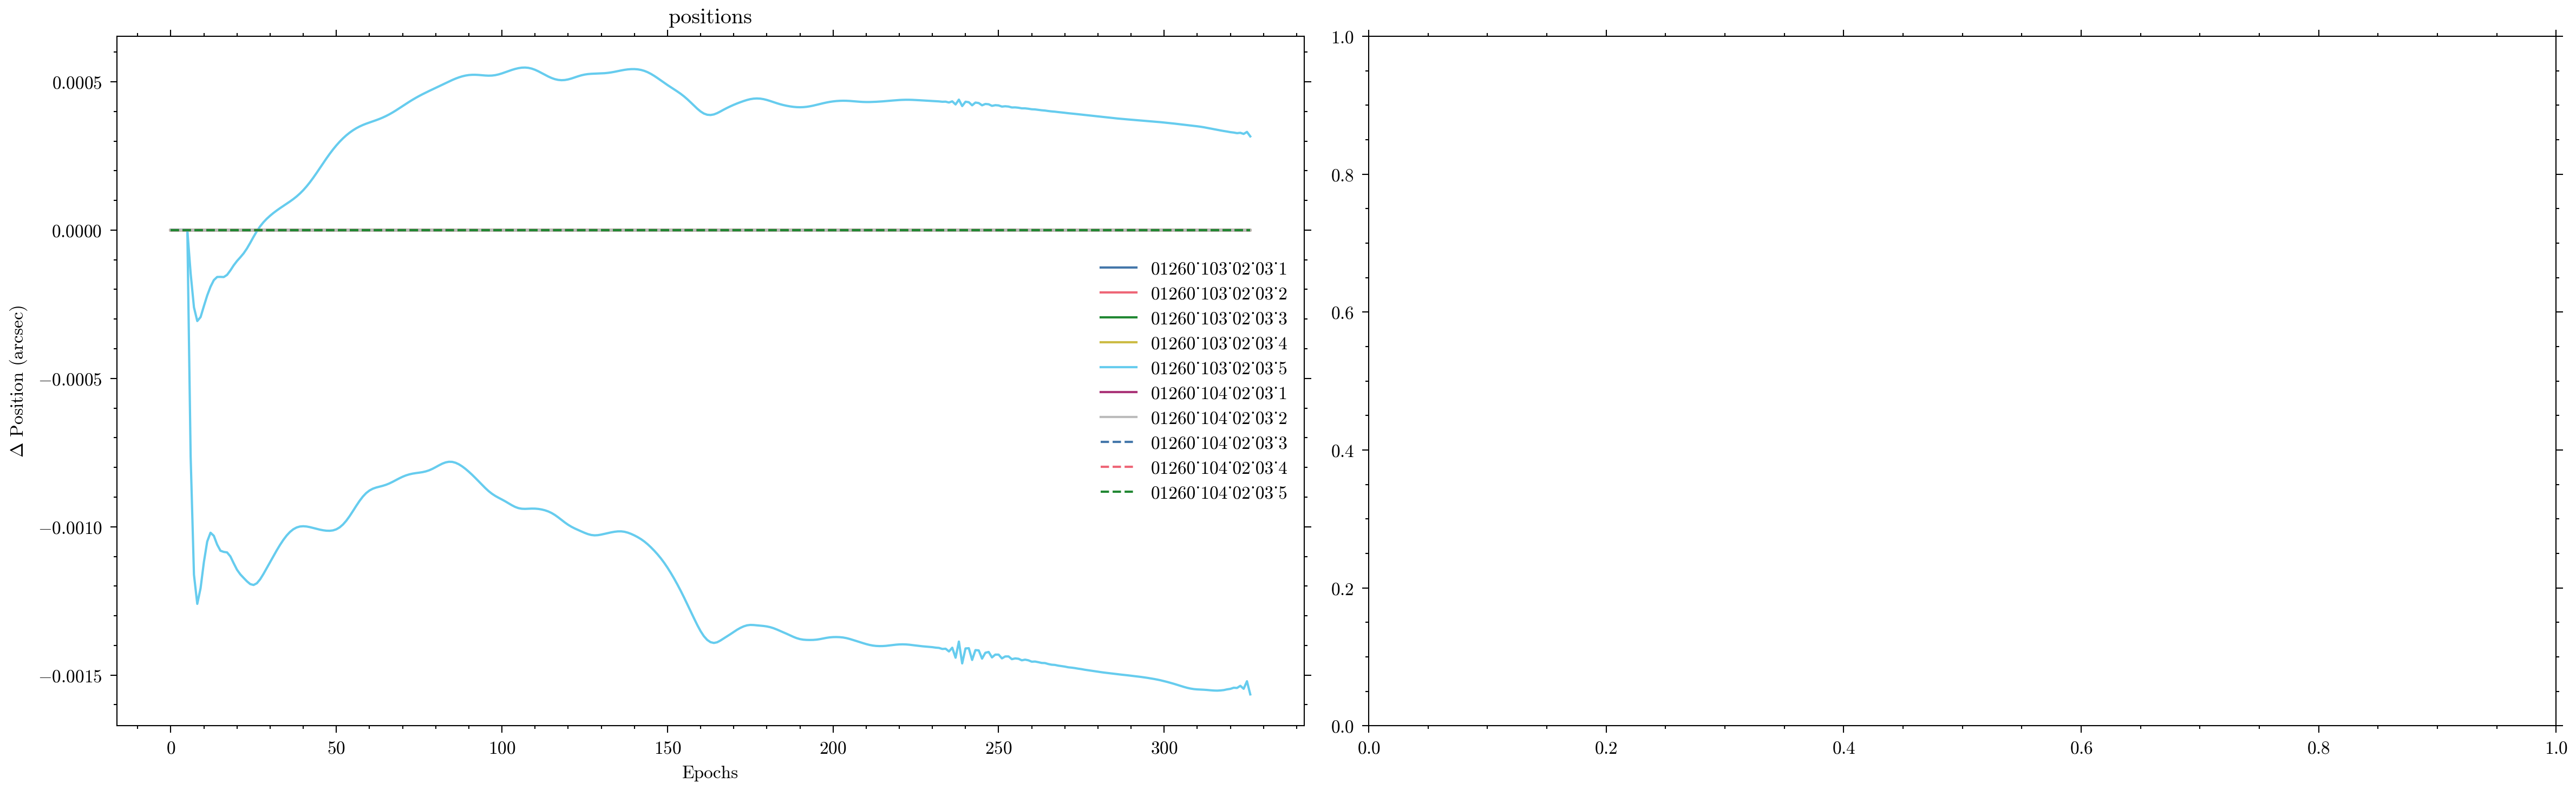

File 01260_103_02_03_5
Star NGC1068
Filter F480M
nints 91
ngroups 4



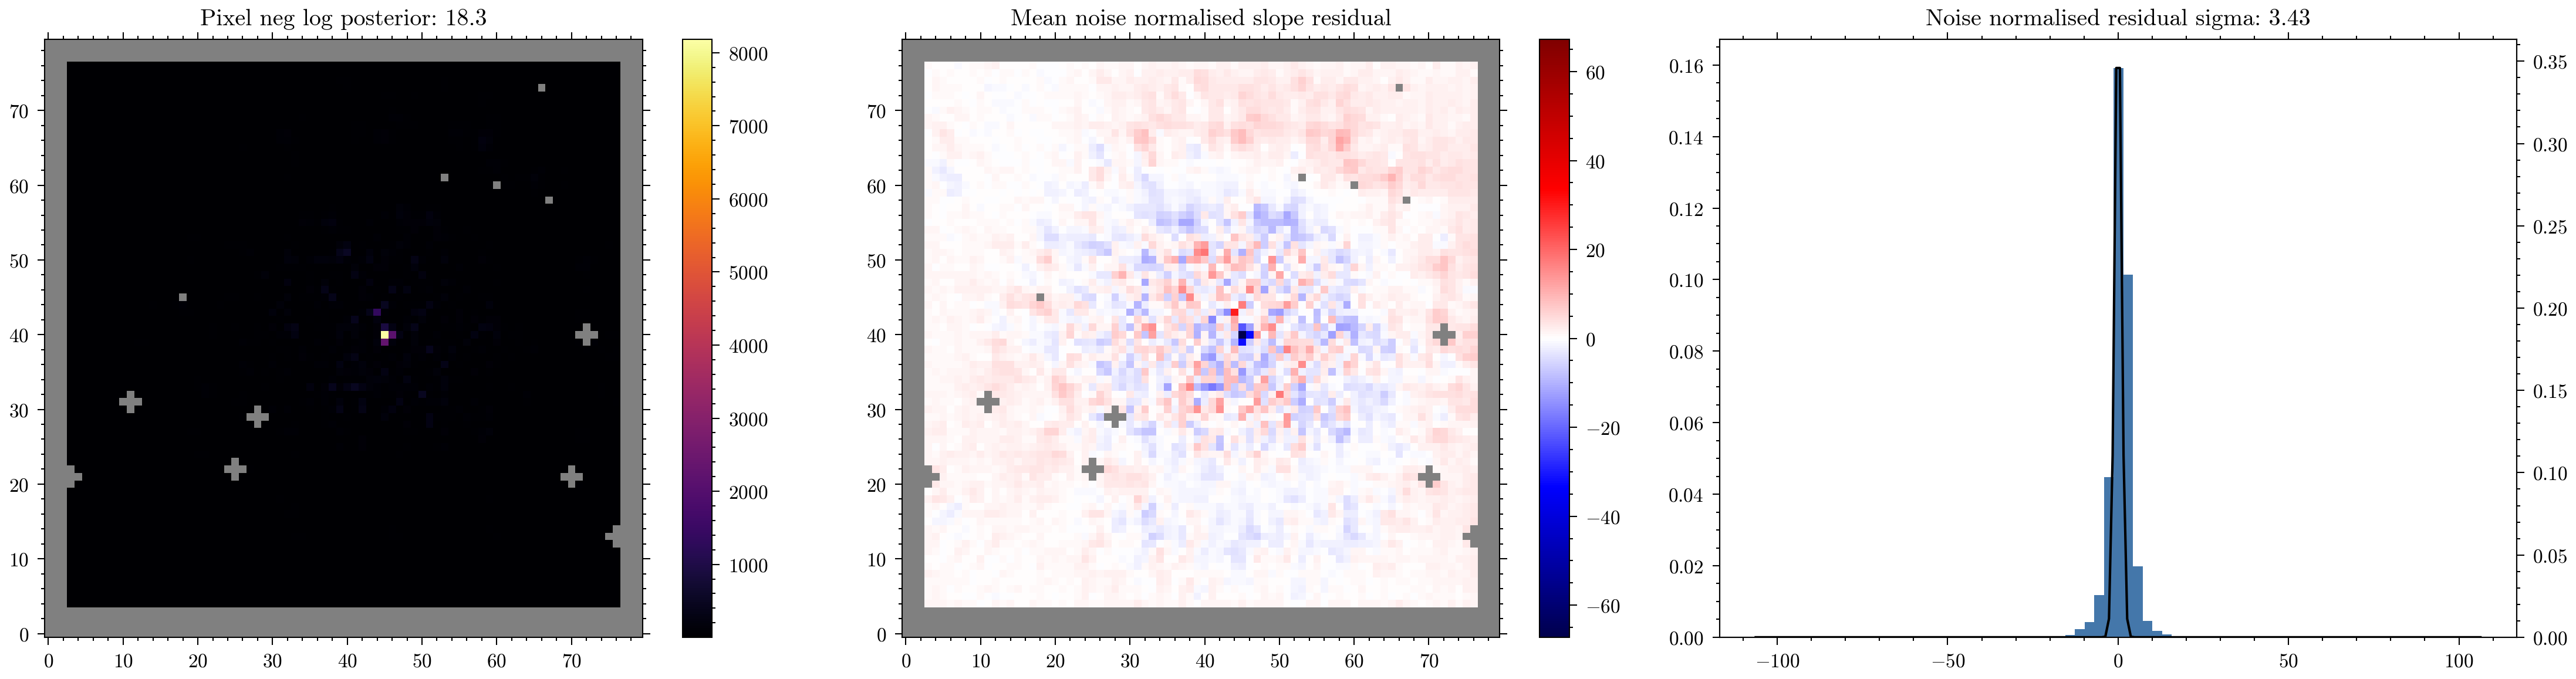

In [15]:
# np.save(init_state_cache + "F480M.npy", state.params)

flag = False
for exp in fits:

    try:
        if not flag:
            dist = final_model.get_distribution(exp)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                # vmin=None,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, final_model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"NGC1068 - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(save_dir + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        # flag = True
    except:
        continue


amigo.plotting.plot_losses(losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(histories)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        final_model,
        exp,
        # test_model,
    )

In [36]:
sweep, coeffs, log_dists = dorito.stats.lcurve_sweep(
    "QV",
    np.logspace(-6, 8, 100),
    model,
    fits,
    args,
    config,
    fishers,
    # args=args,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    # loss_fn=zdx.combine,
    # epochs=n_epoch,
    epochs=400,
    eps=1e-3,
    print_grads=False,
)

  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 1,293.77
Est time per epoch:  0:00:00
Est run time:  0:01:44
Full Time: 0:01:48
Final Loss: 372.22


  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:04
Initial Loss: 1,293.77
Est time per epoch:  0:00:00
Est run time:  0:01:49
Full Time: 0:01:50
Final Loss: 372.22


  0%|          | 0/400 [00:00<?, ?it/s]

...

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 4,229.24
Est time per epoch:  0:00:00
Est run time:  0:01:52
Convergence reached on 226 th epoch, exiting loop


  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 5,688.97
Est time per epoch:  0:00:00
Est run time:  0:01:51
Convergence reached on 244 th epoch, exiting loop


  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 7,744.45
Est time per epoch:  0:00:00
Est run time:  0:01:51
Convergence reached on 227 th epoch, exiting loop


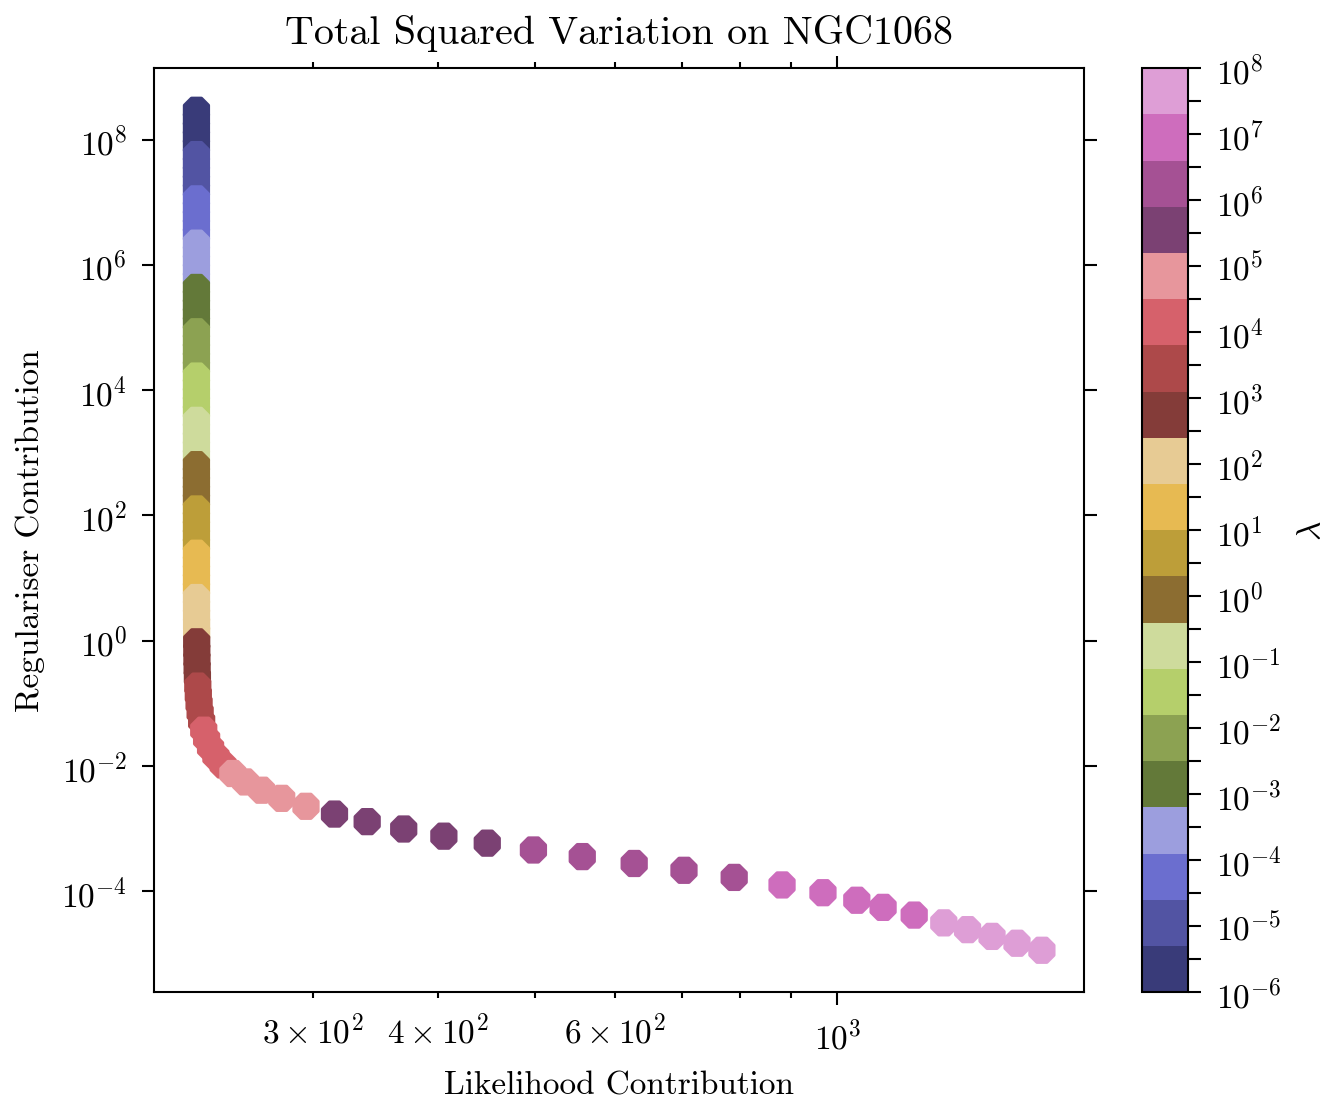

In [62]:
plt.figure(figsize=(5, 4))
plt.scatter(
    sweep[0],
    sweep[1],
    c=coeffs,
    cmap="tab20b",
    # cmap="viridis",
    norm=mpl.colors.LogNorm(),
    marker="8",
)

plt.xscale("log")
plt.yscale("log")
plt.colorbar(label=r"$\lambda$", ticks=np.logspace(-6, 8, 29))
# plt.axis("off")
plt.xlabel("Likelihood Contribution")
plt.ylabel("Regulariser Contribution")
plt.title("Total Squared Variation on NGC1068")
plt.show()

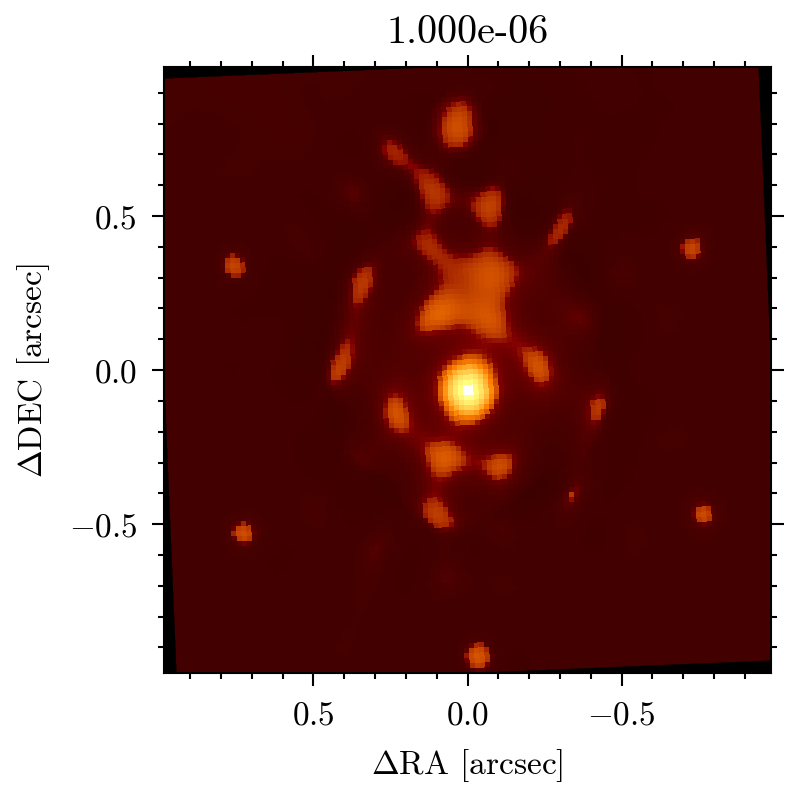

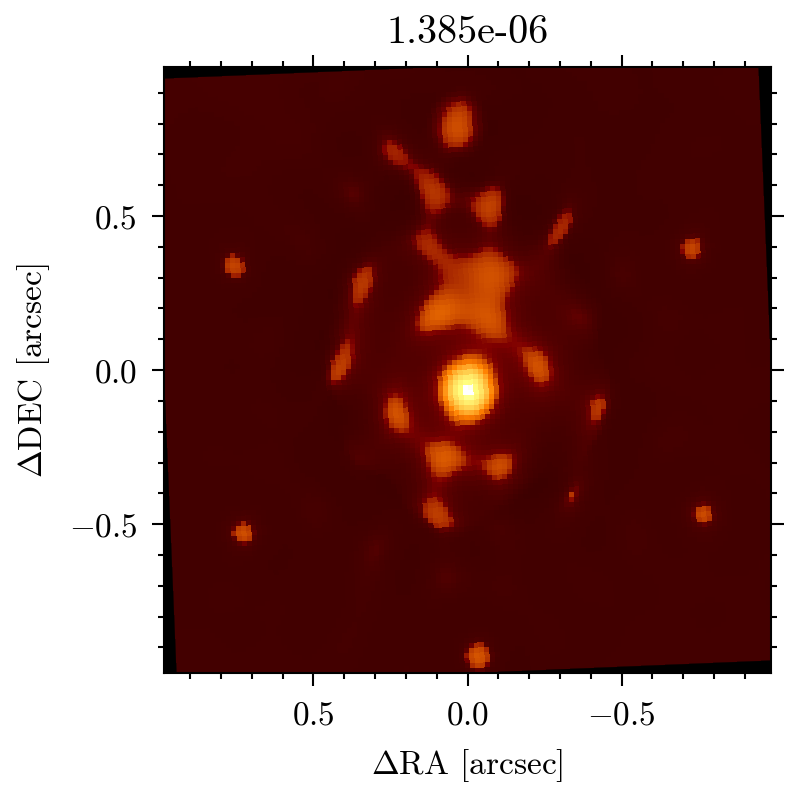

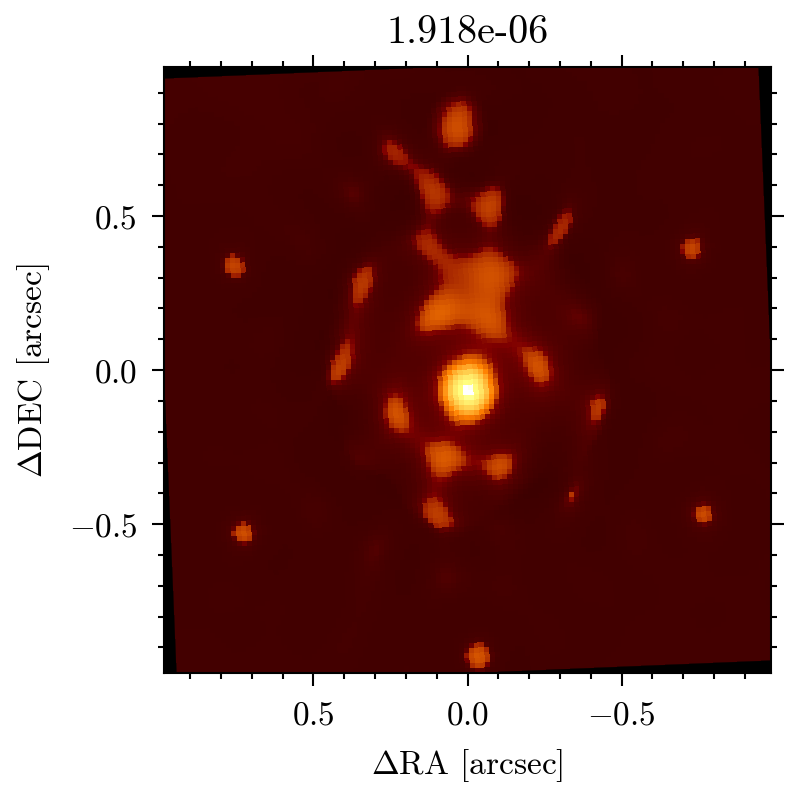

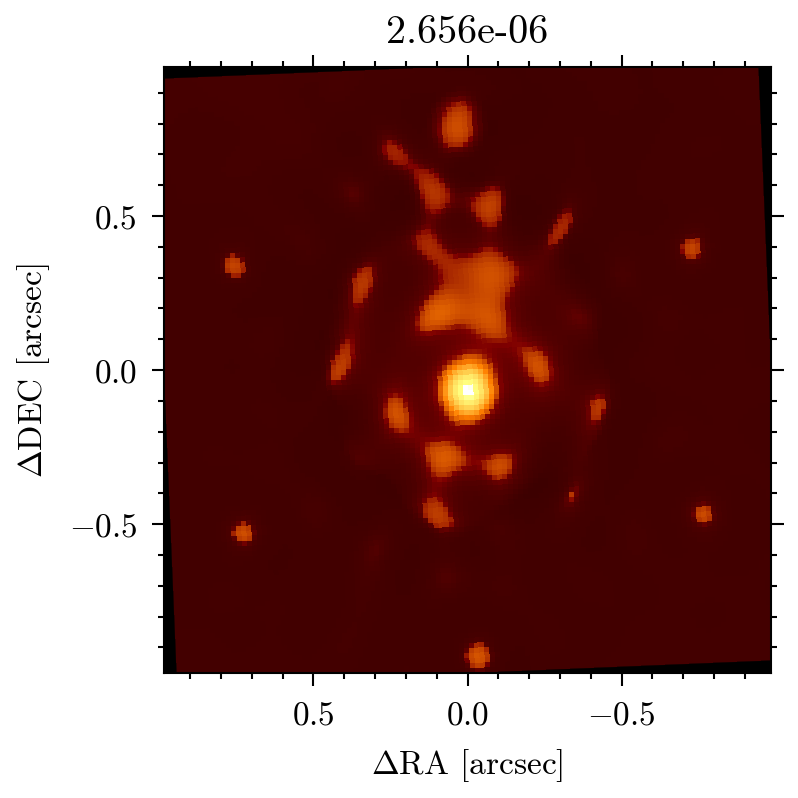

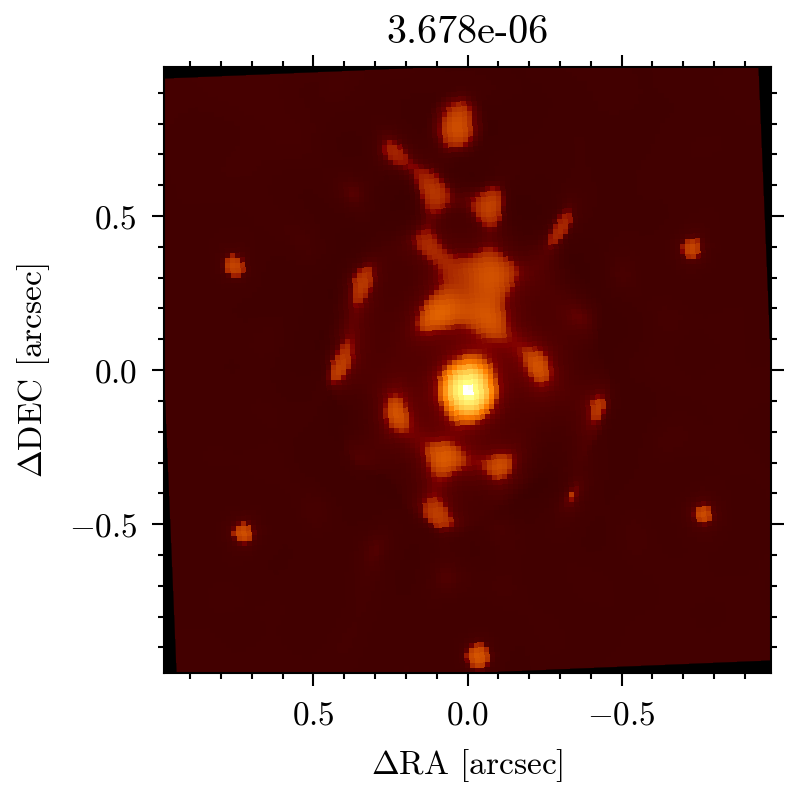

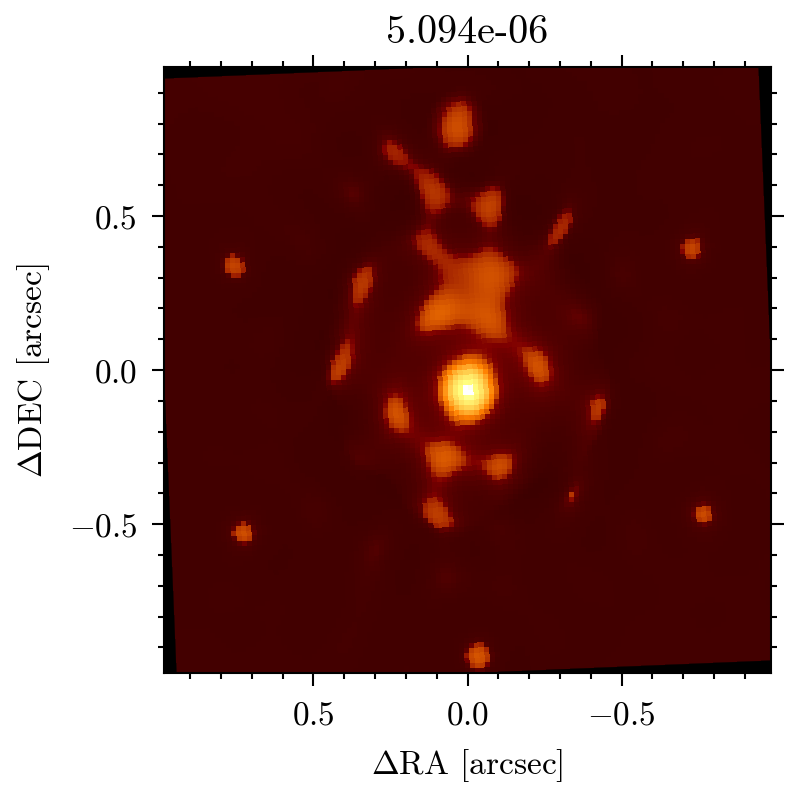

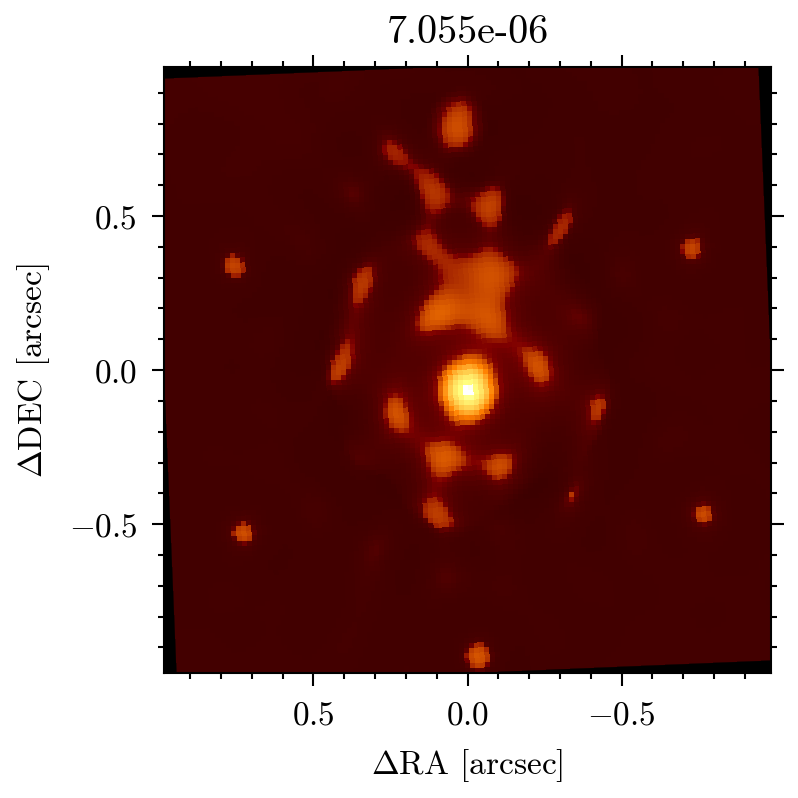

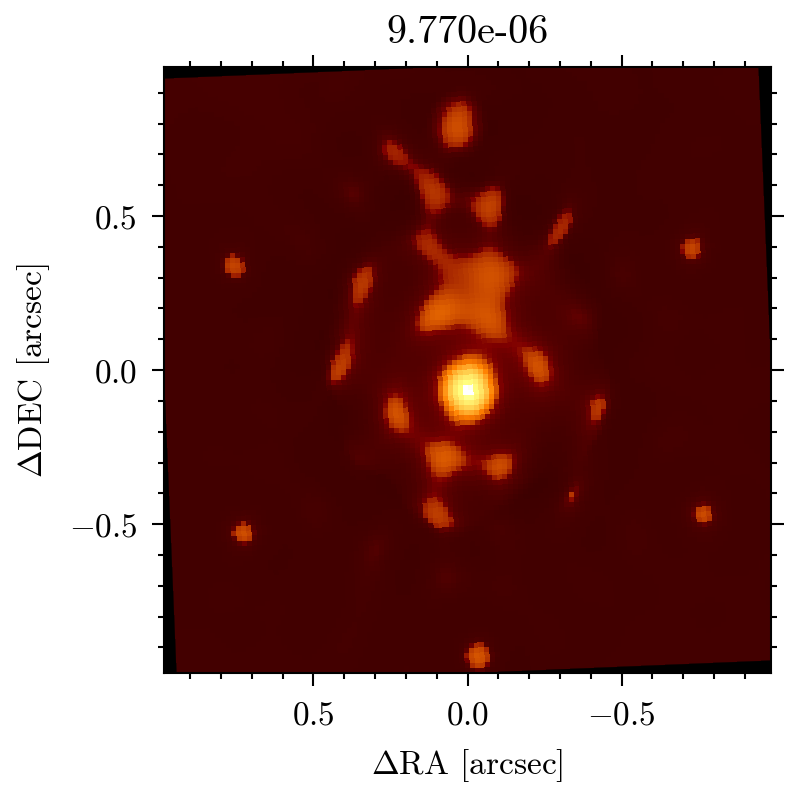

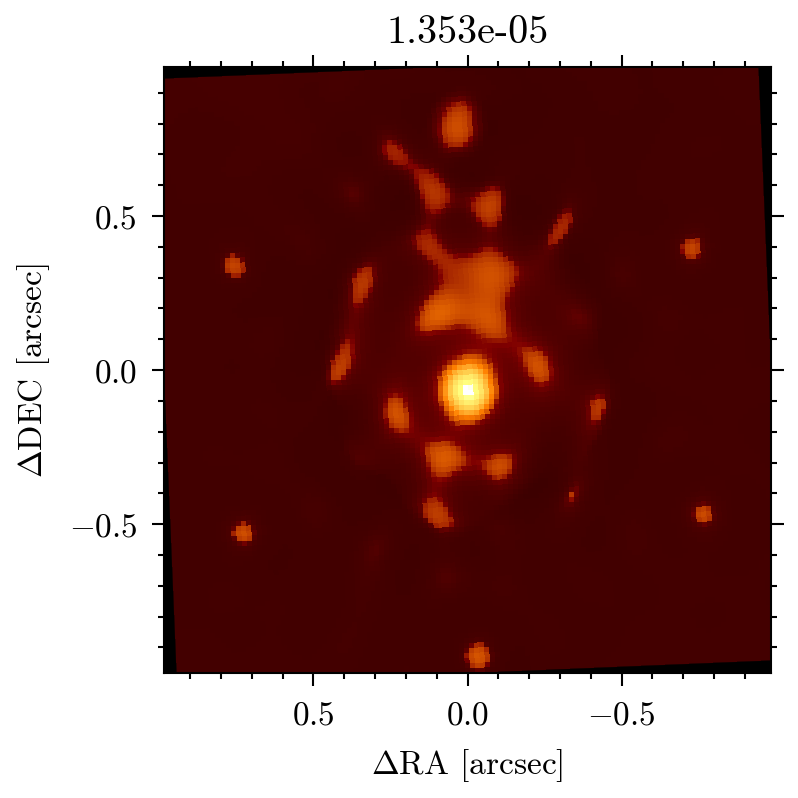

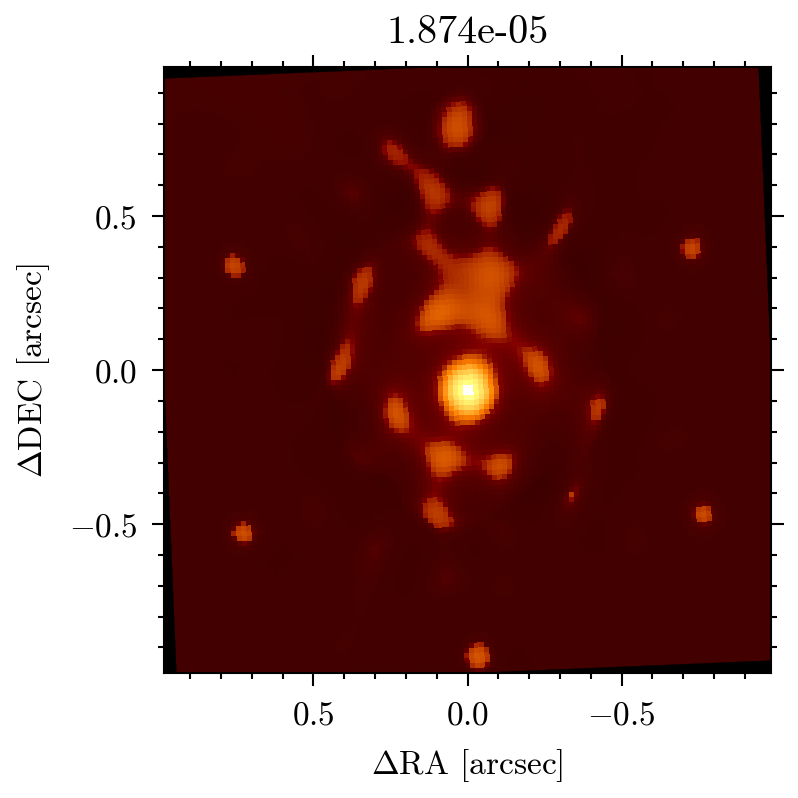

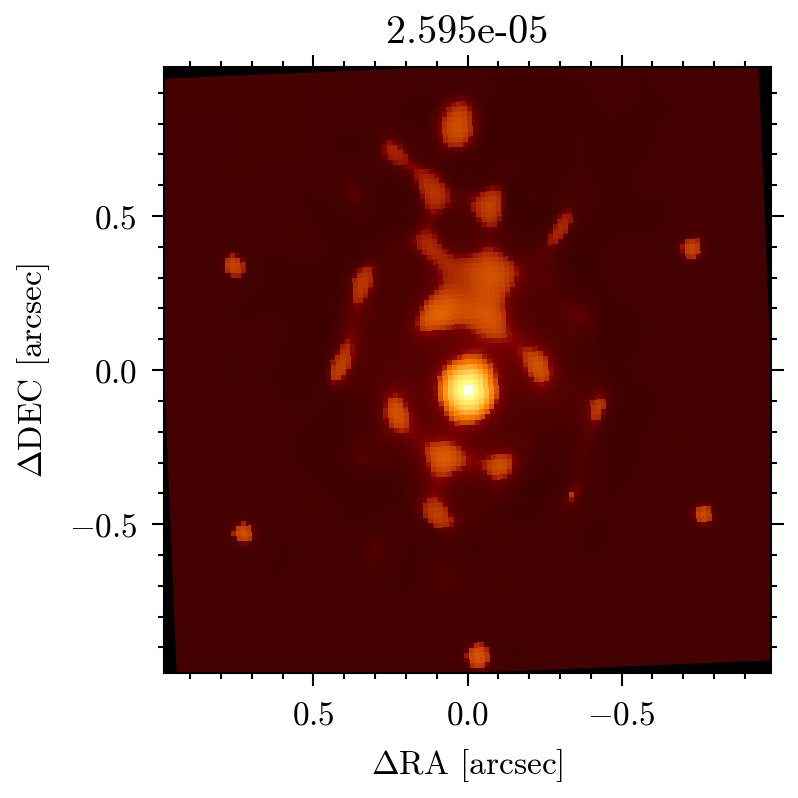

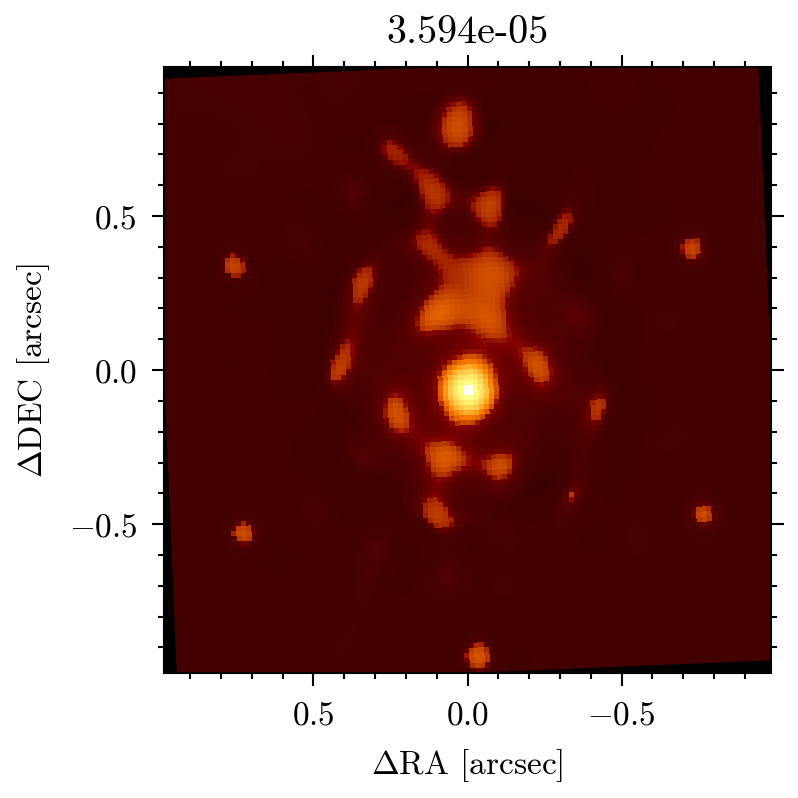

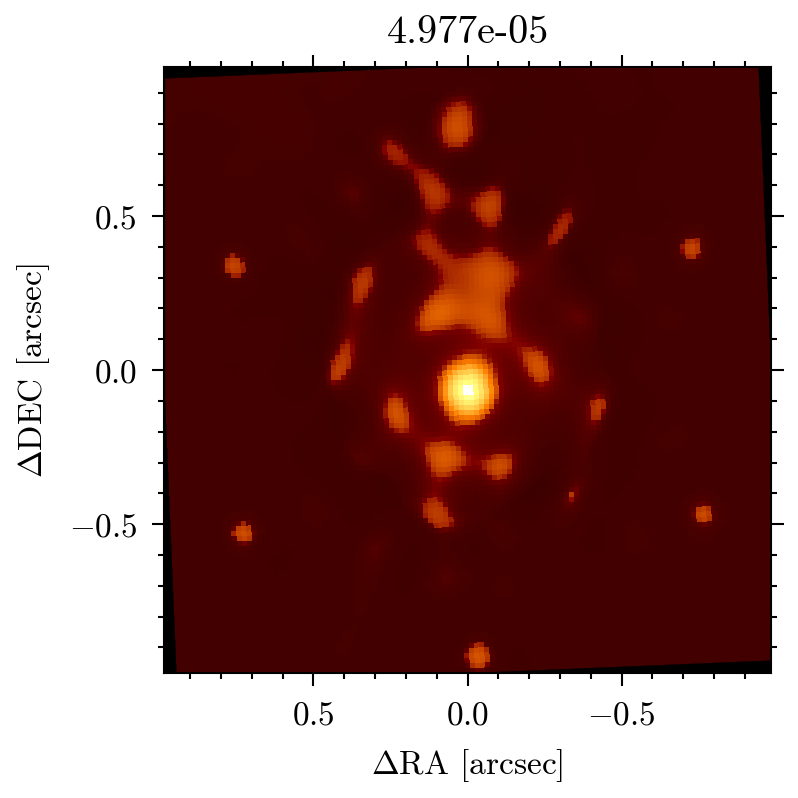

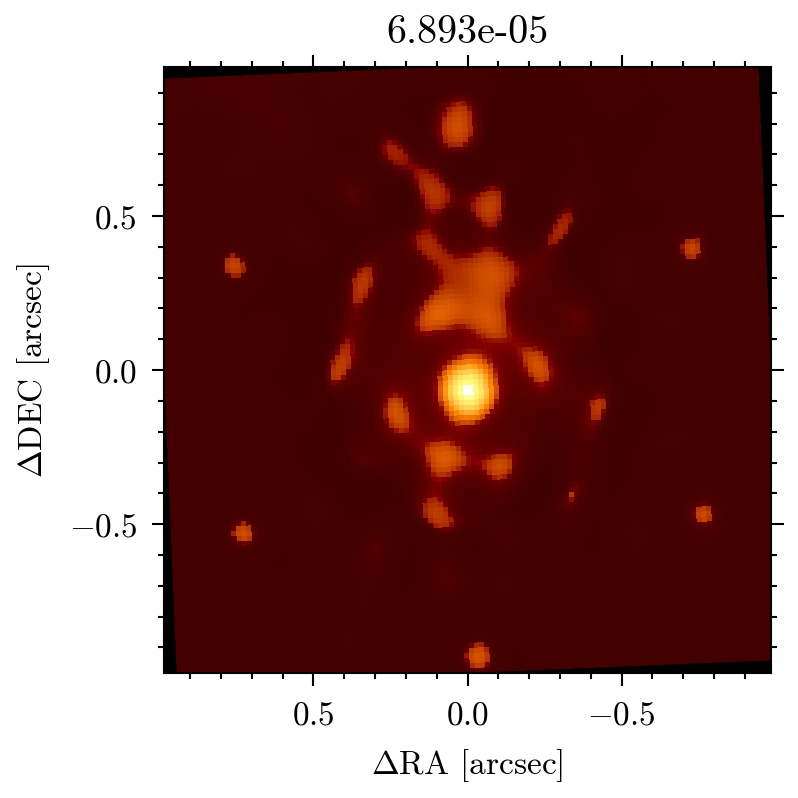

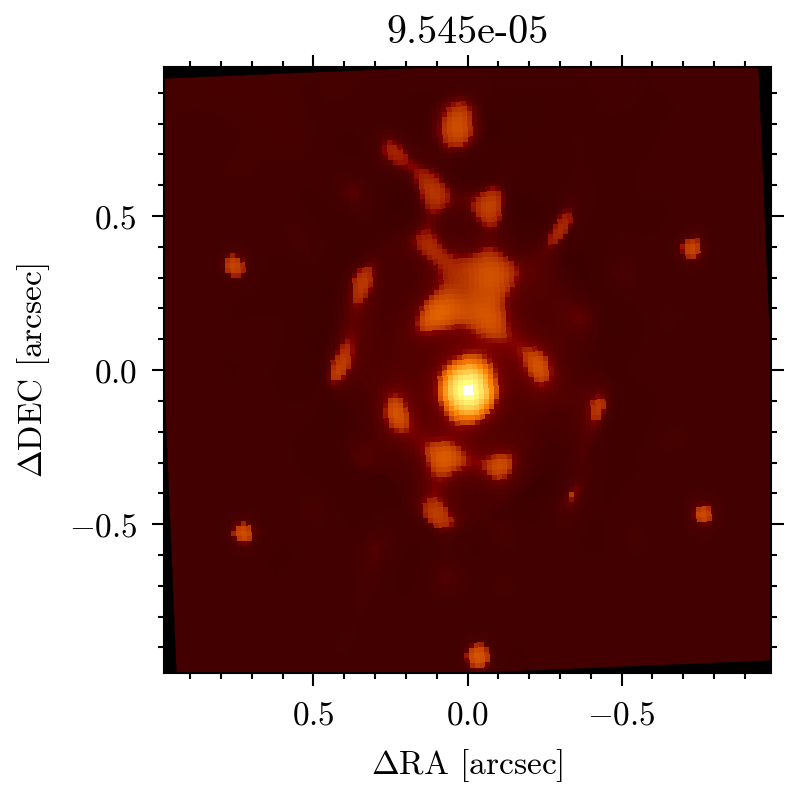

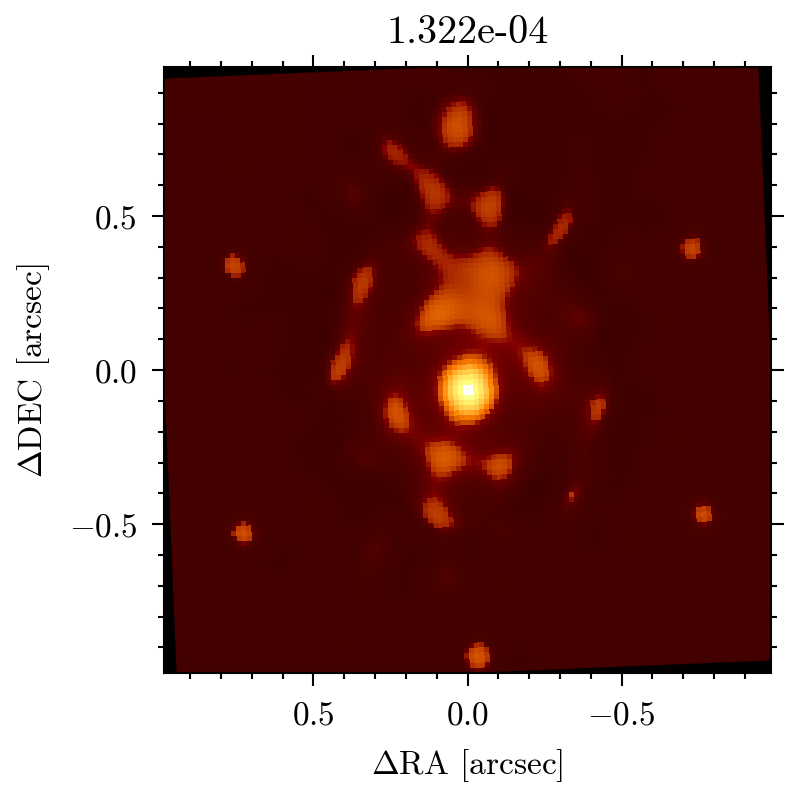

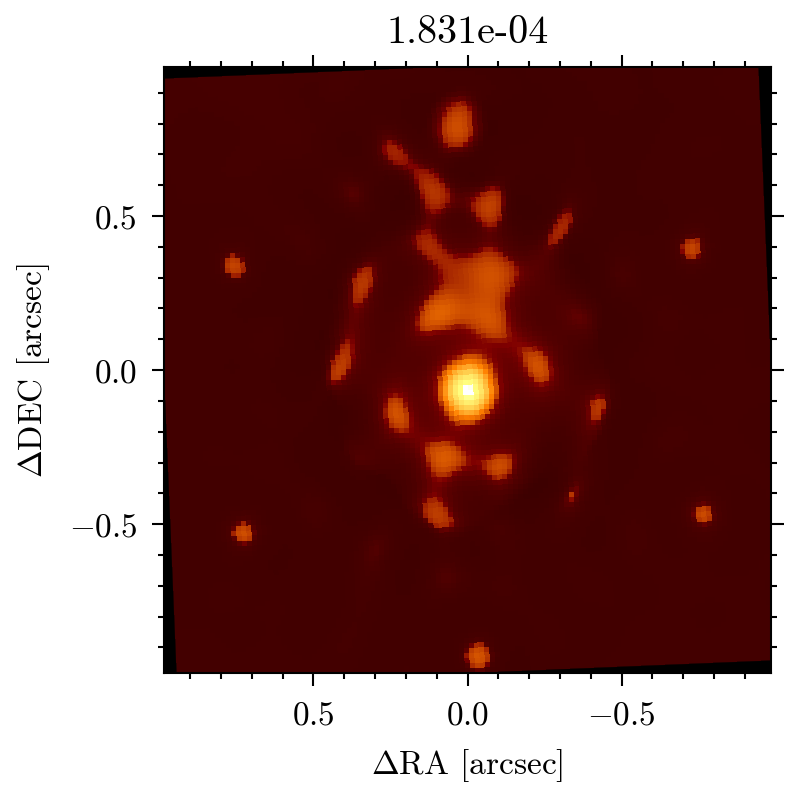

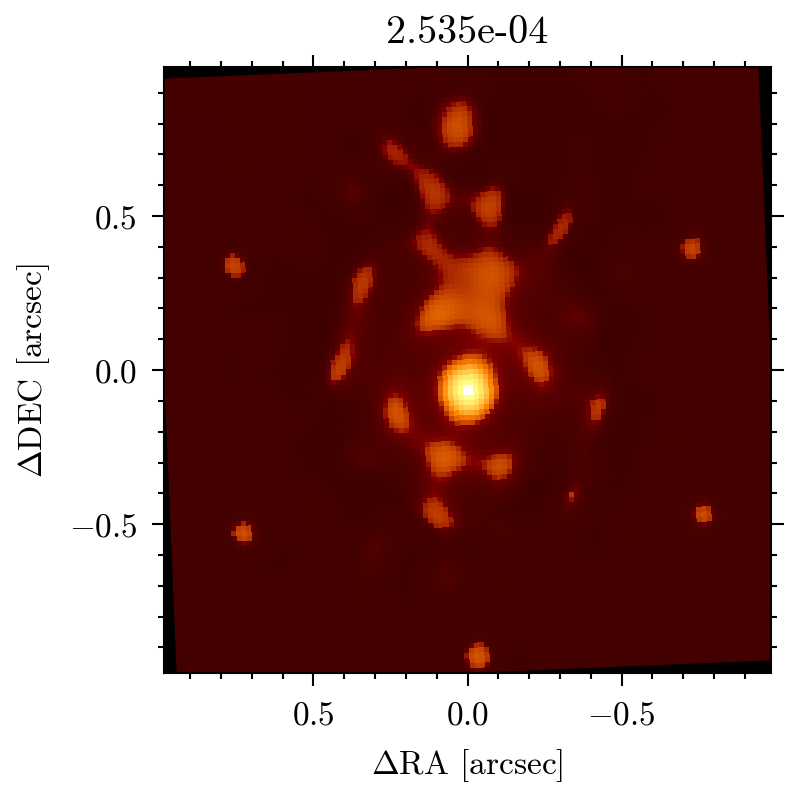

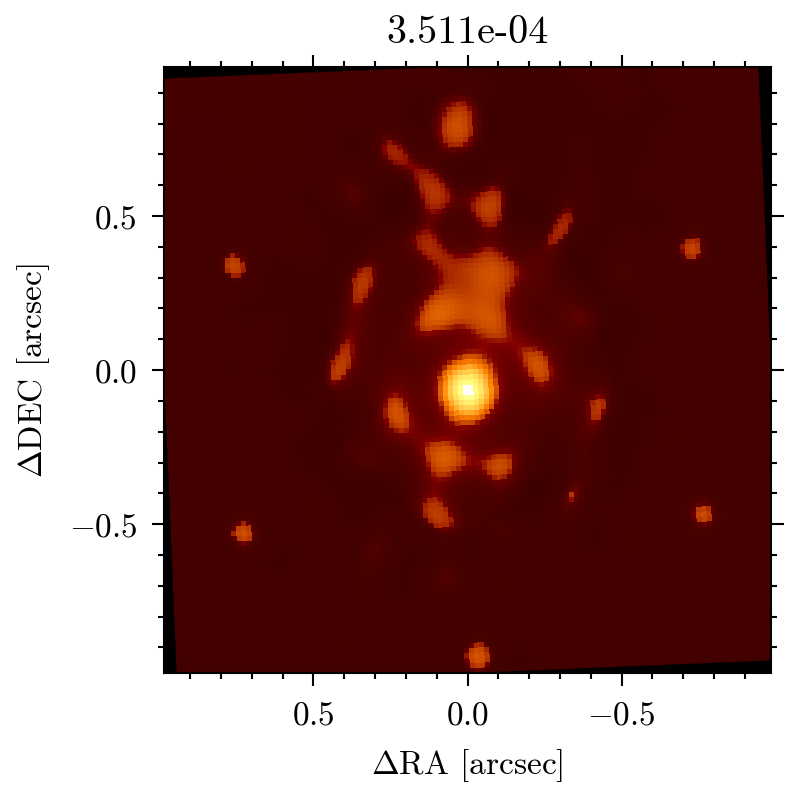

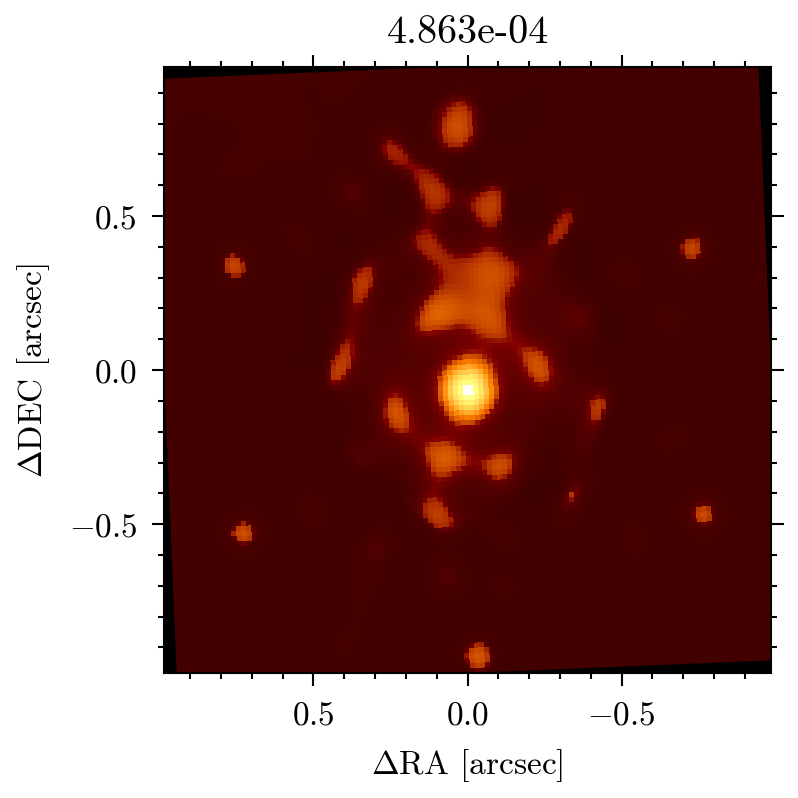

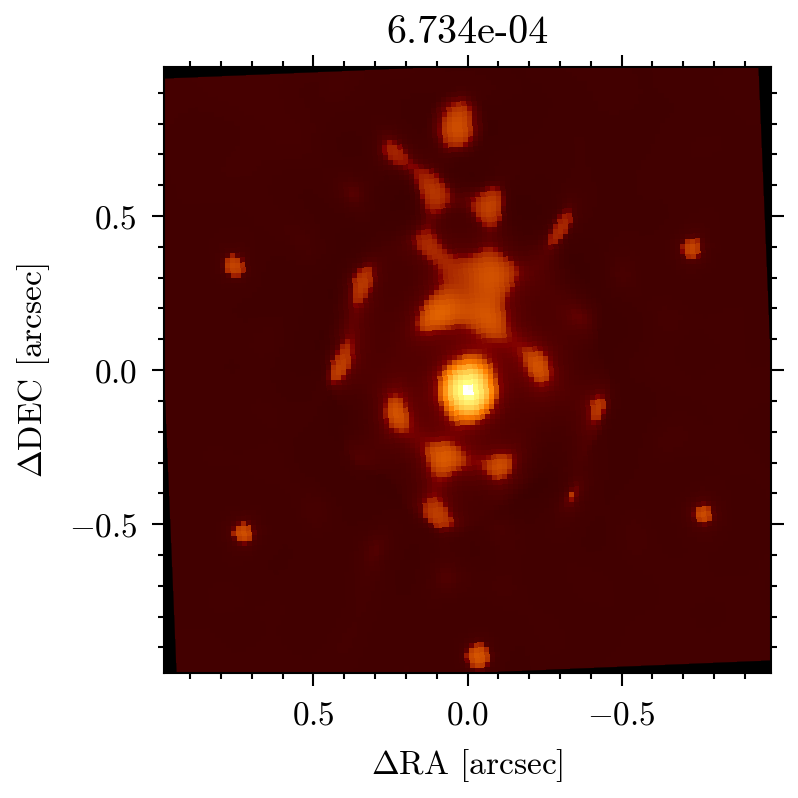

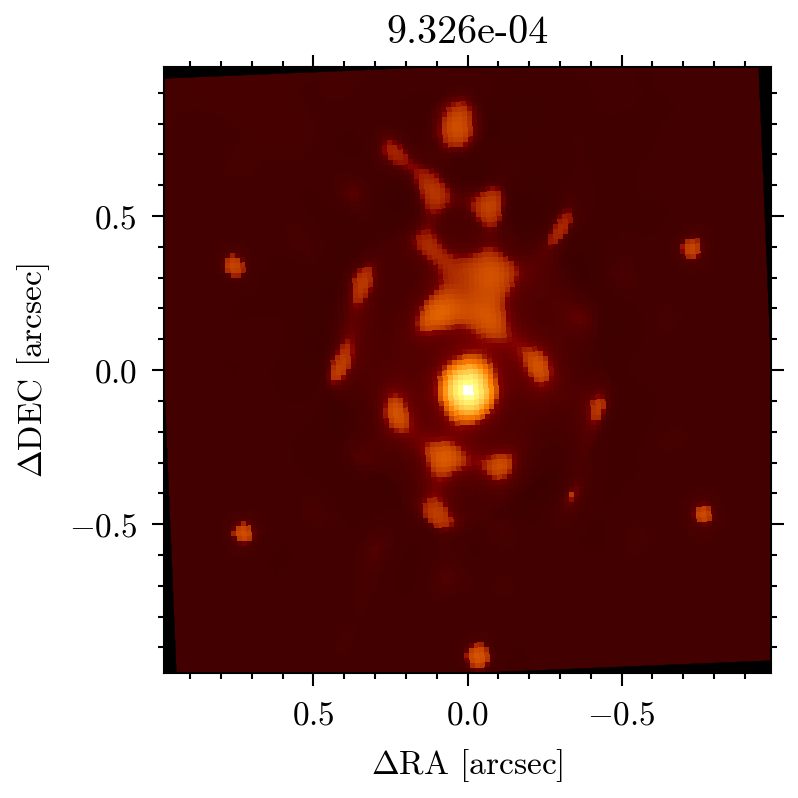

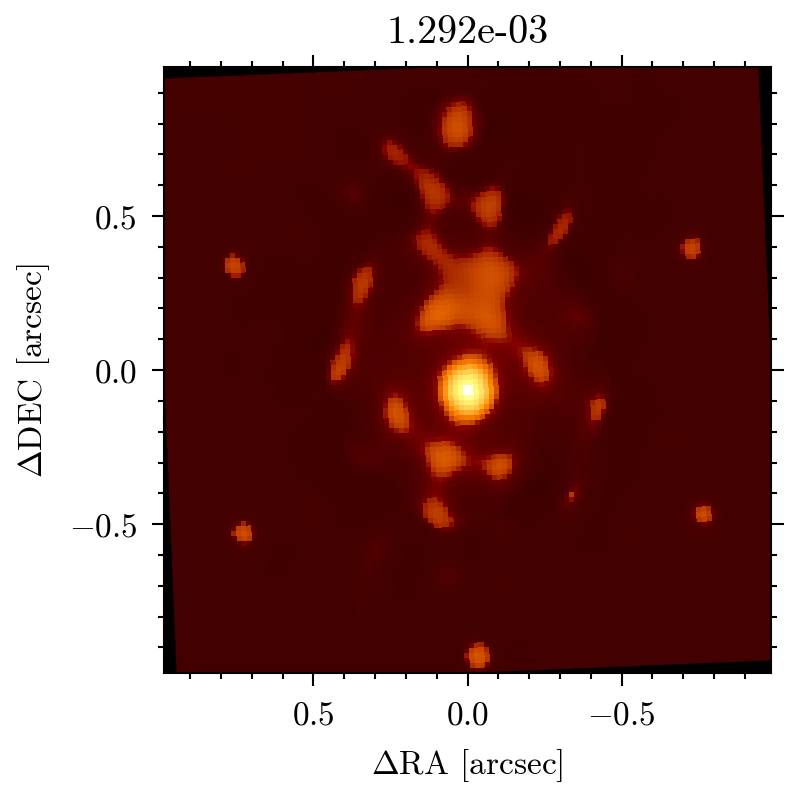

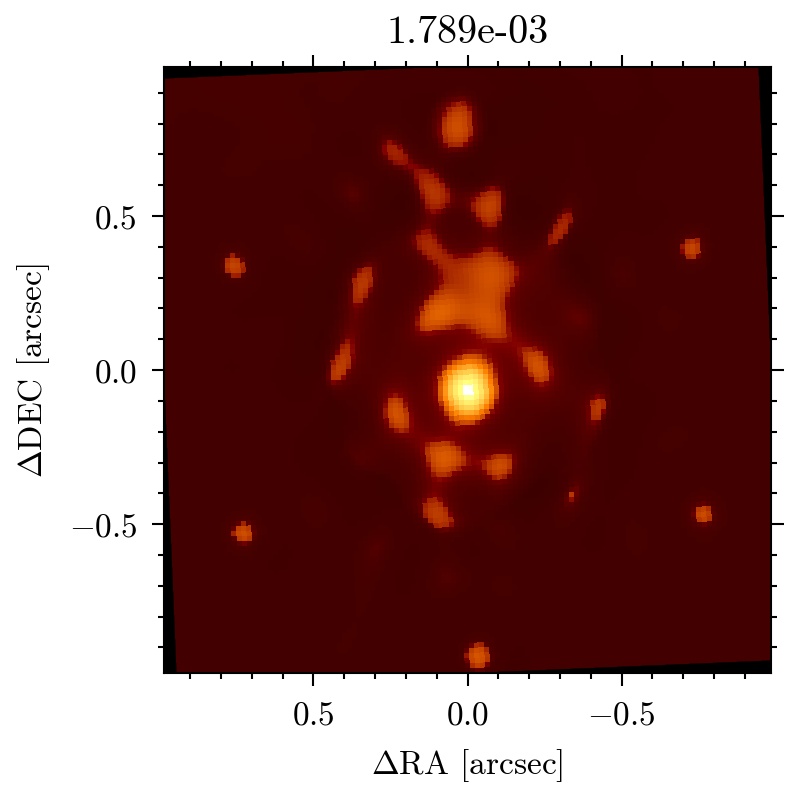

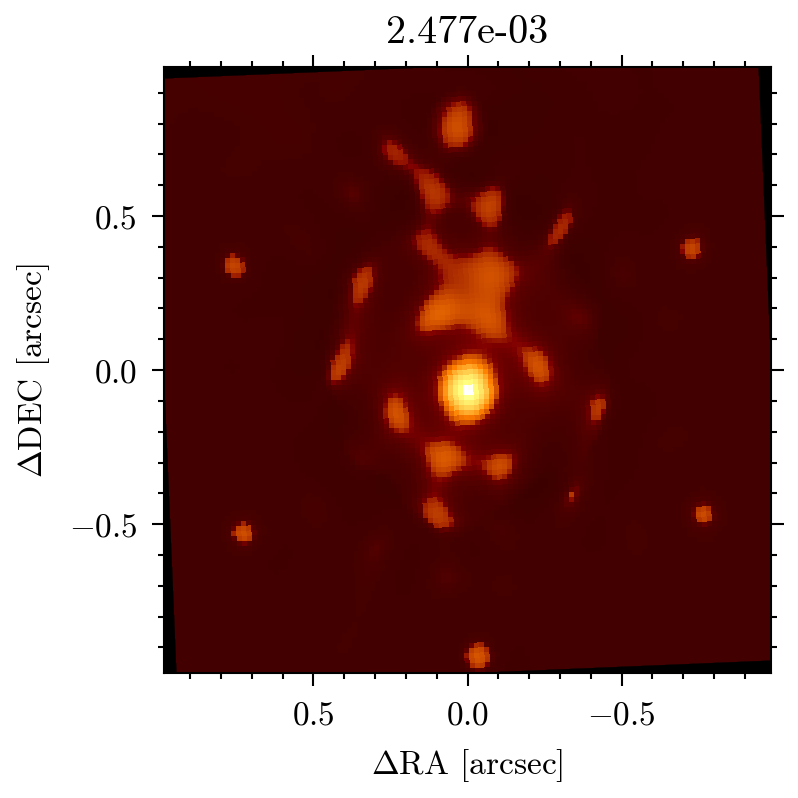

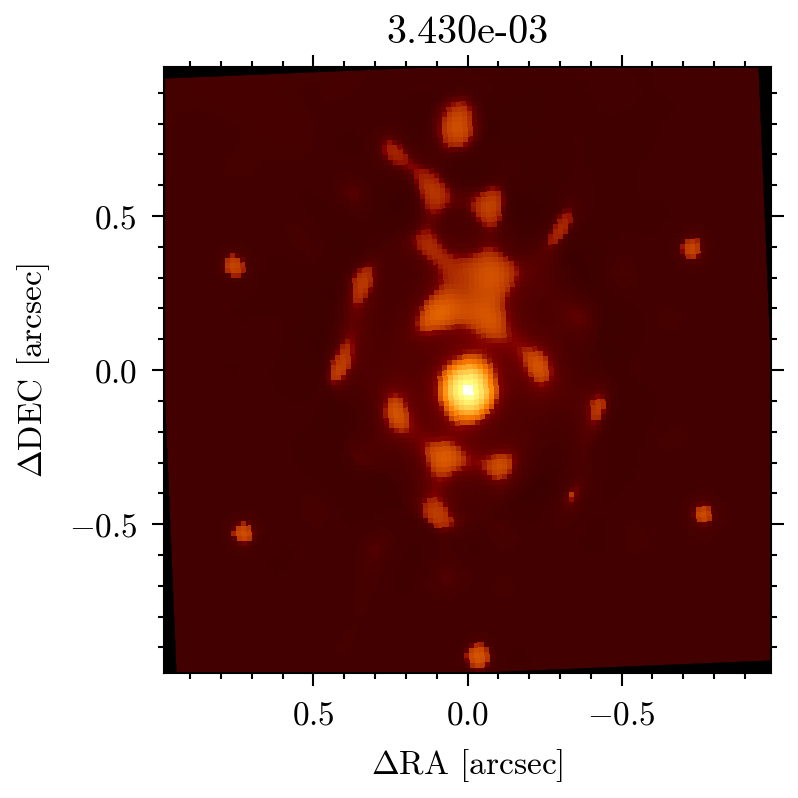

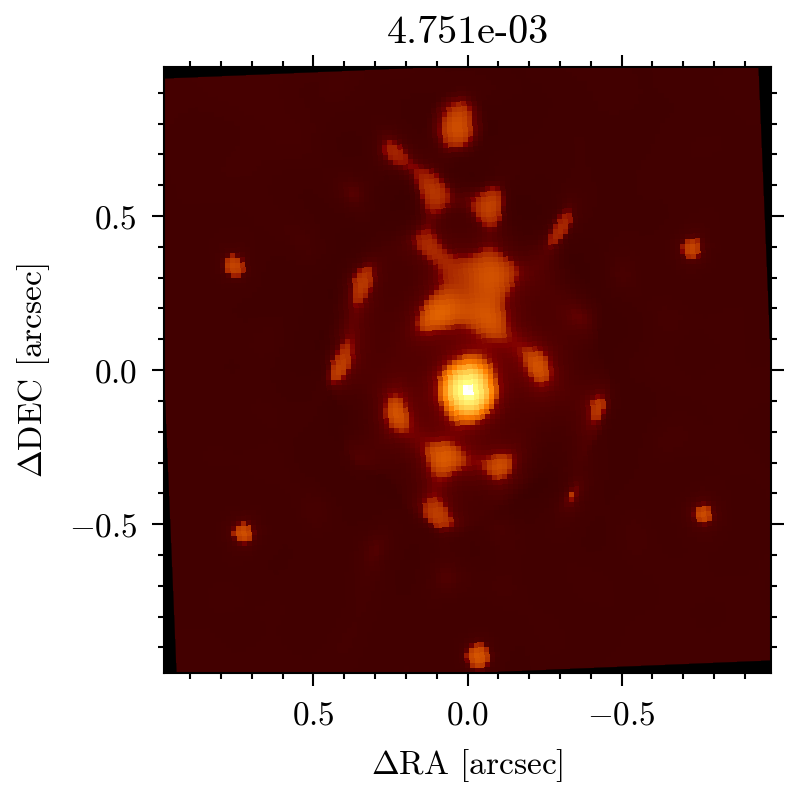

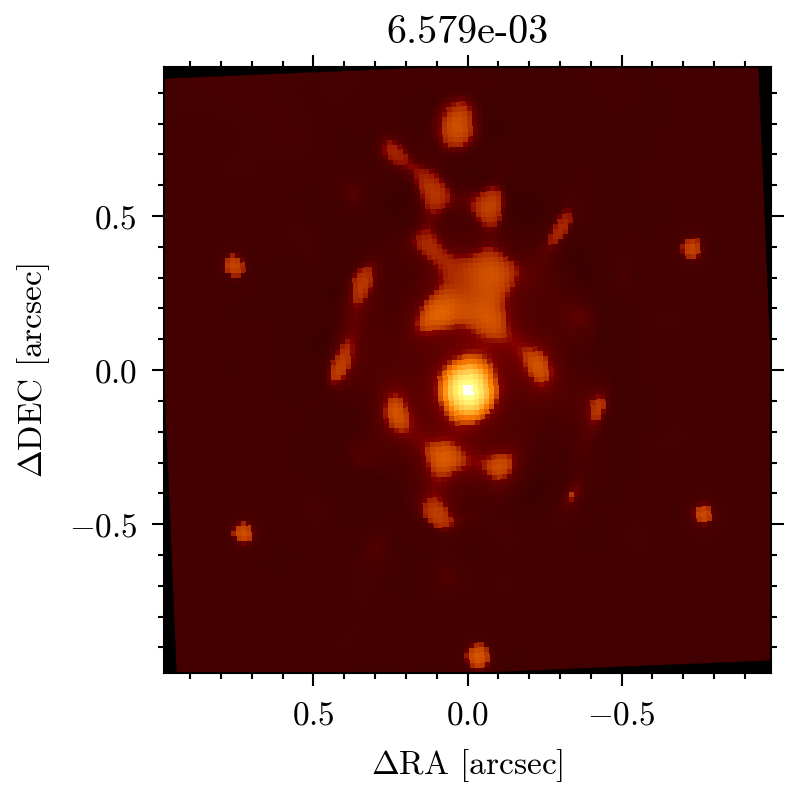

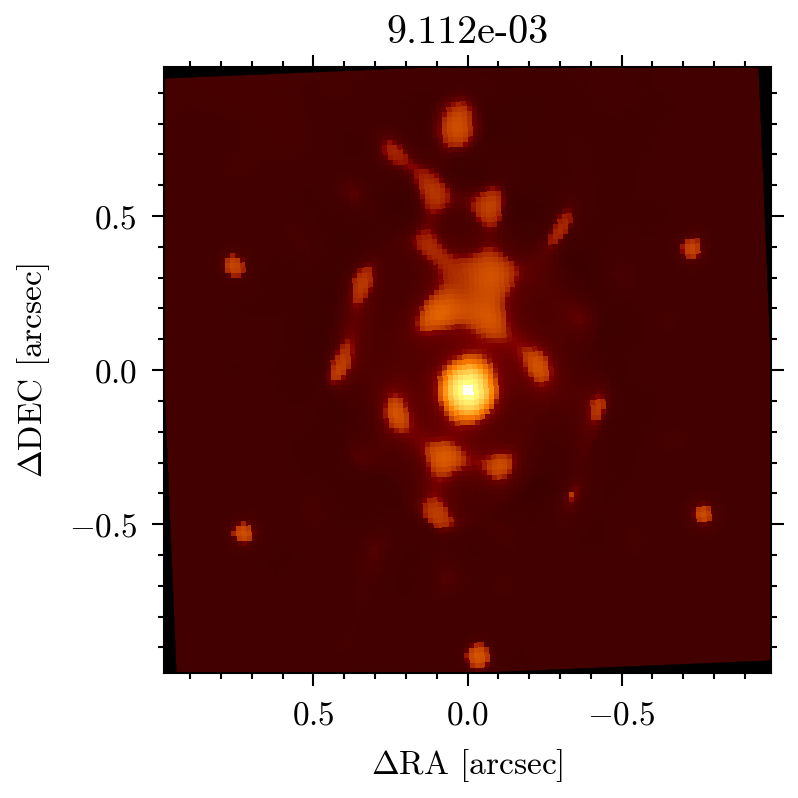

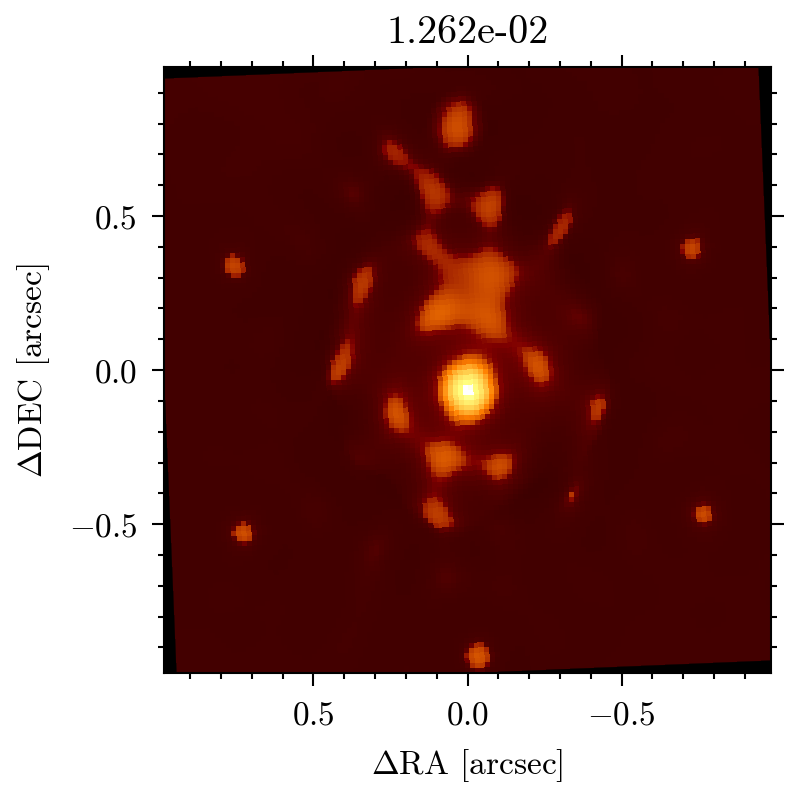

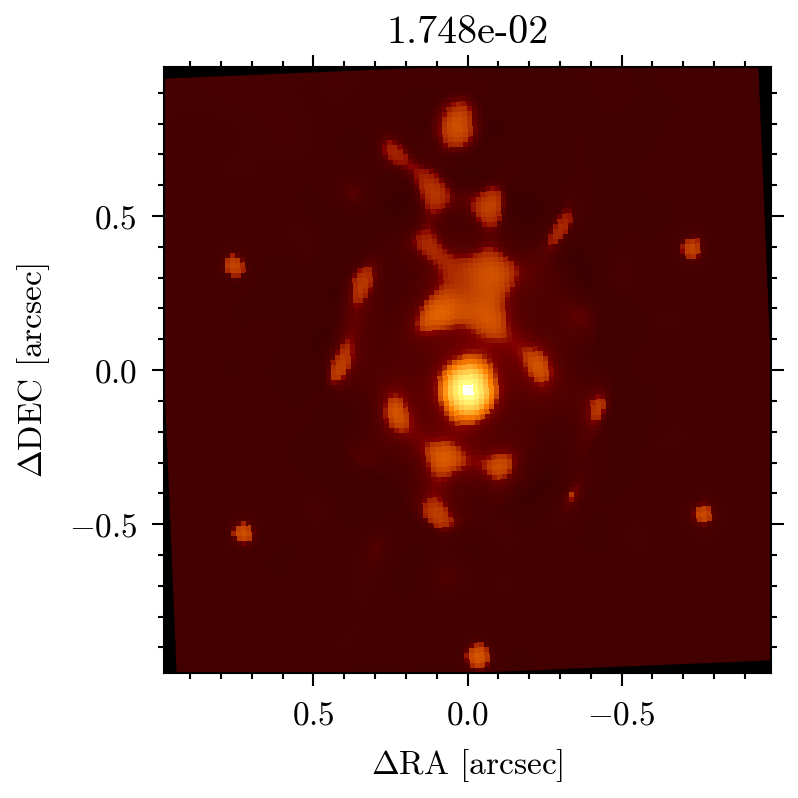

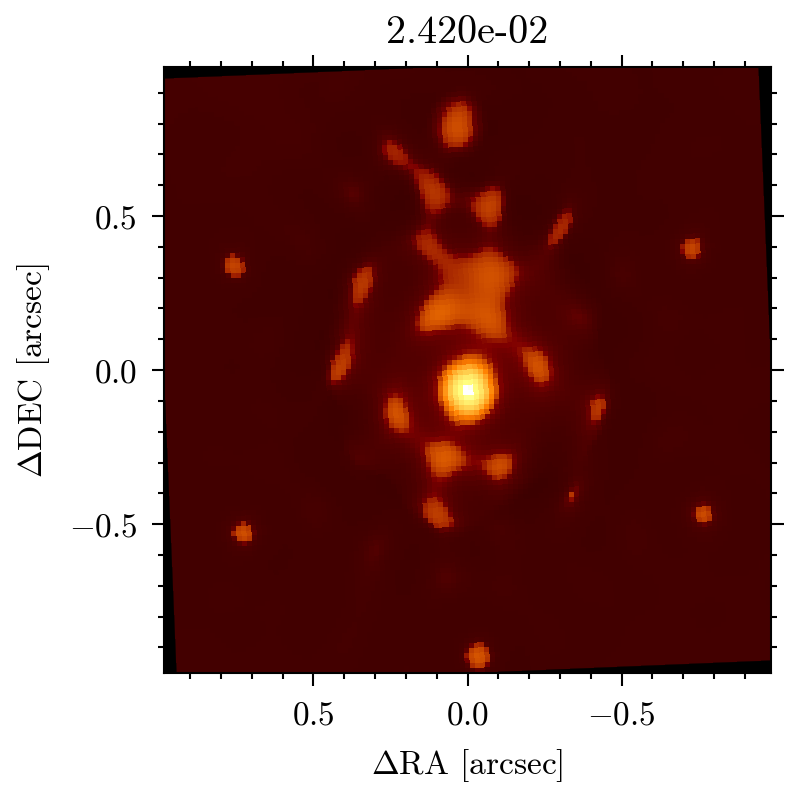

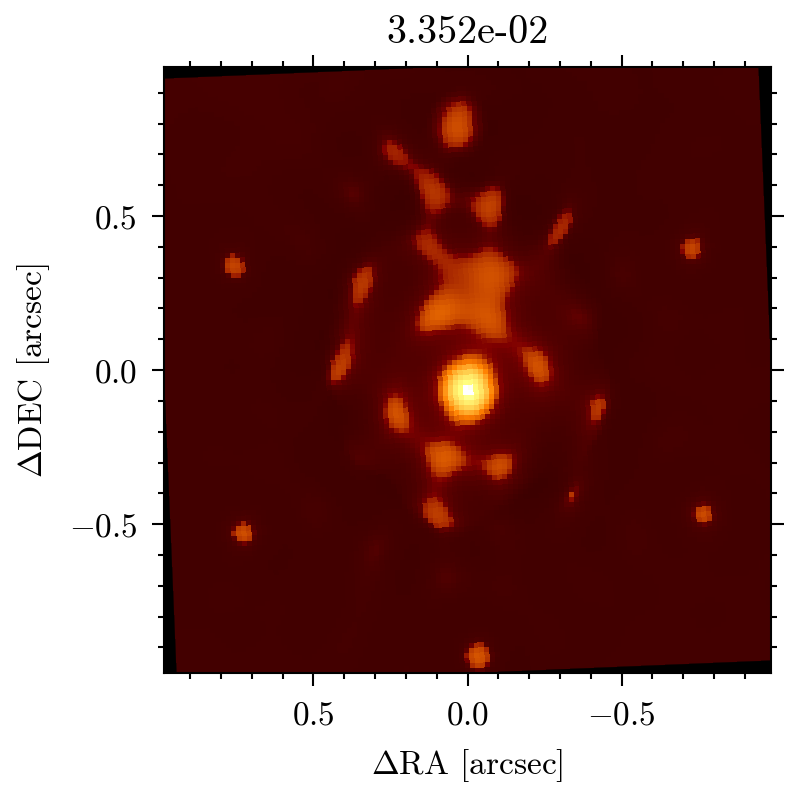

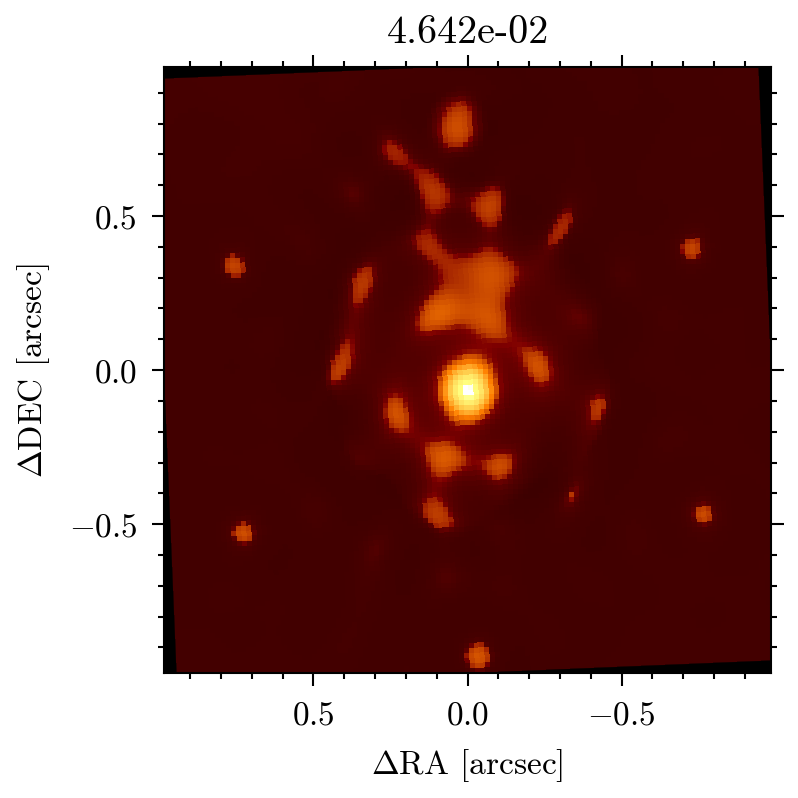

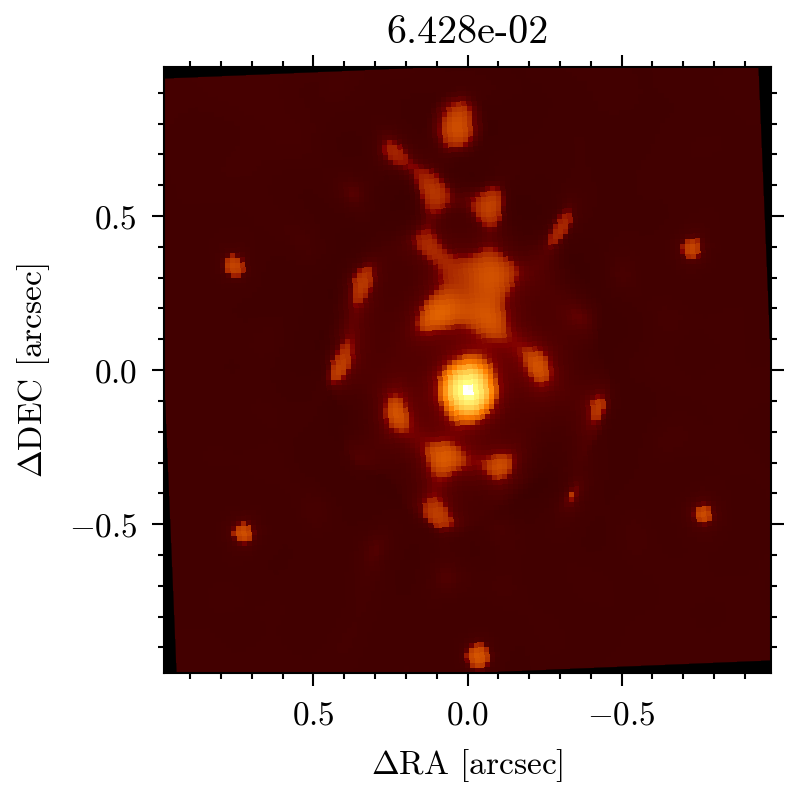

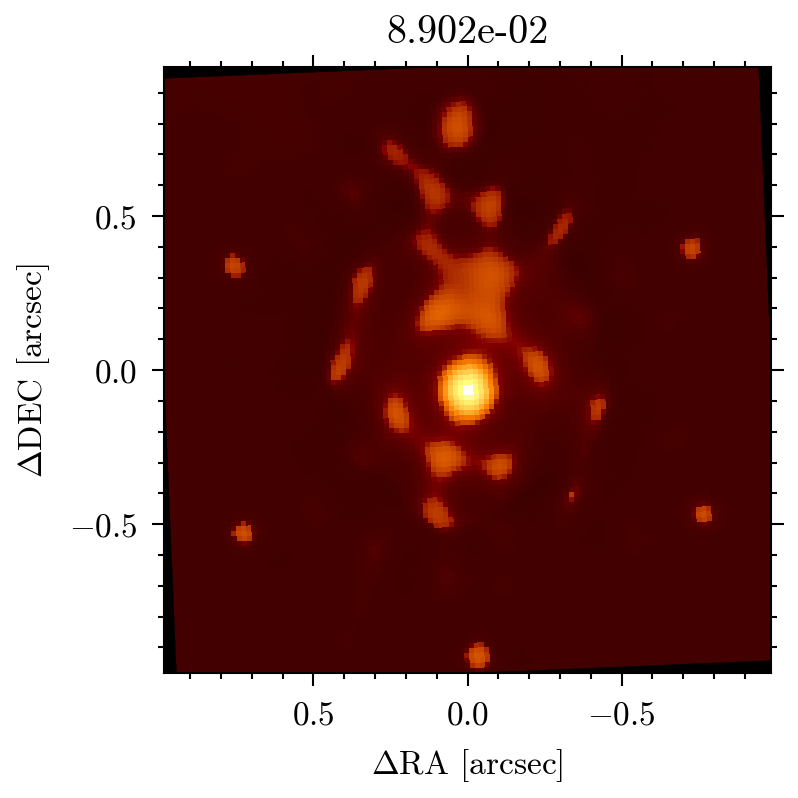

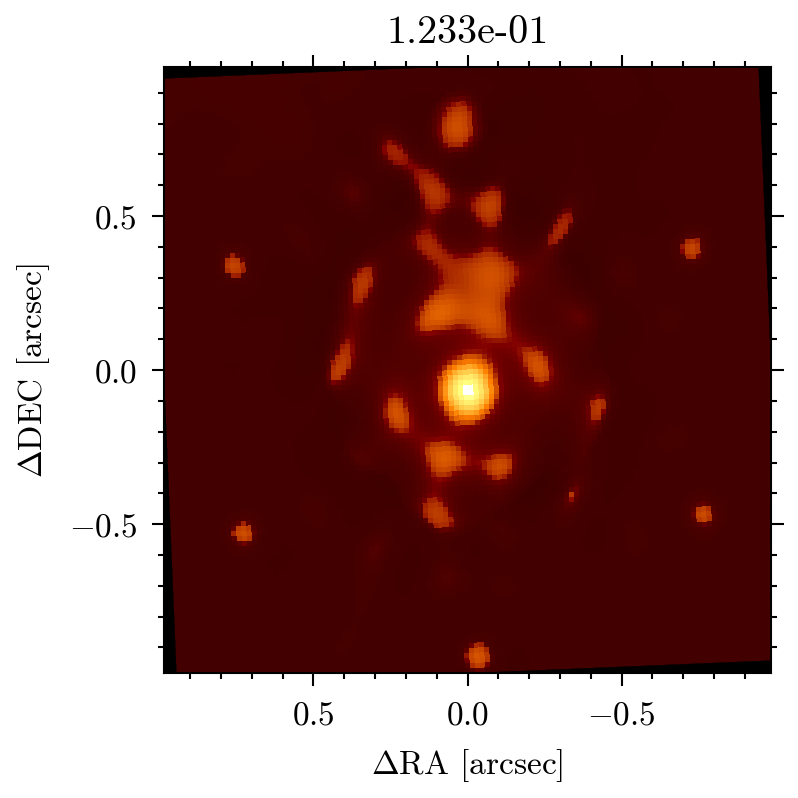

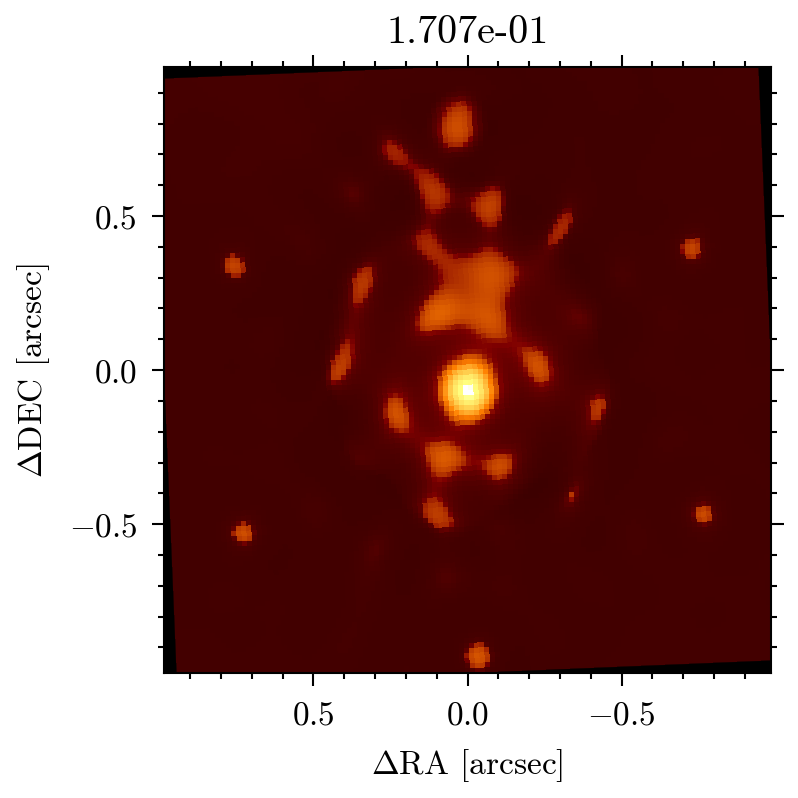

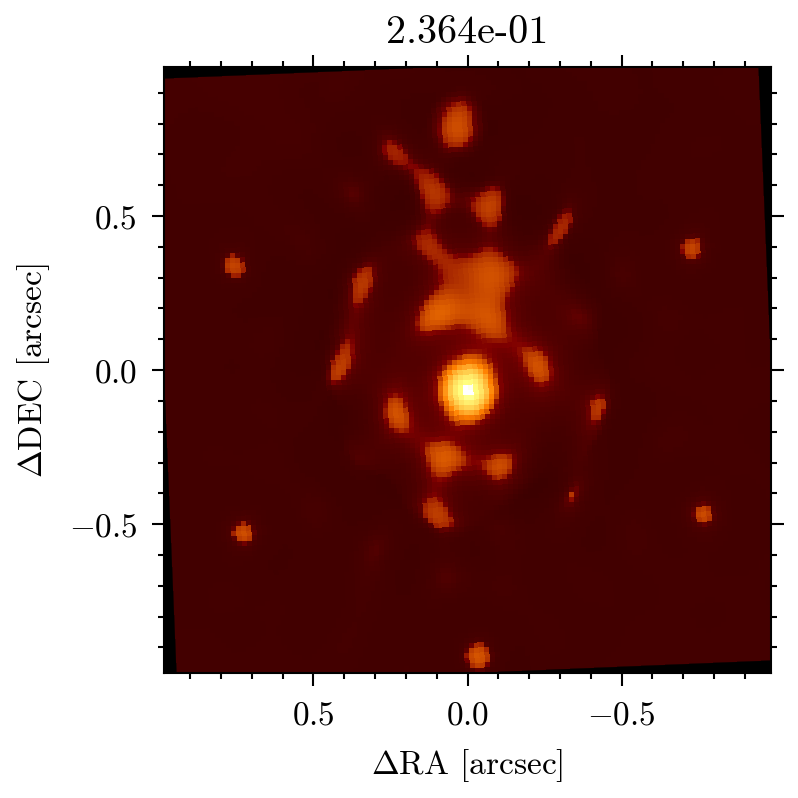

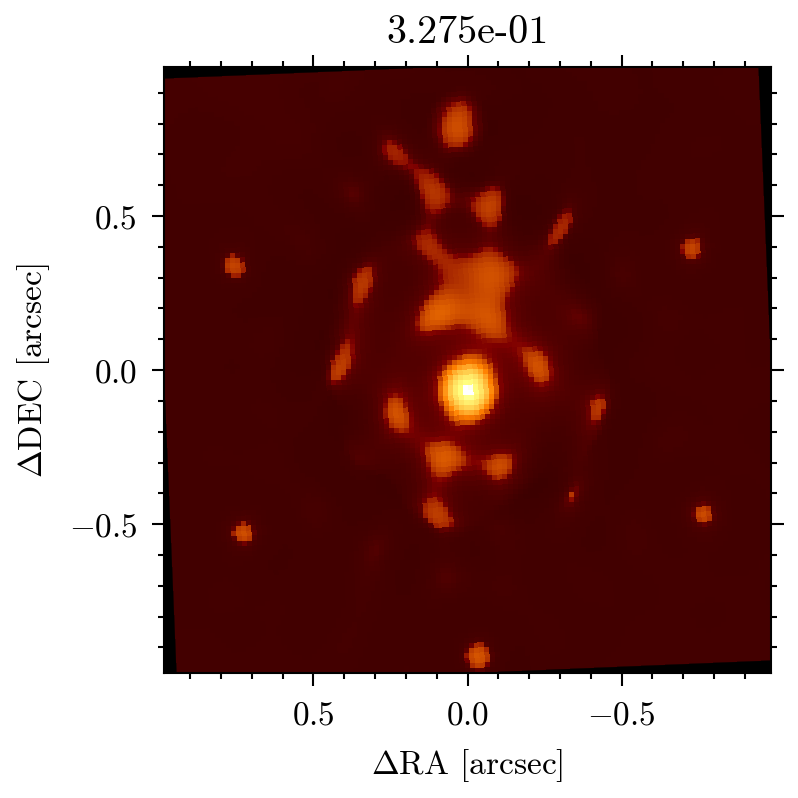

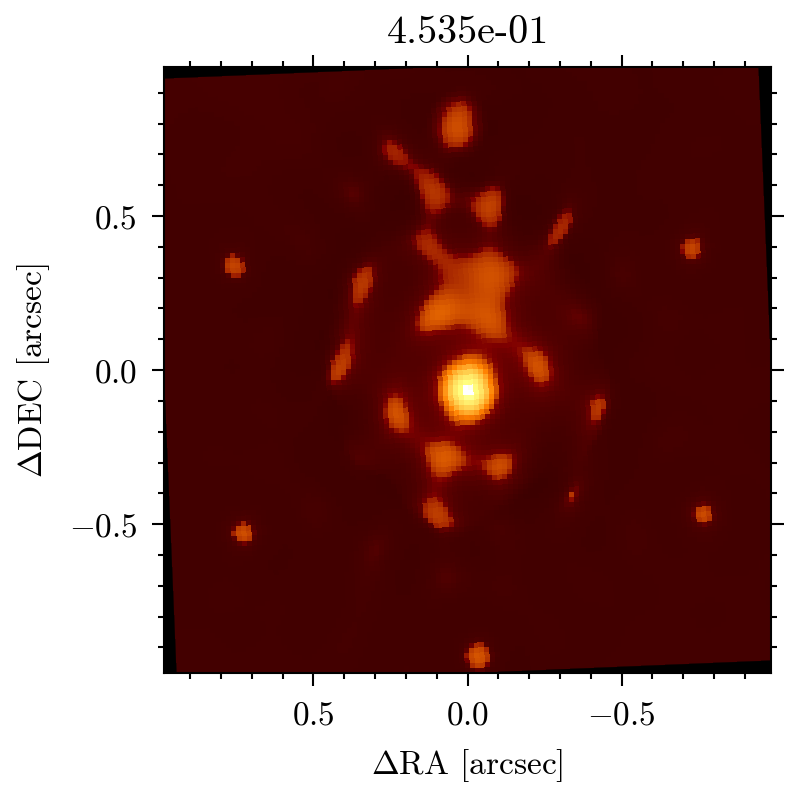

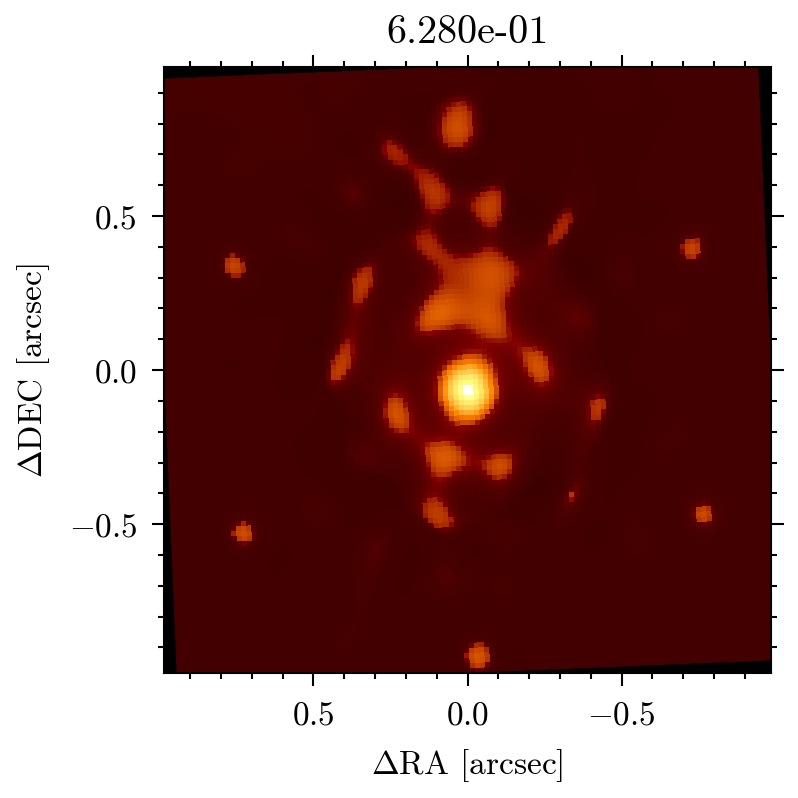

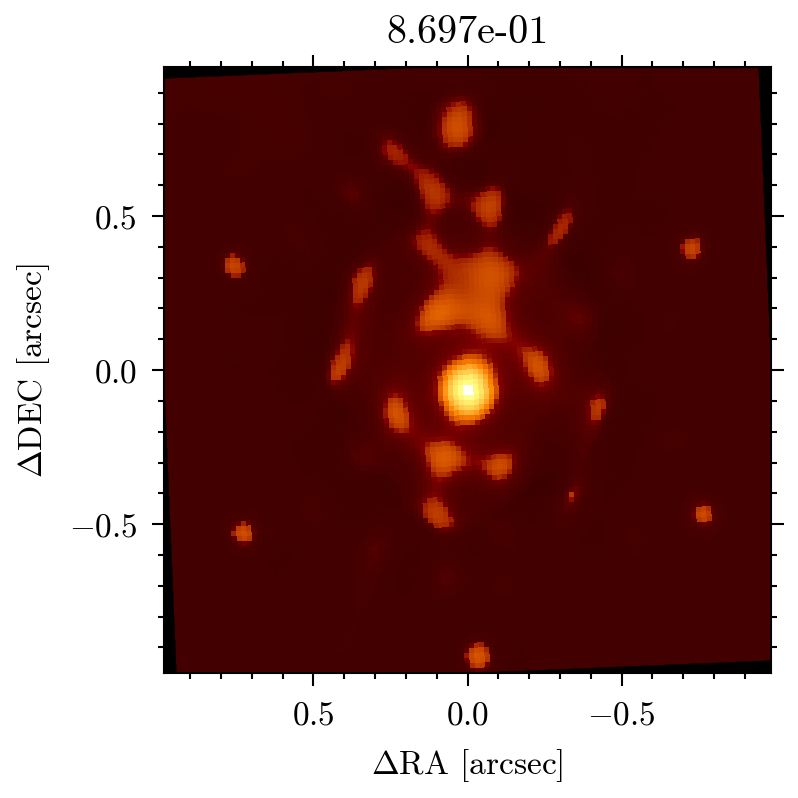

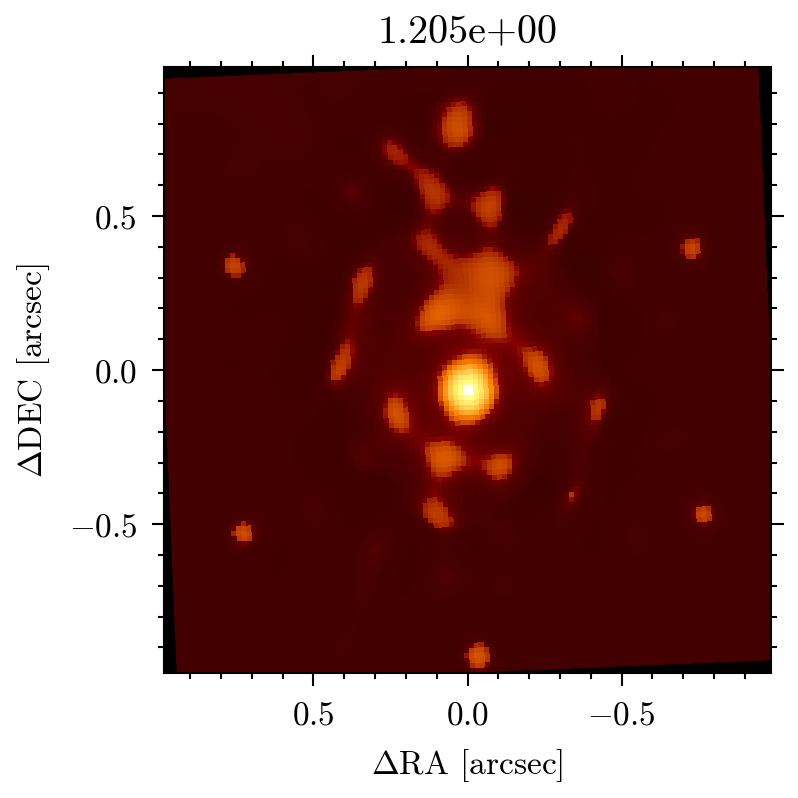

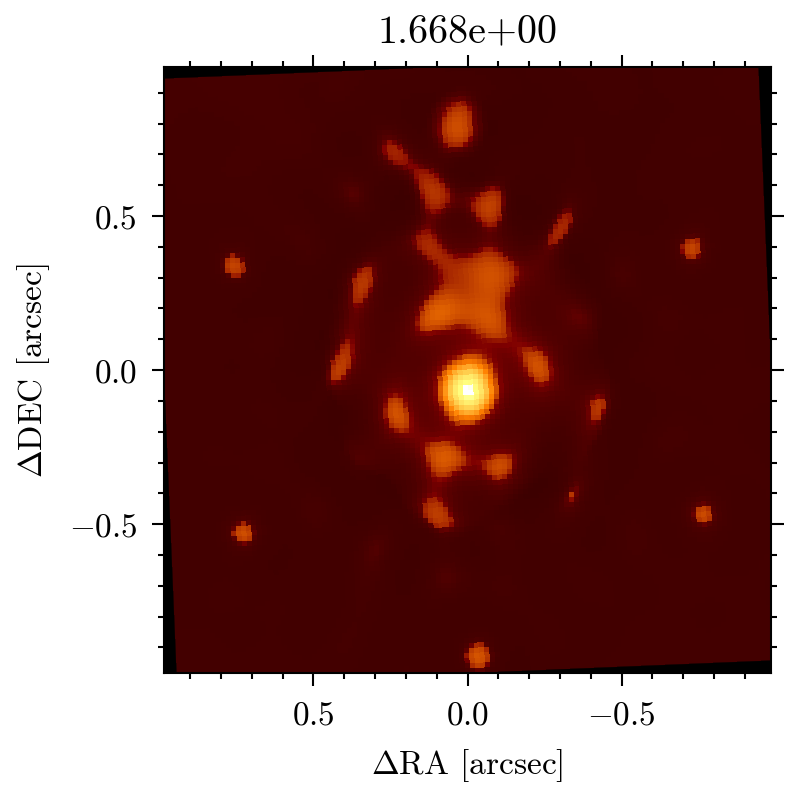

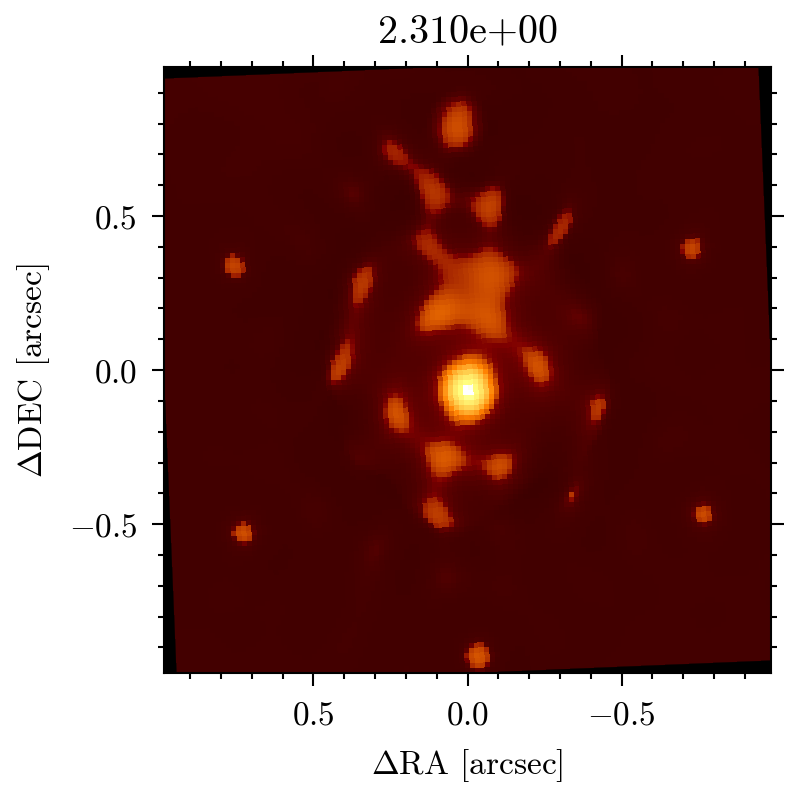

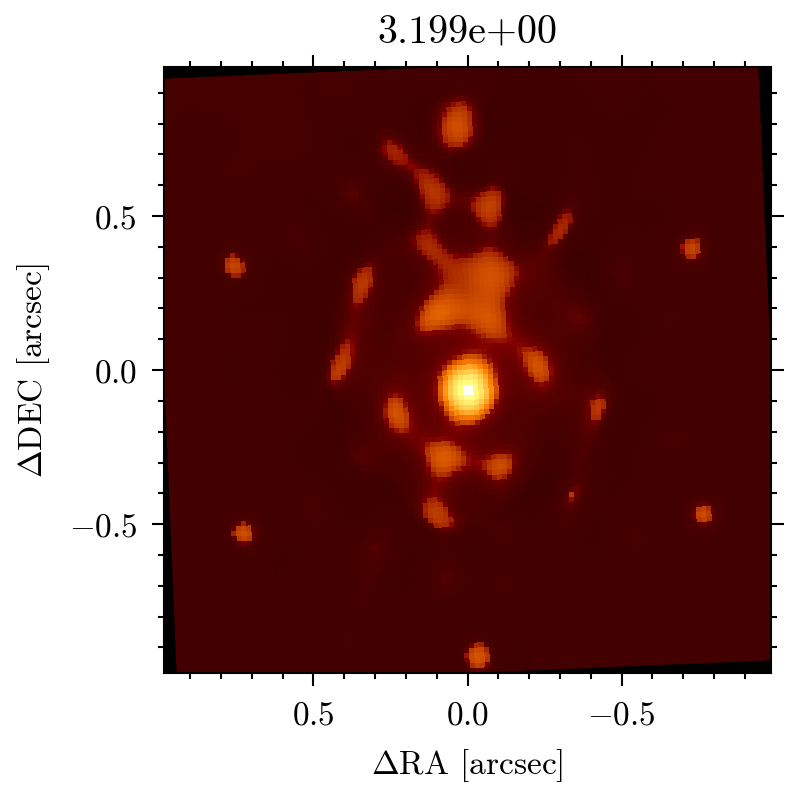

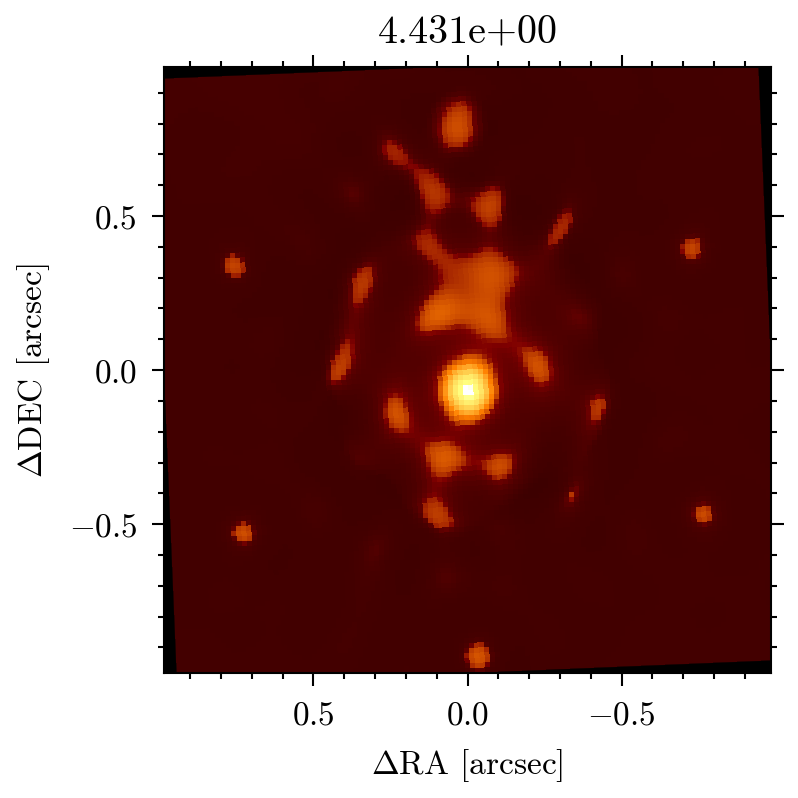

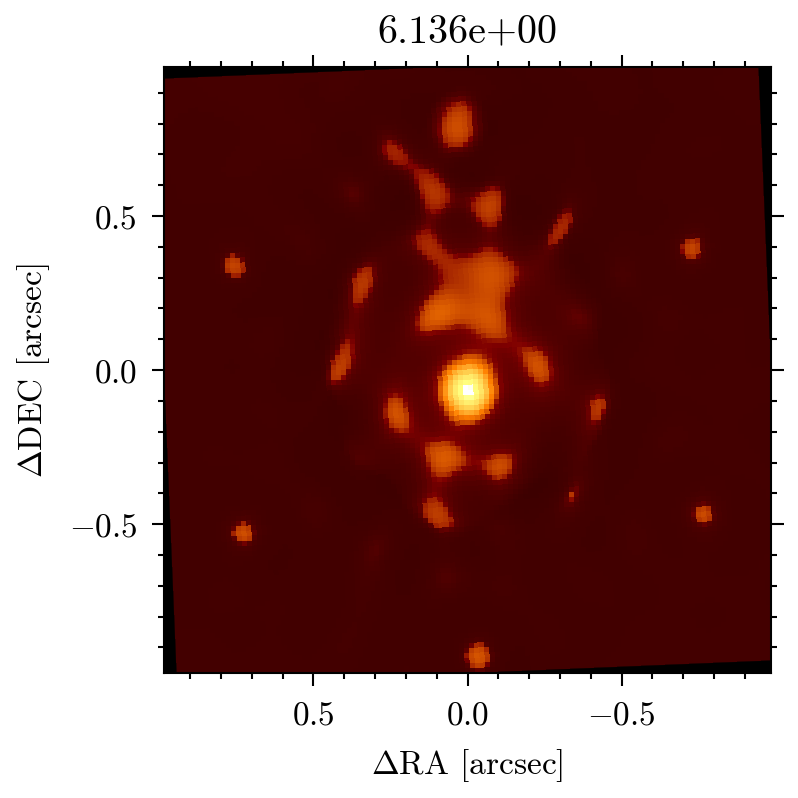

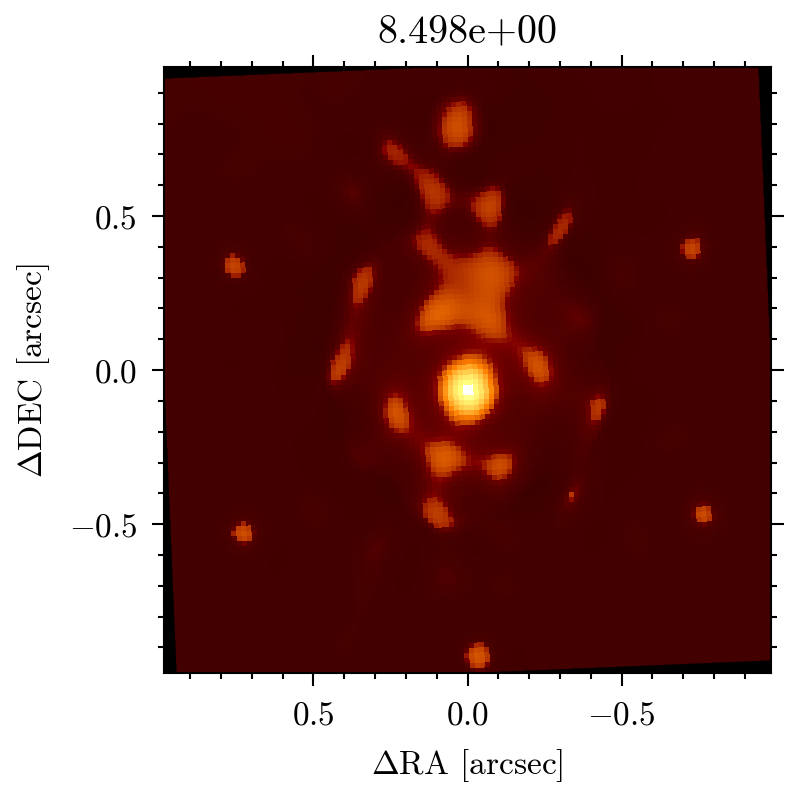

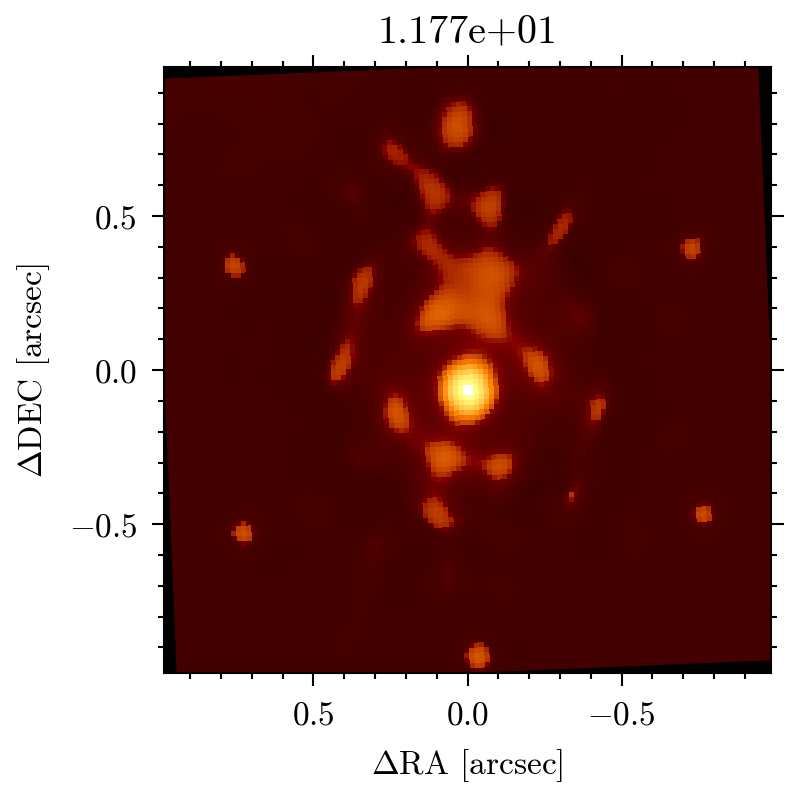

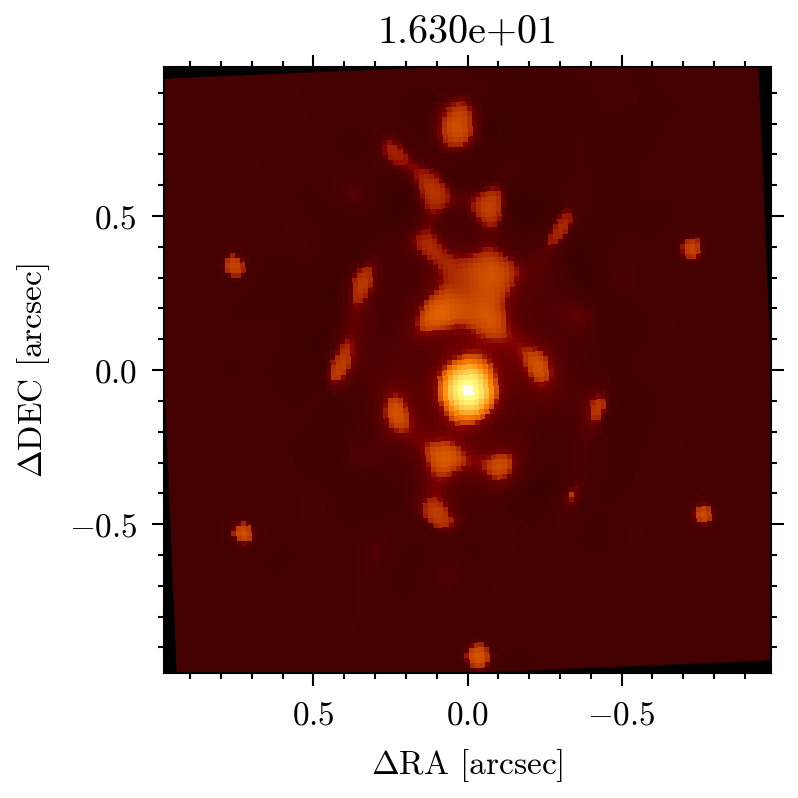

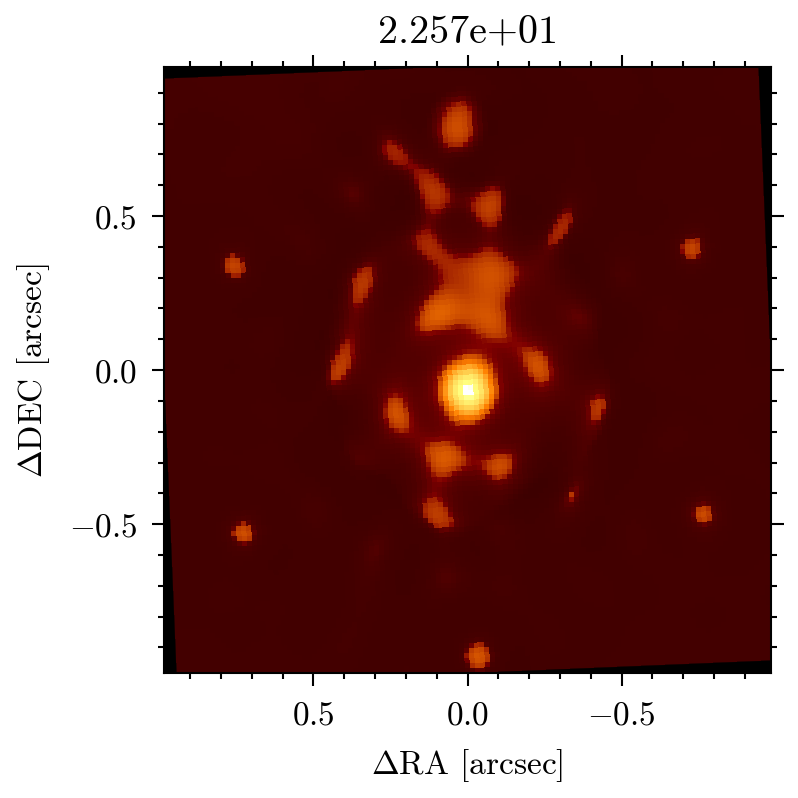

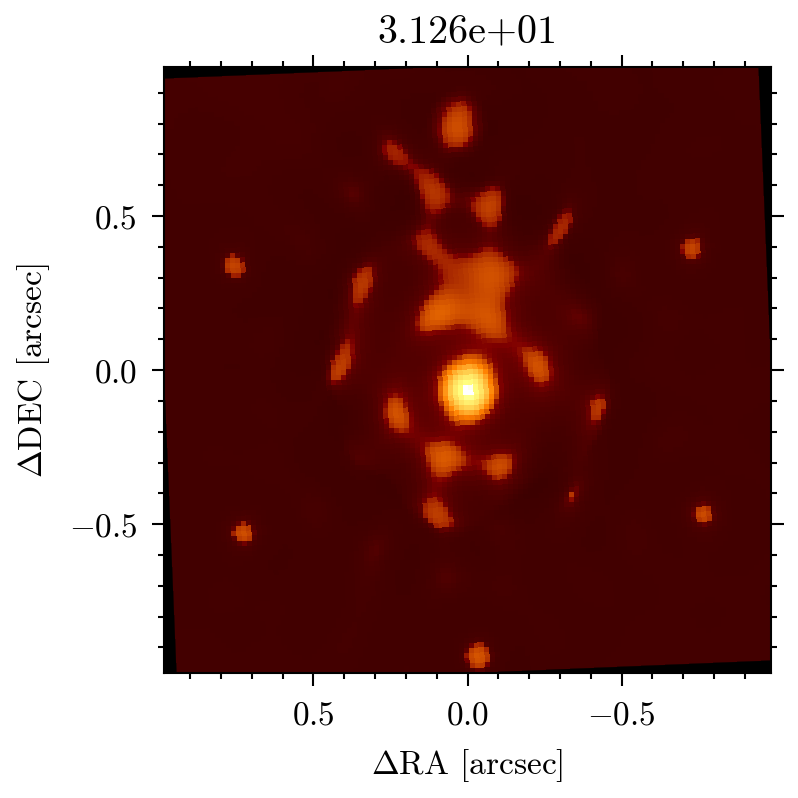

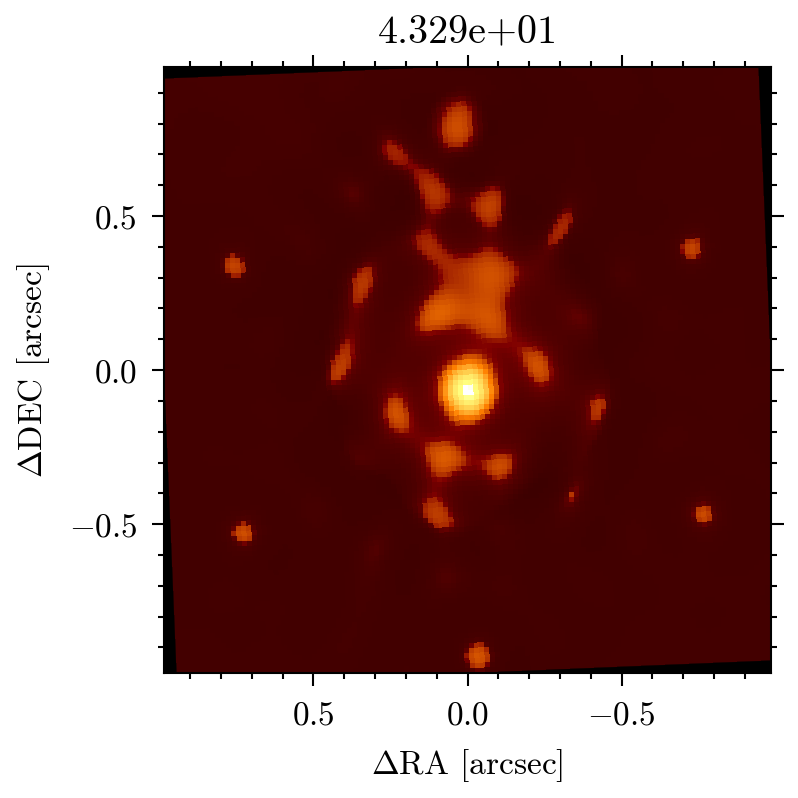

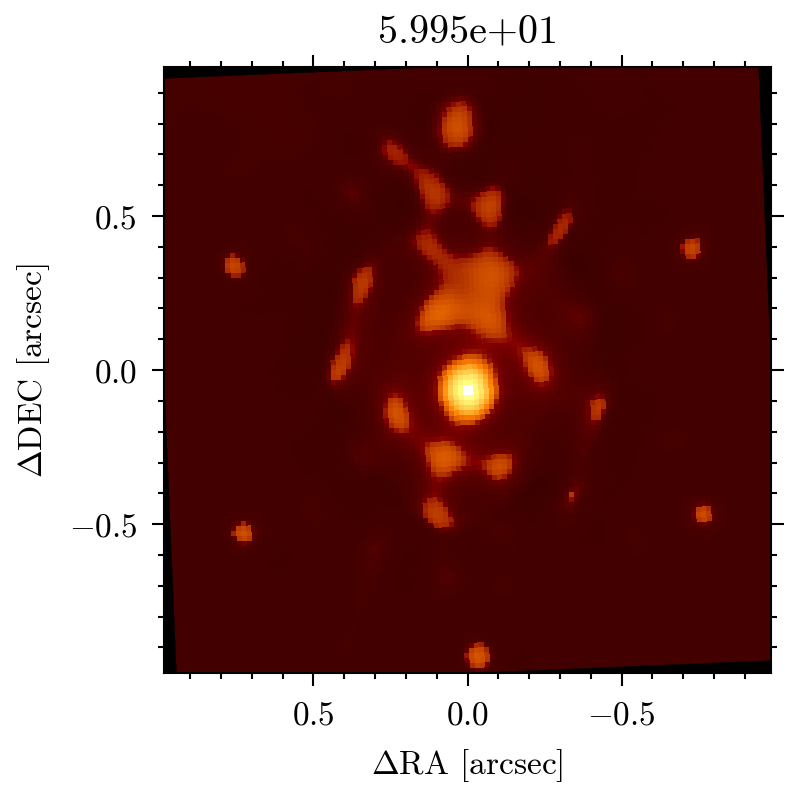

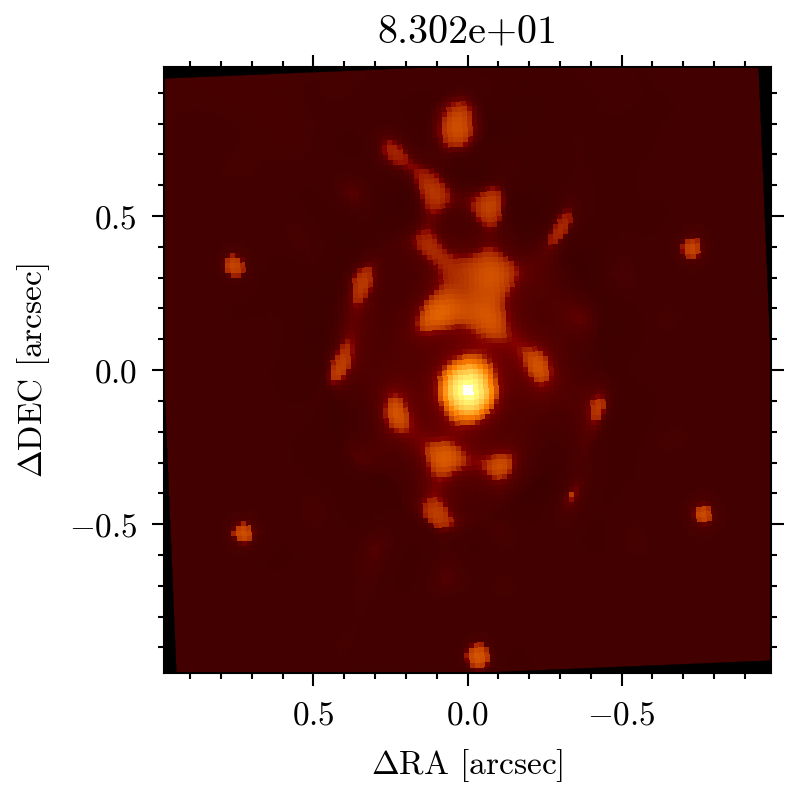

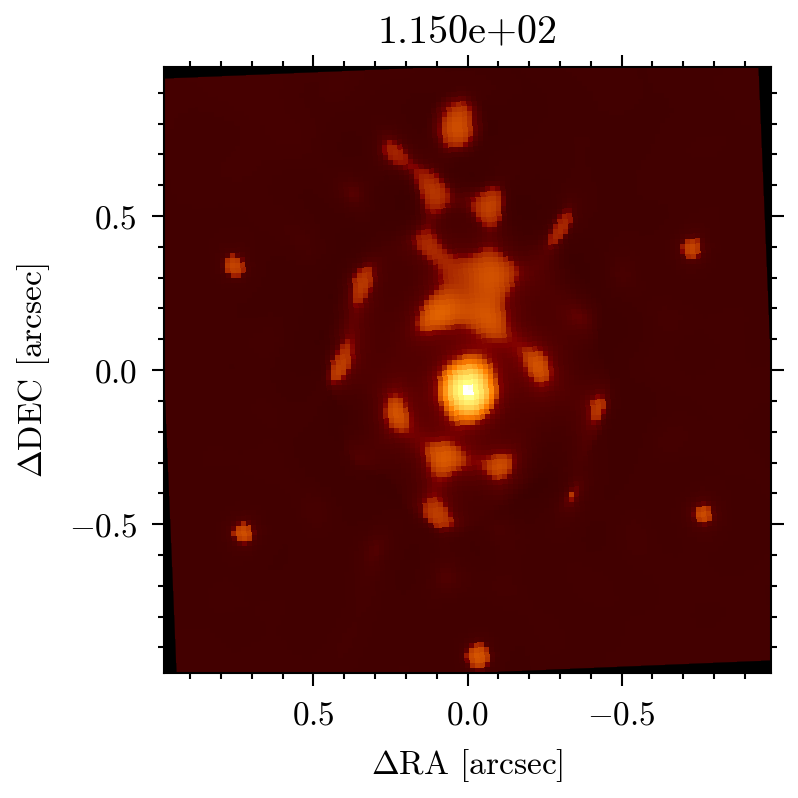

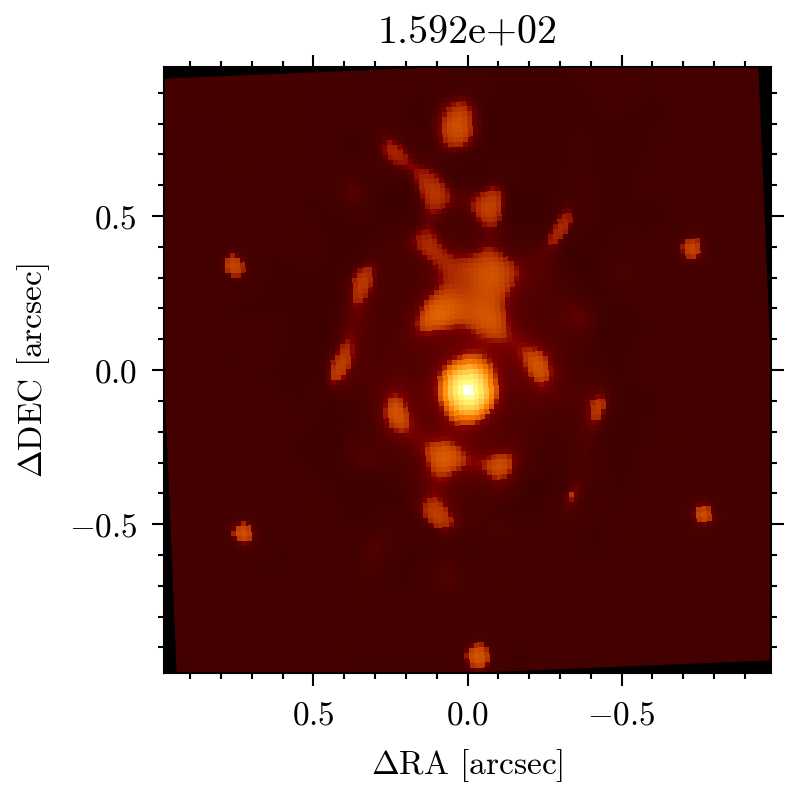

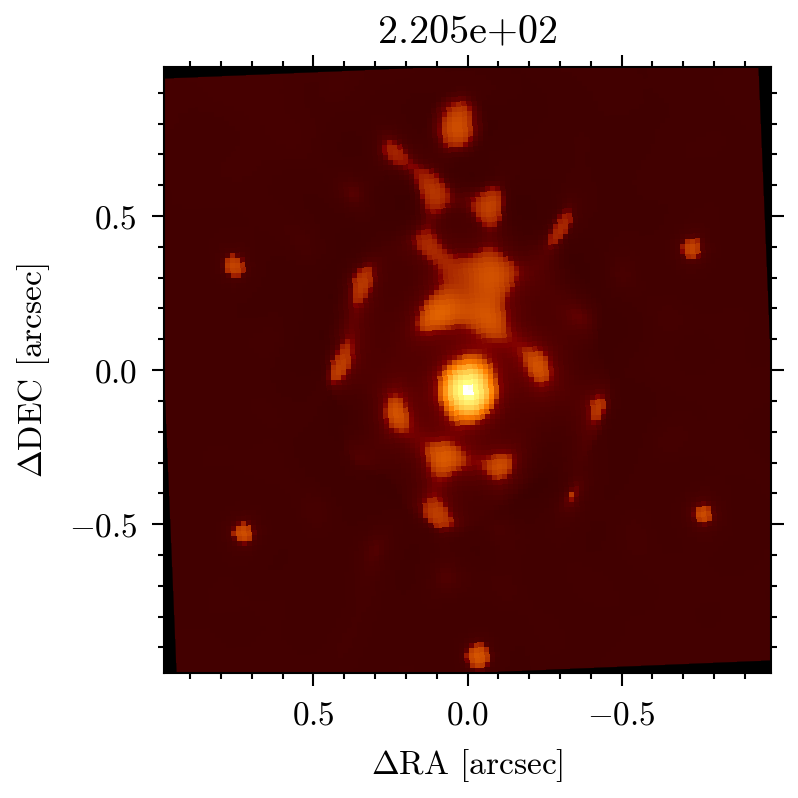

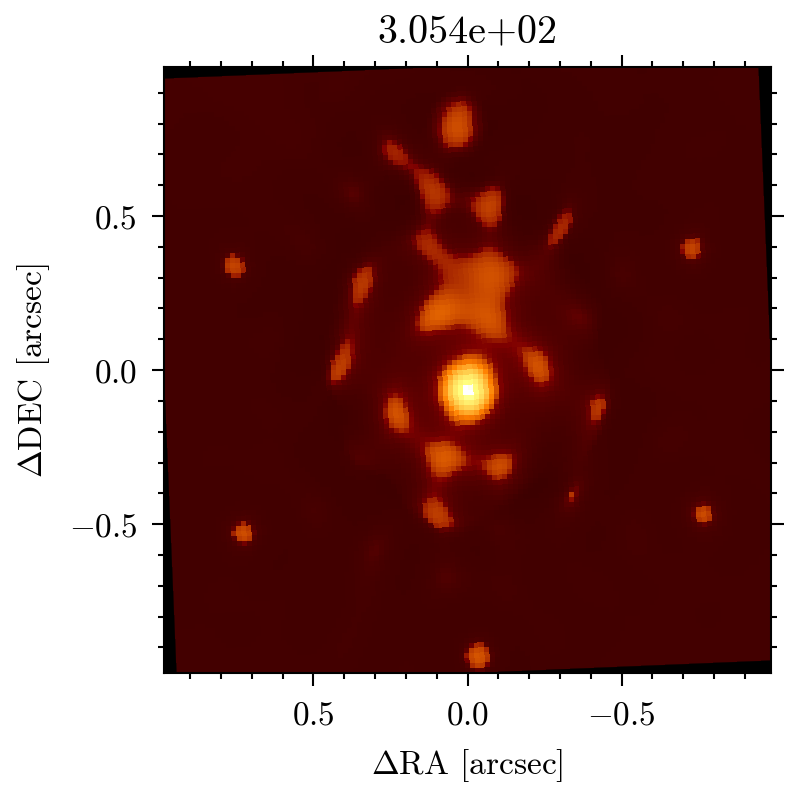

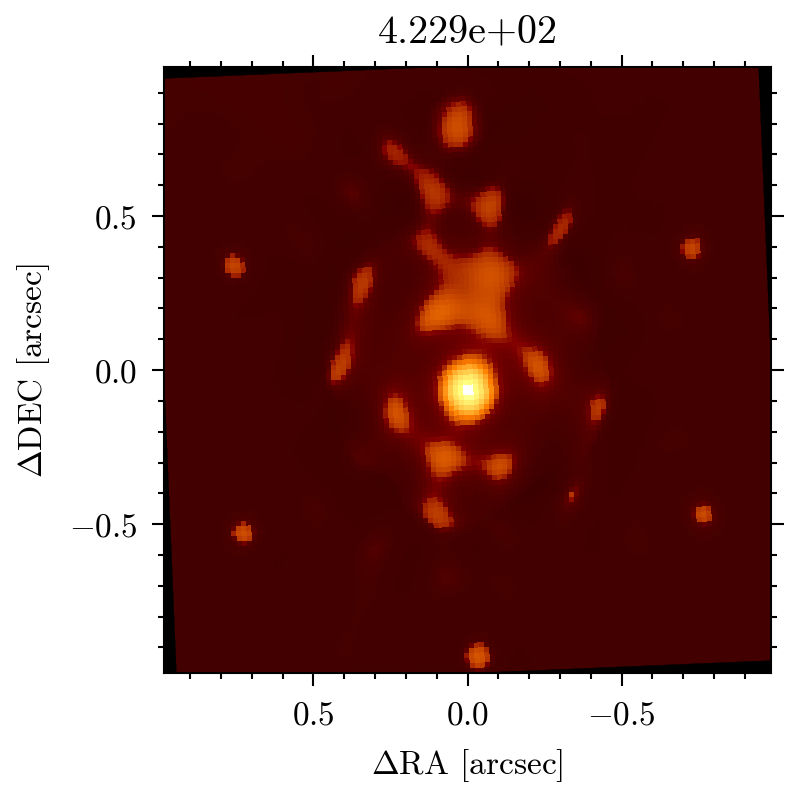

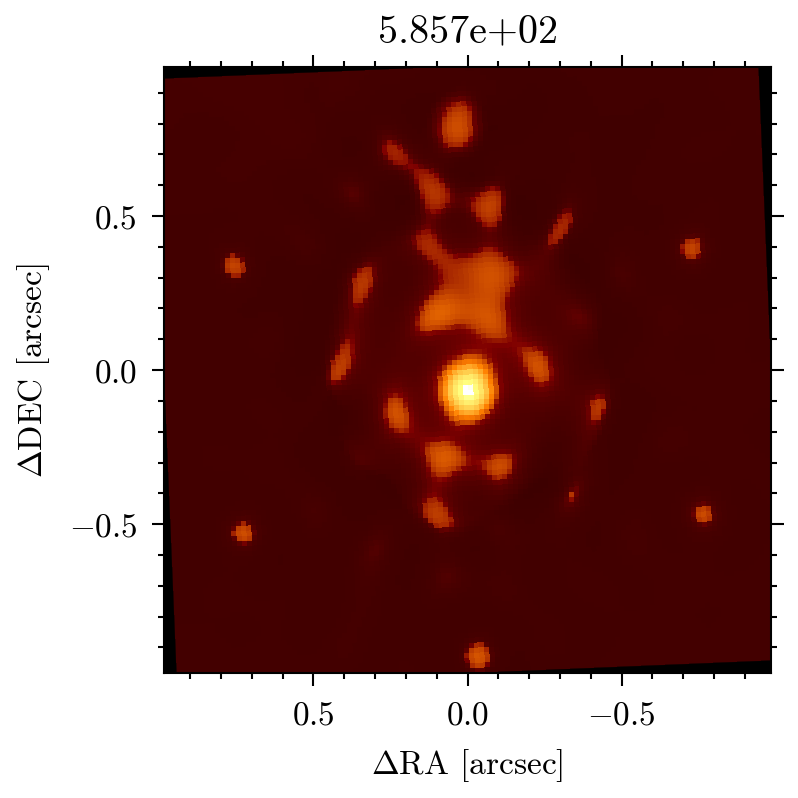

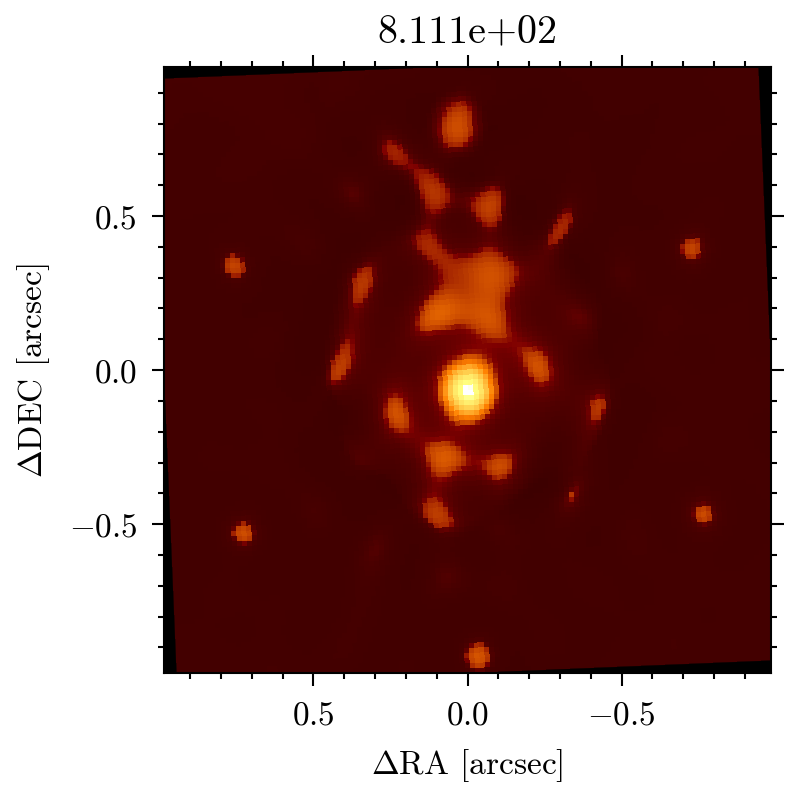

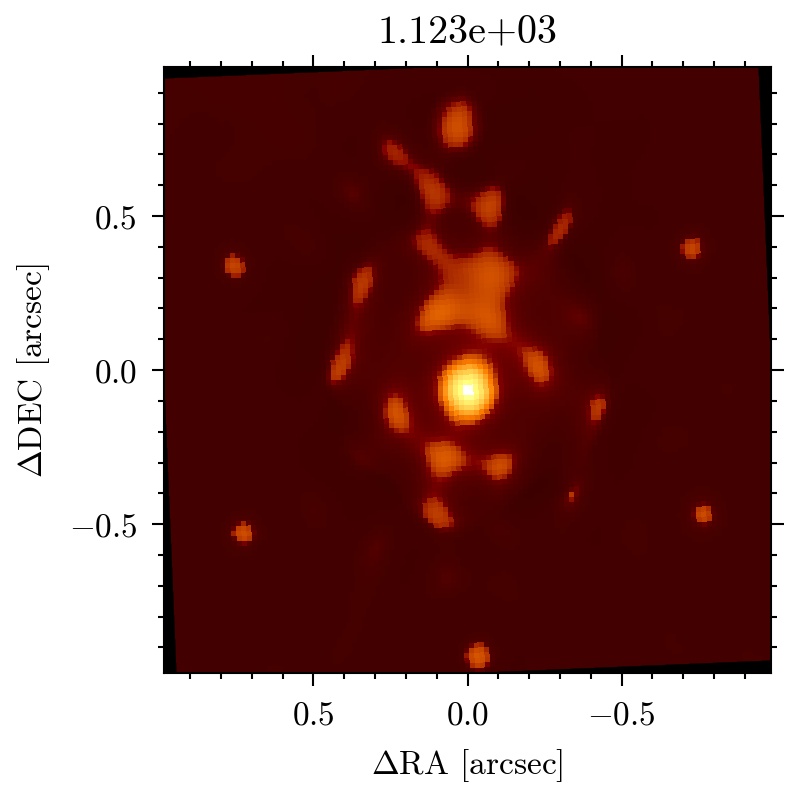

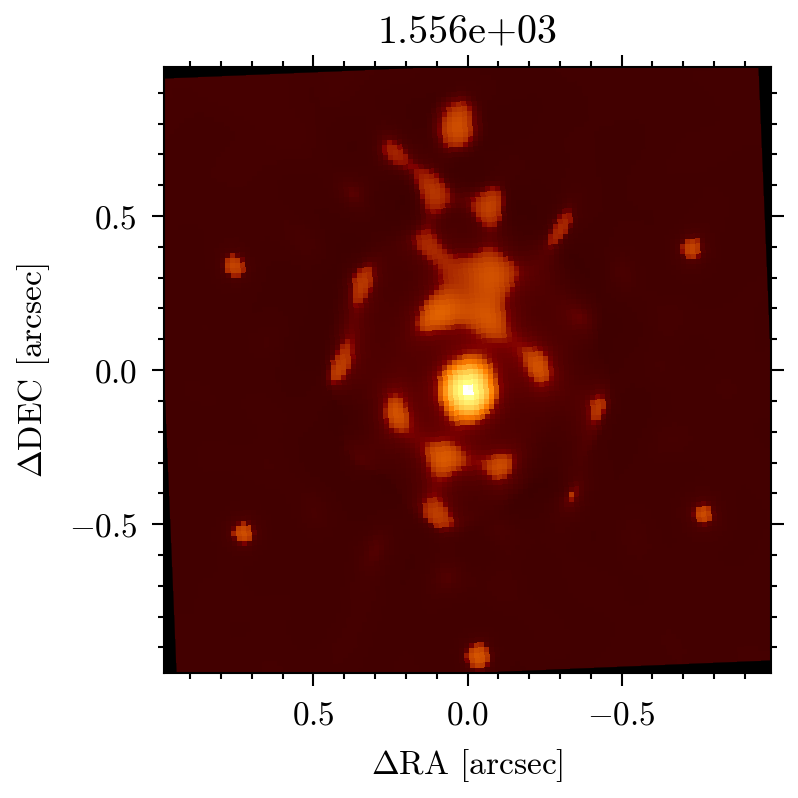

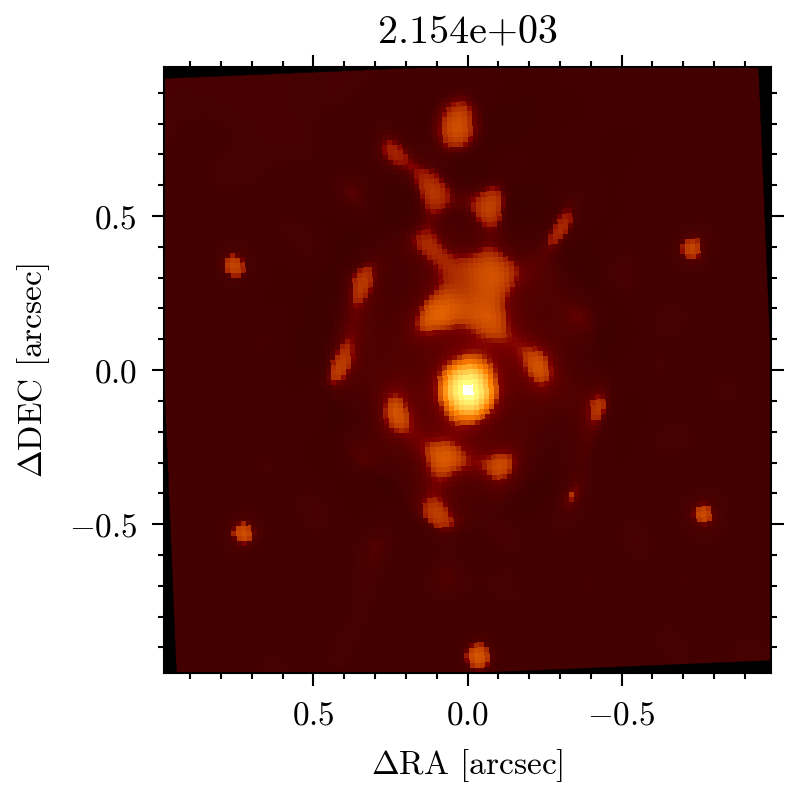

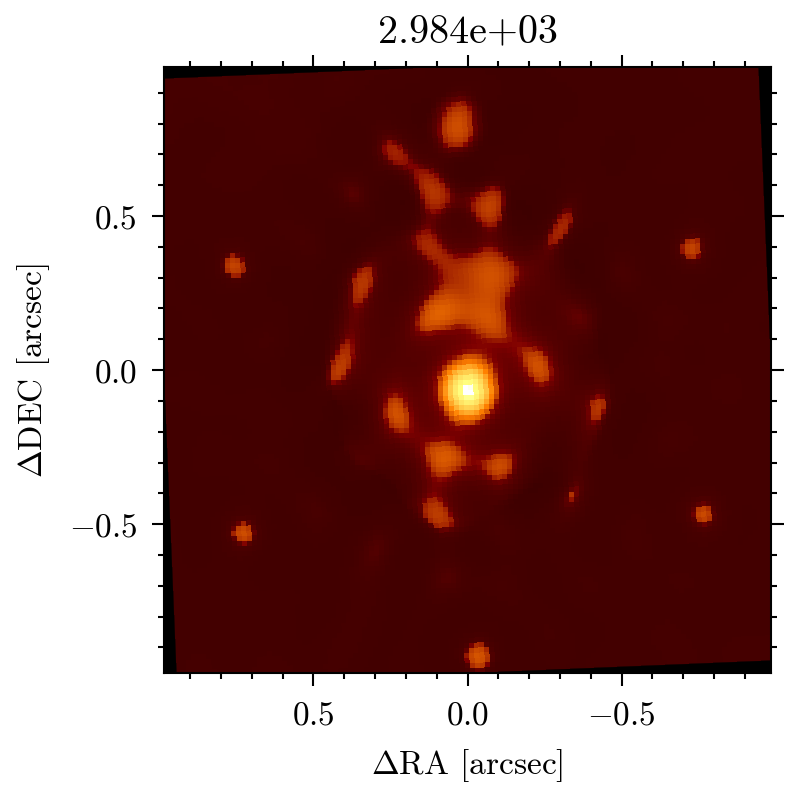

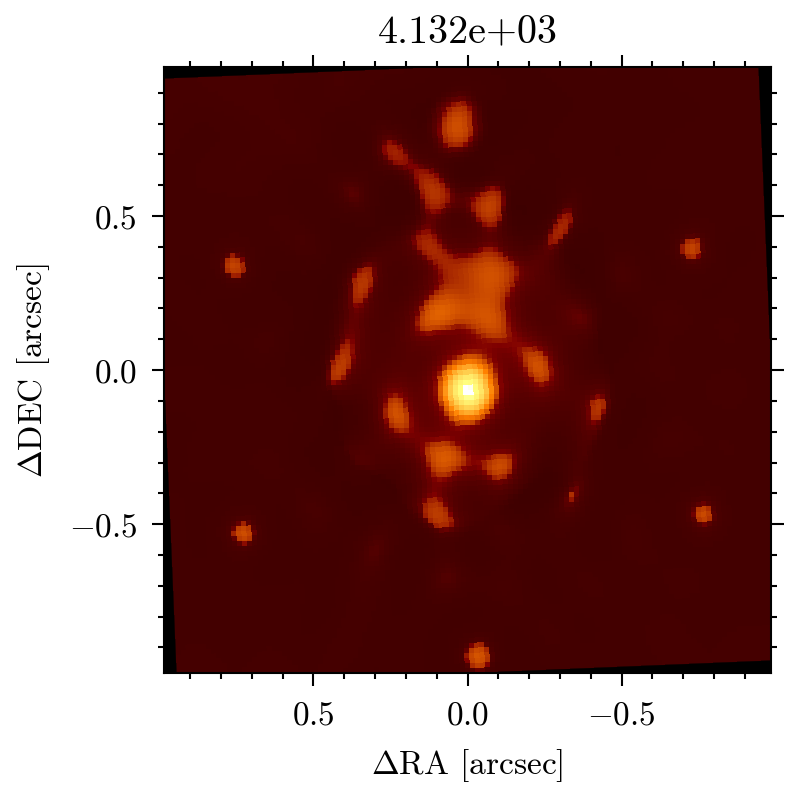

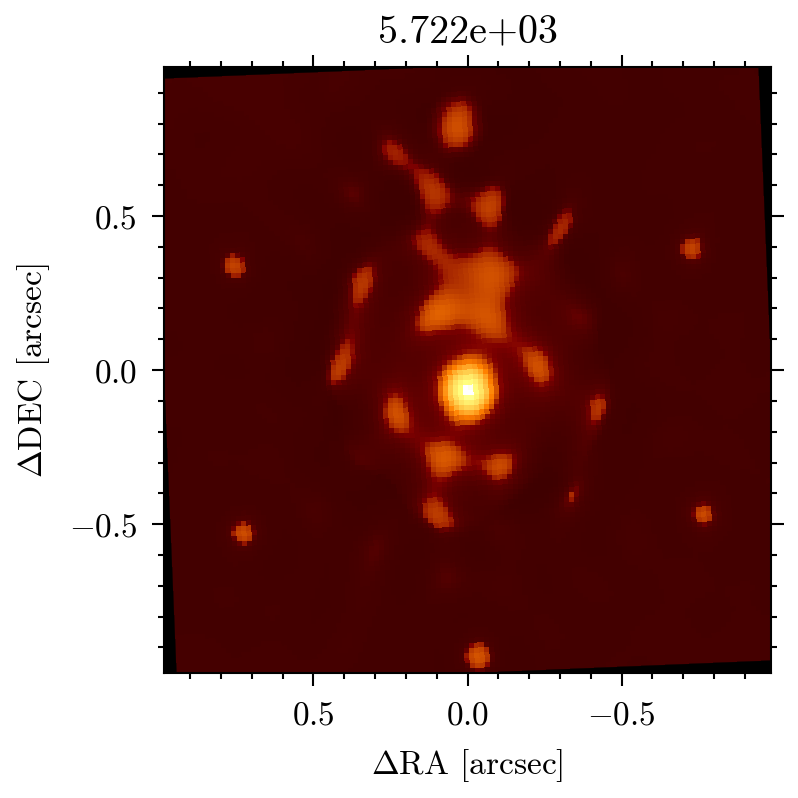

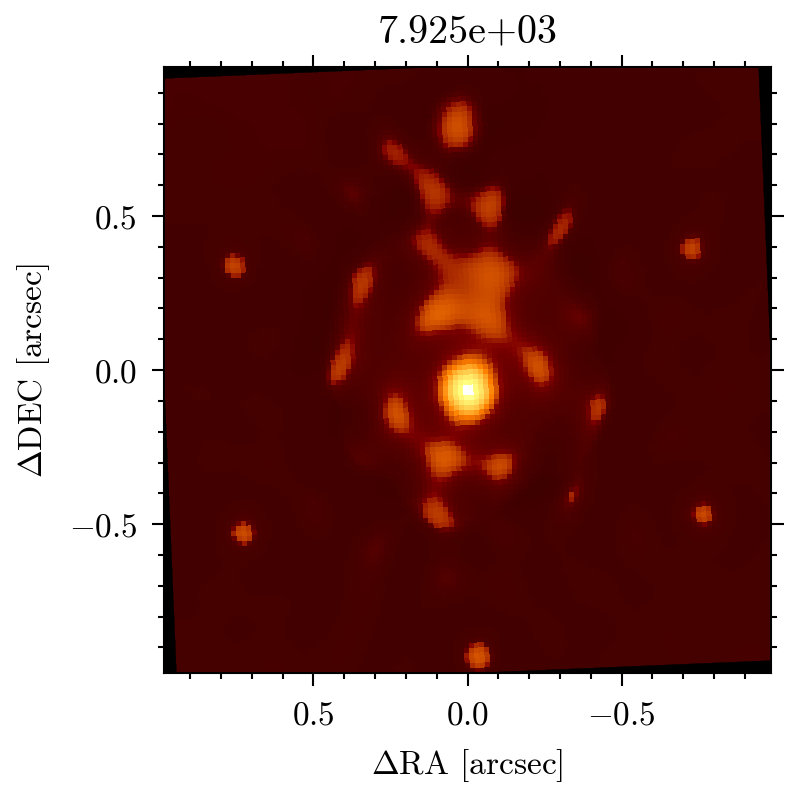

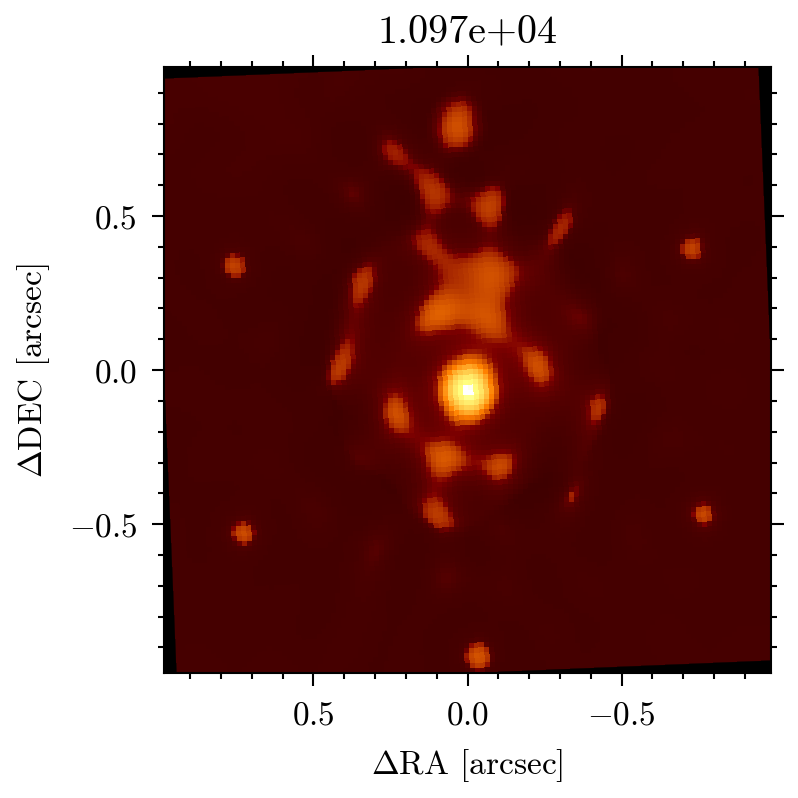

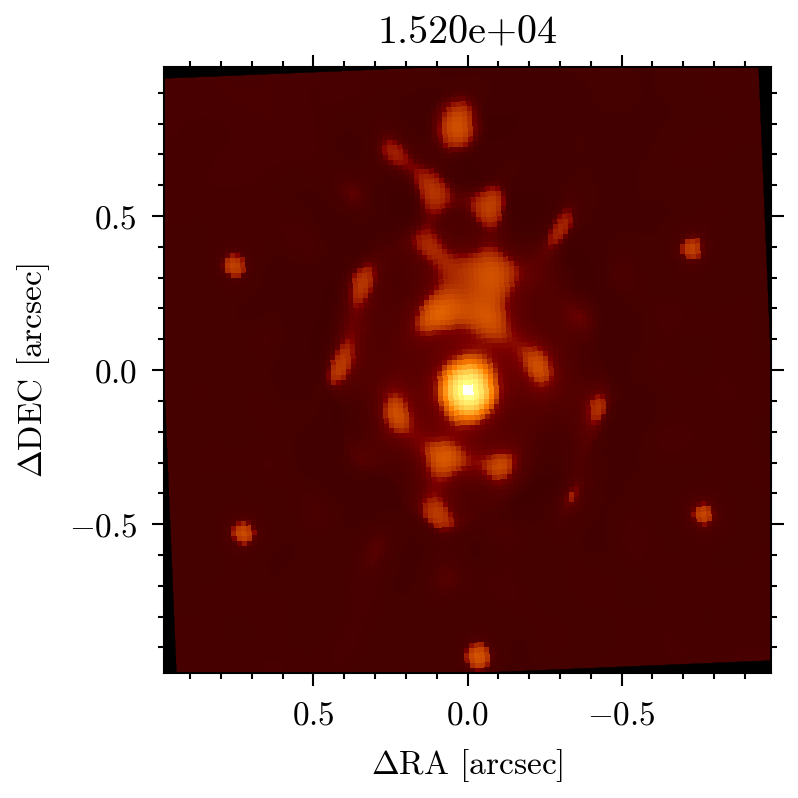

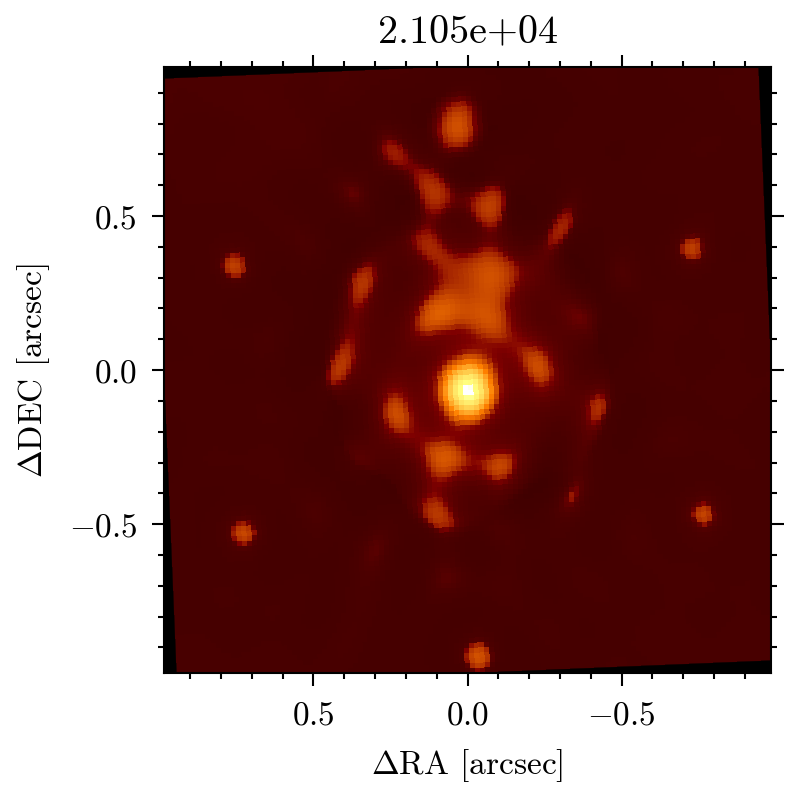

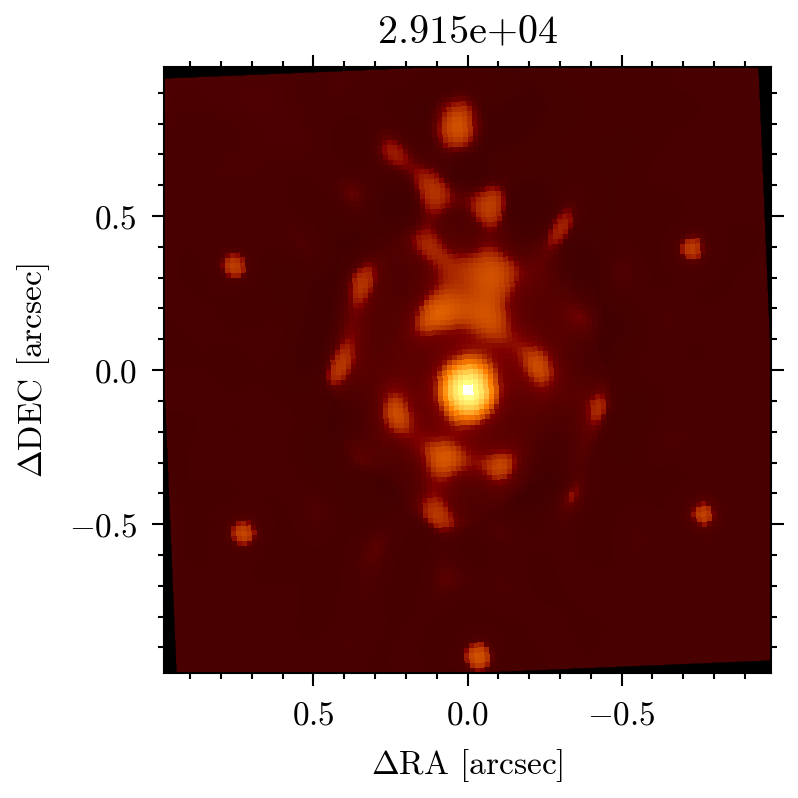

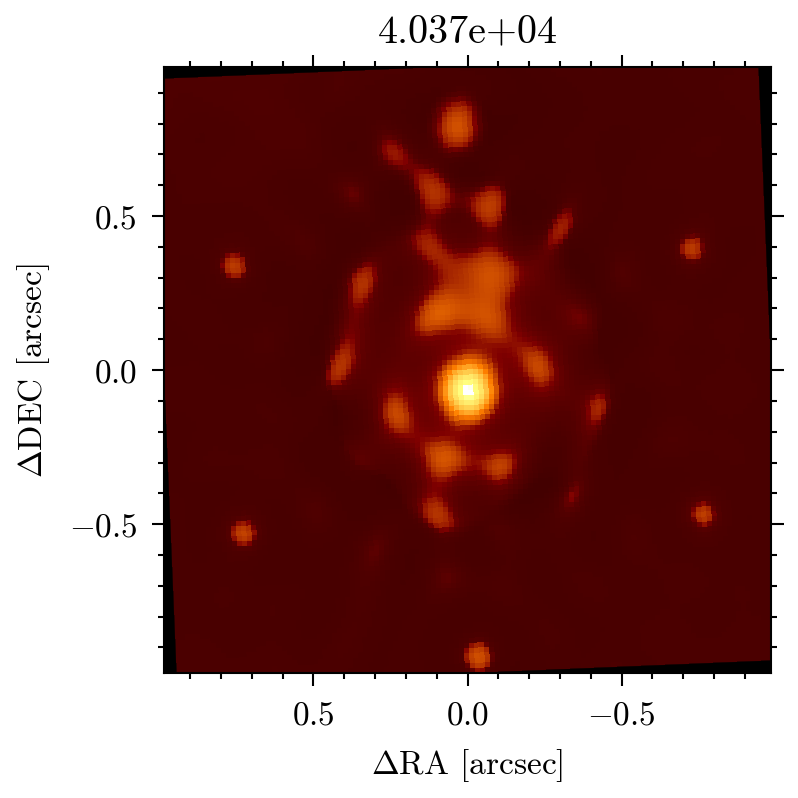

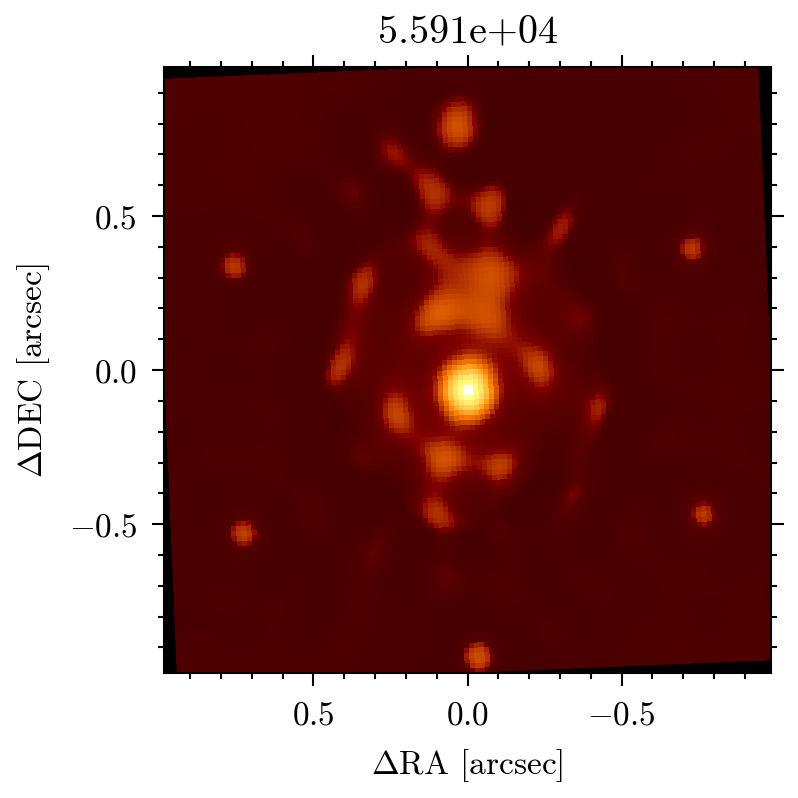

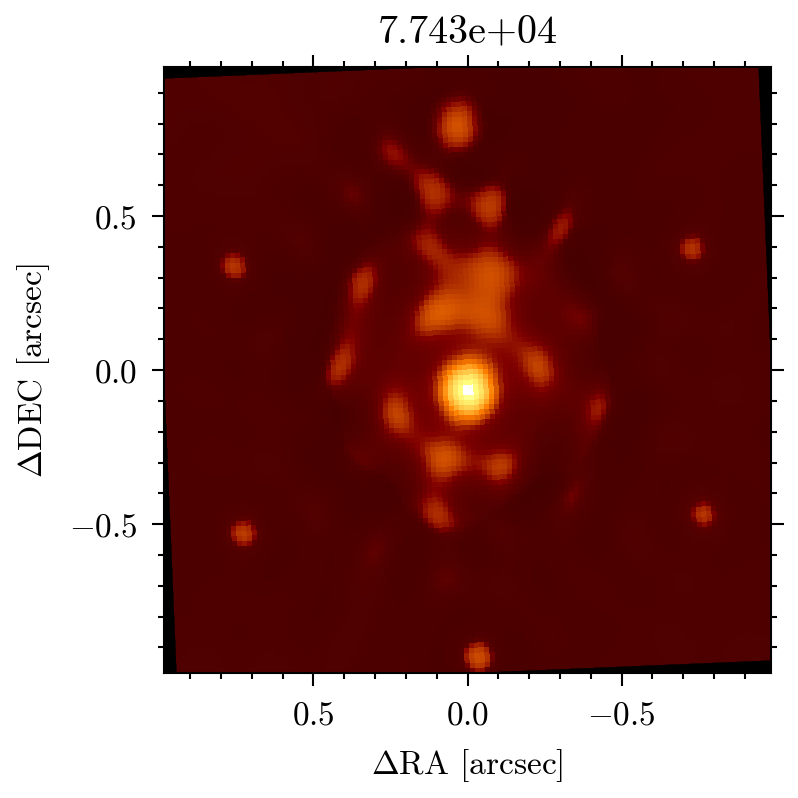

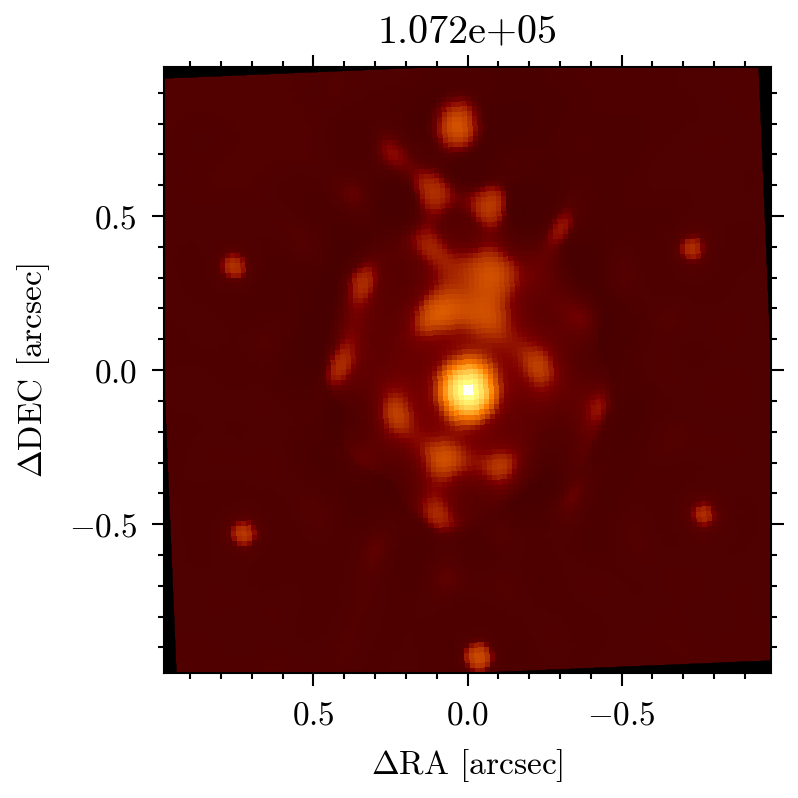

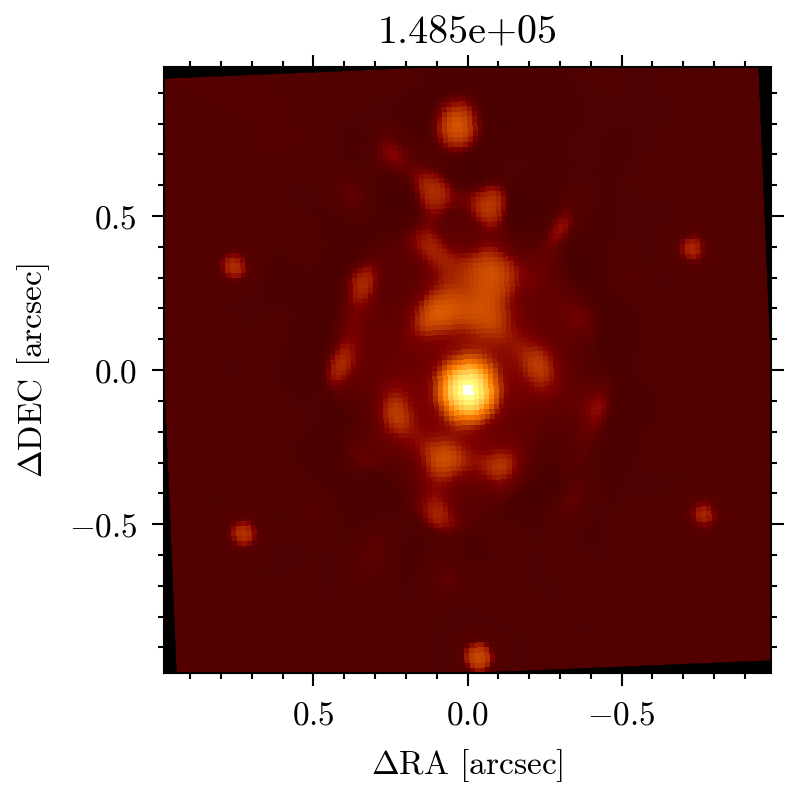

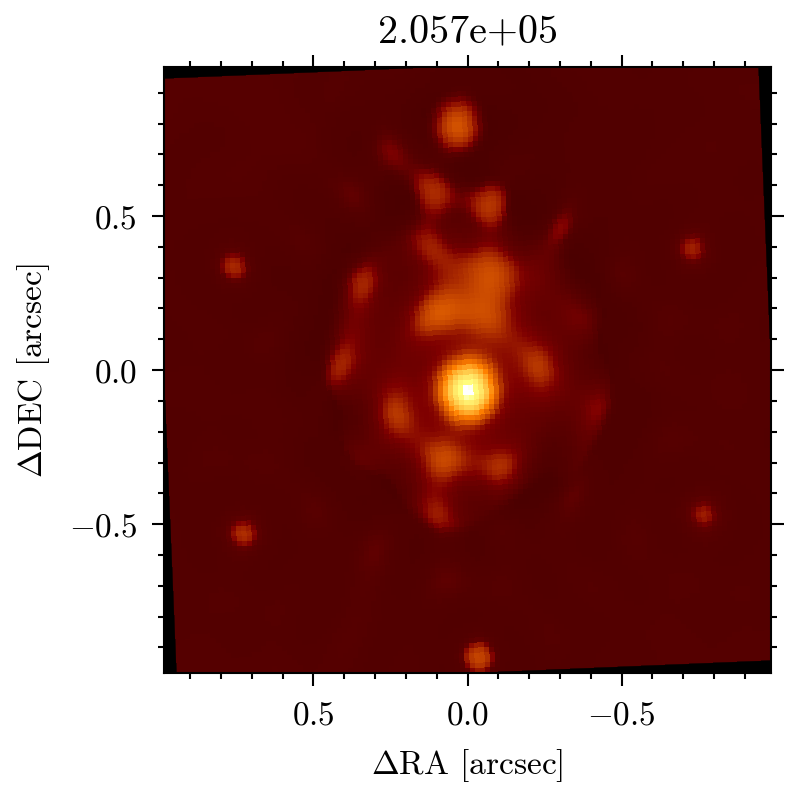

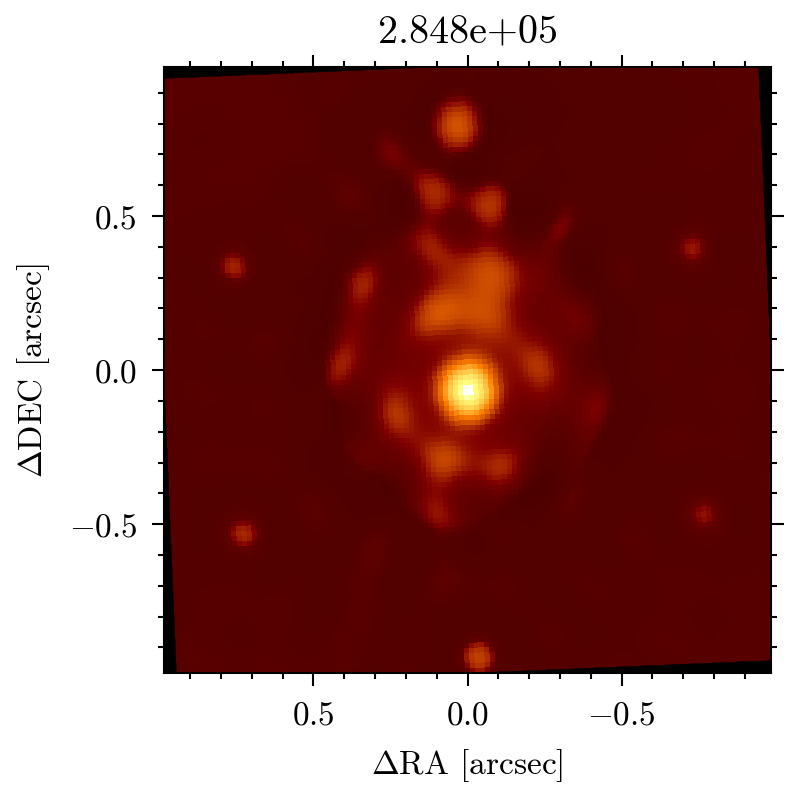

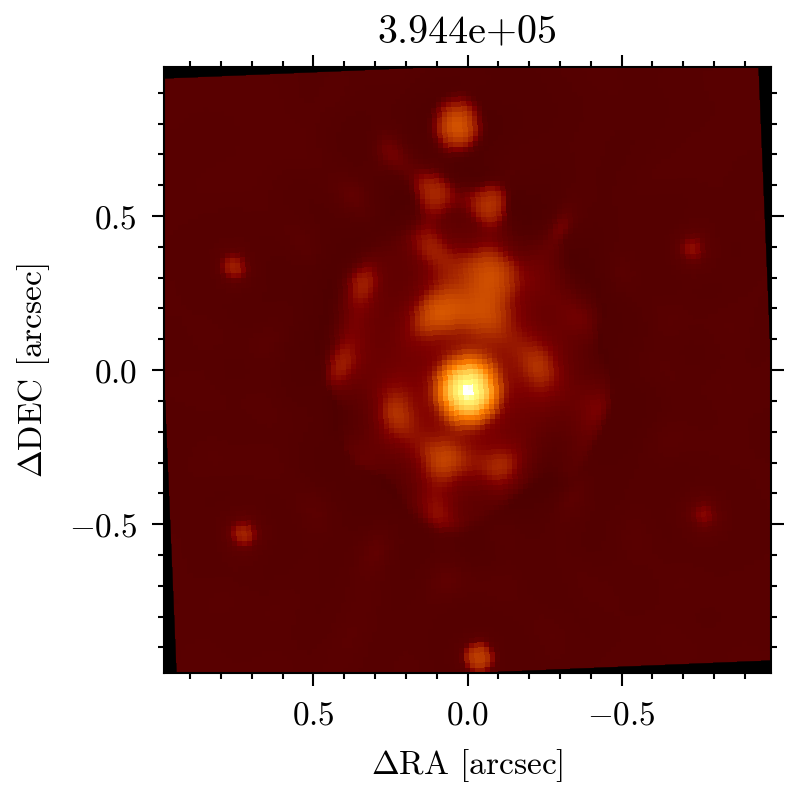

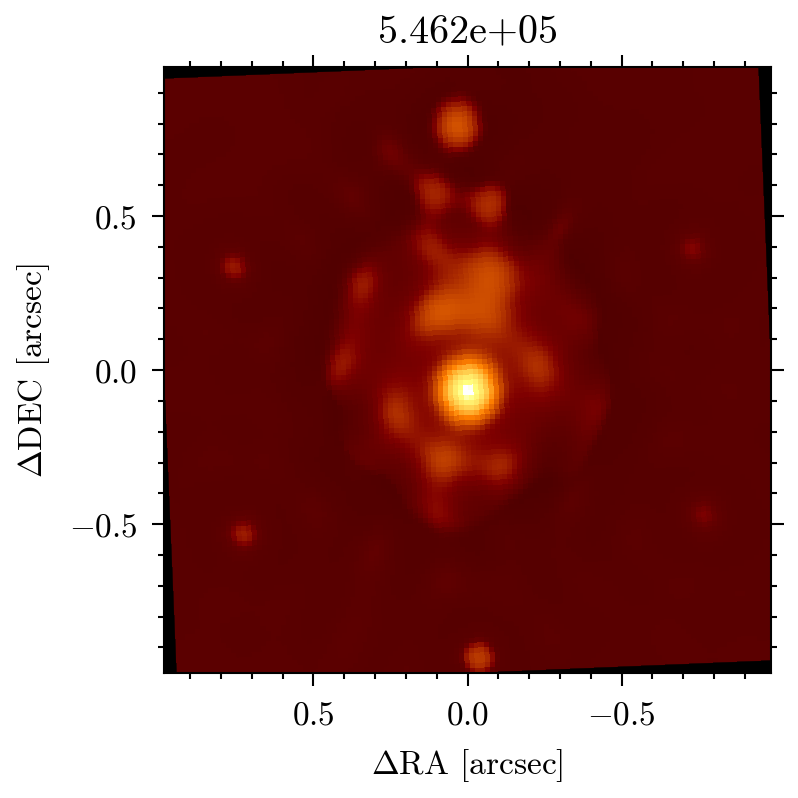

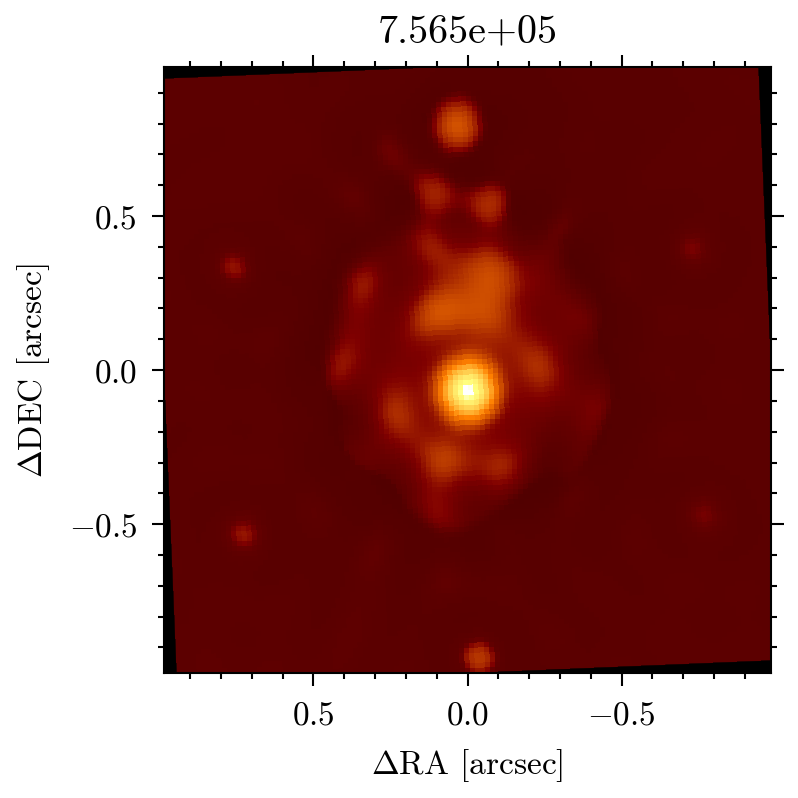

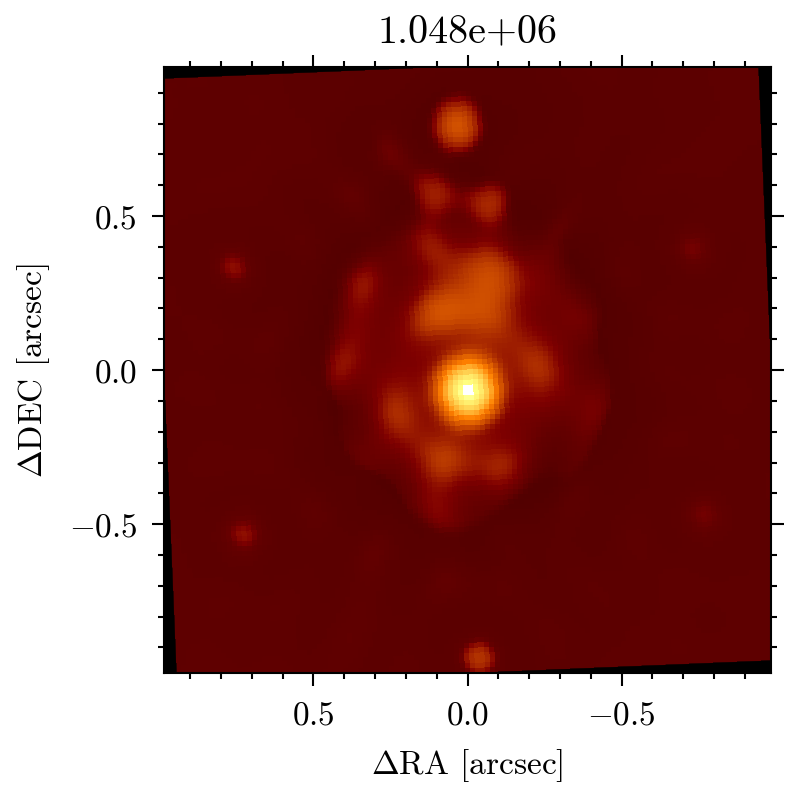

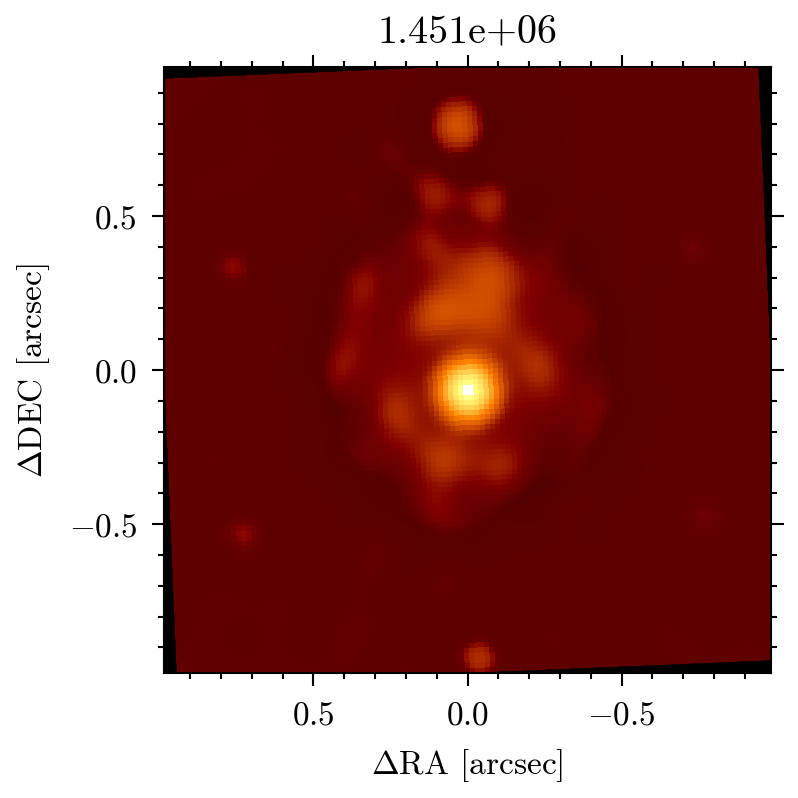

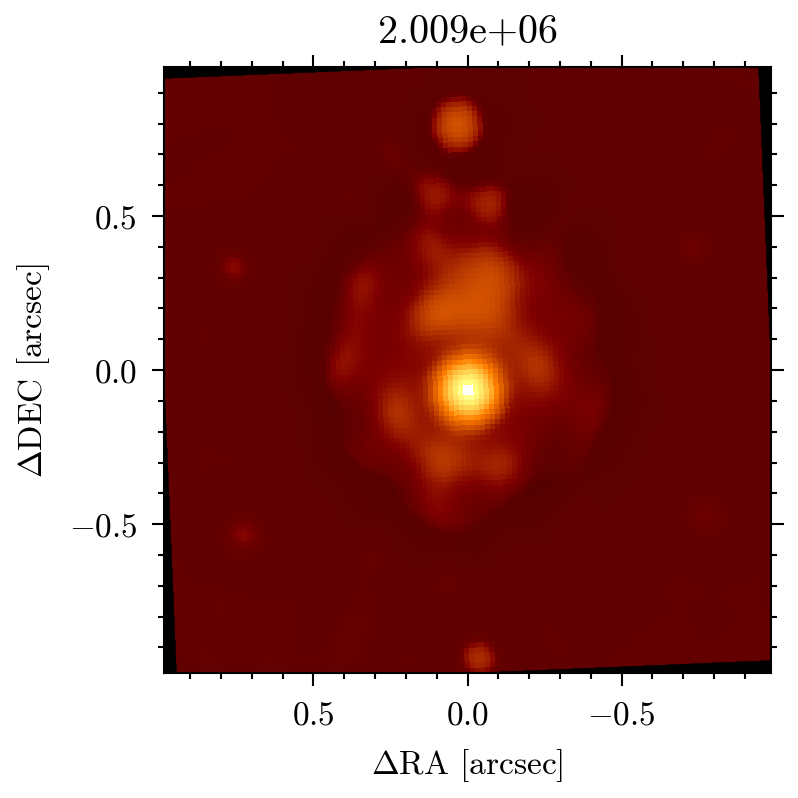

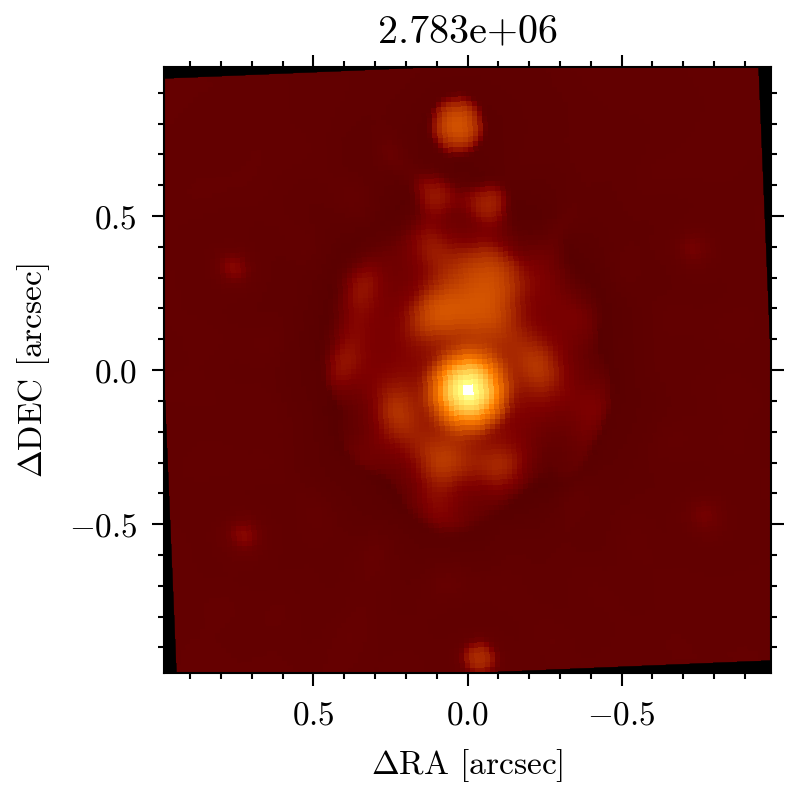

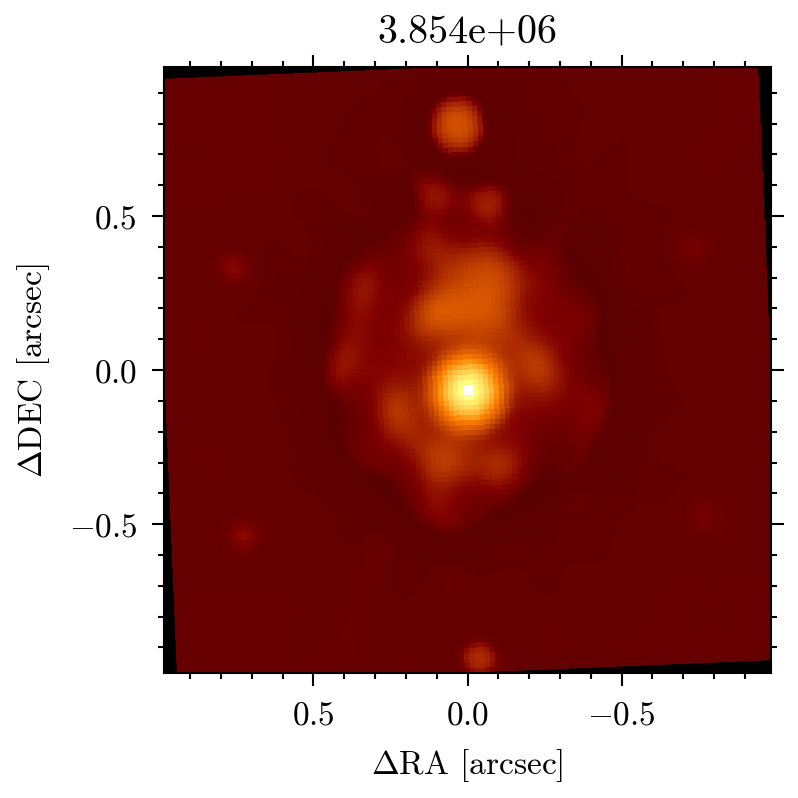

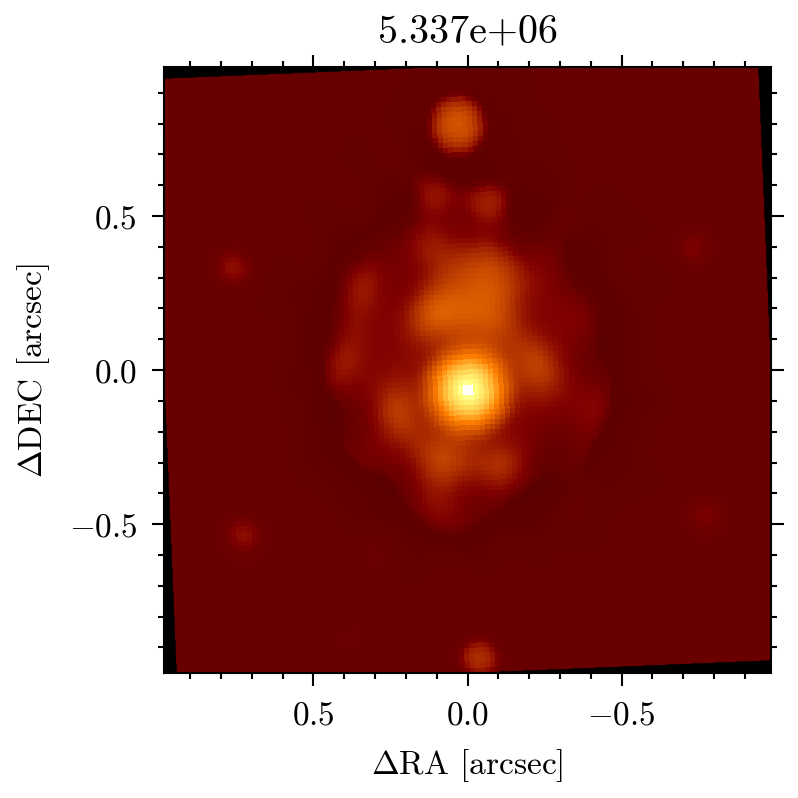

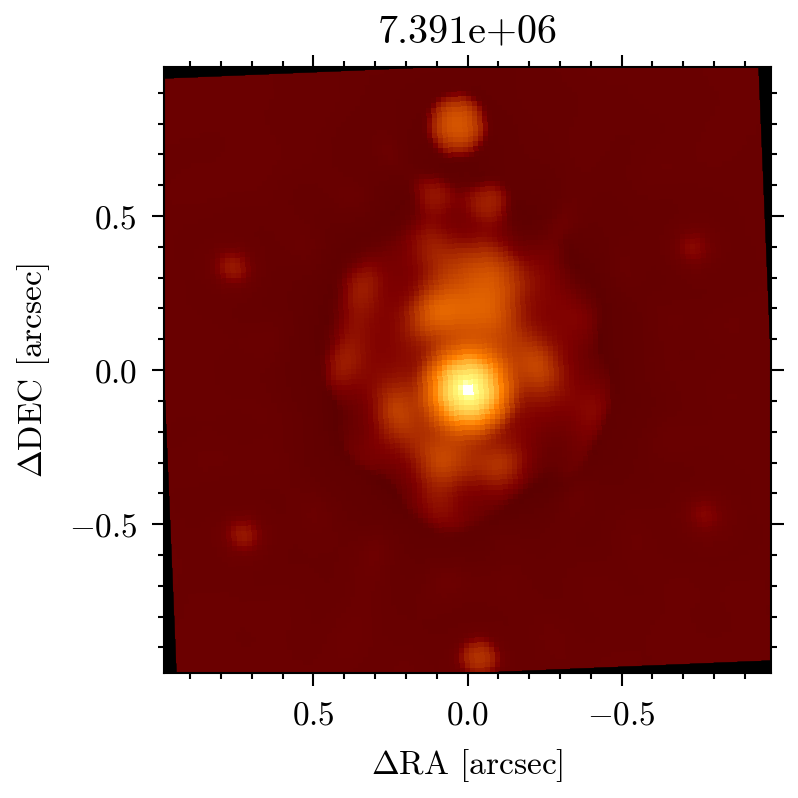

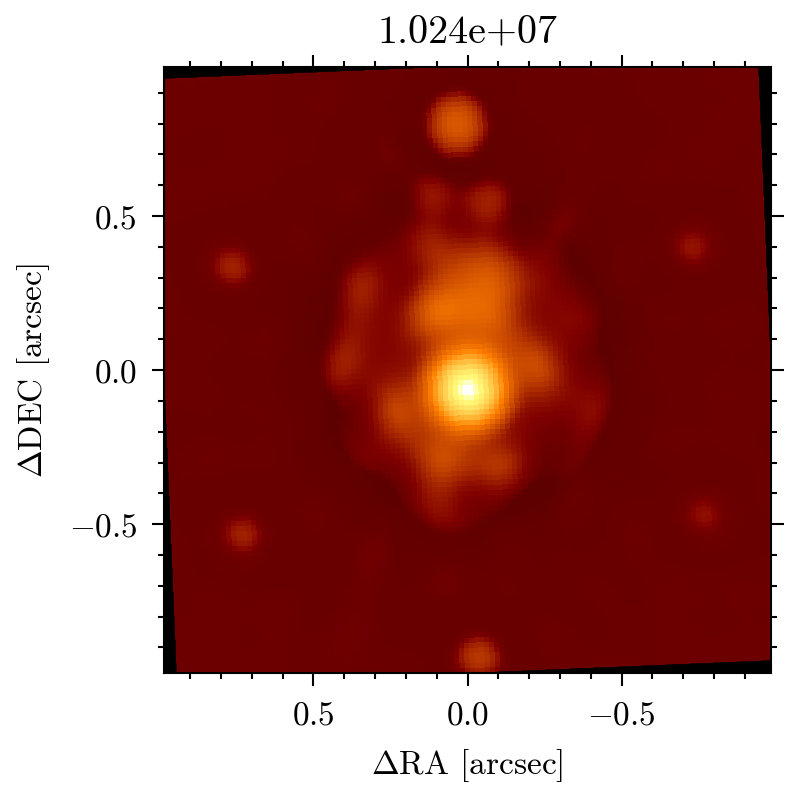

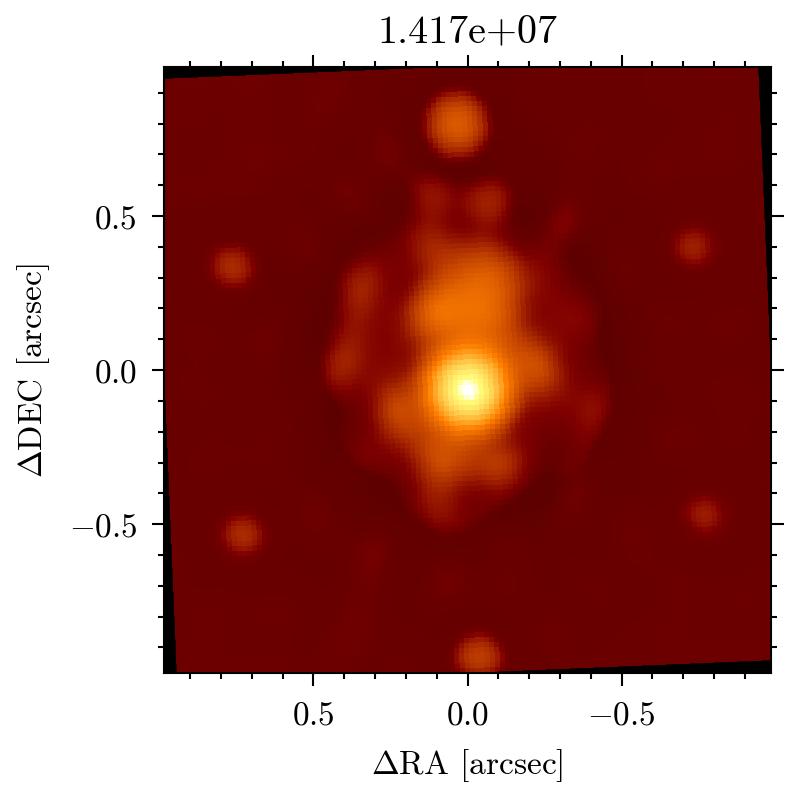

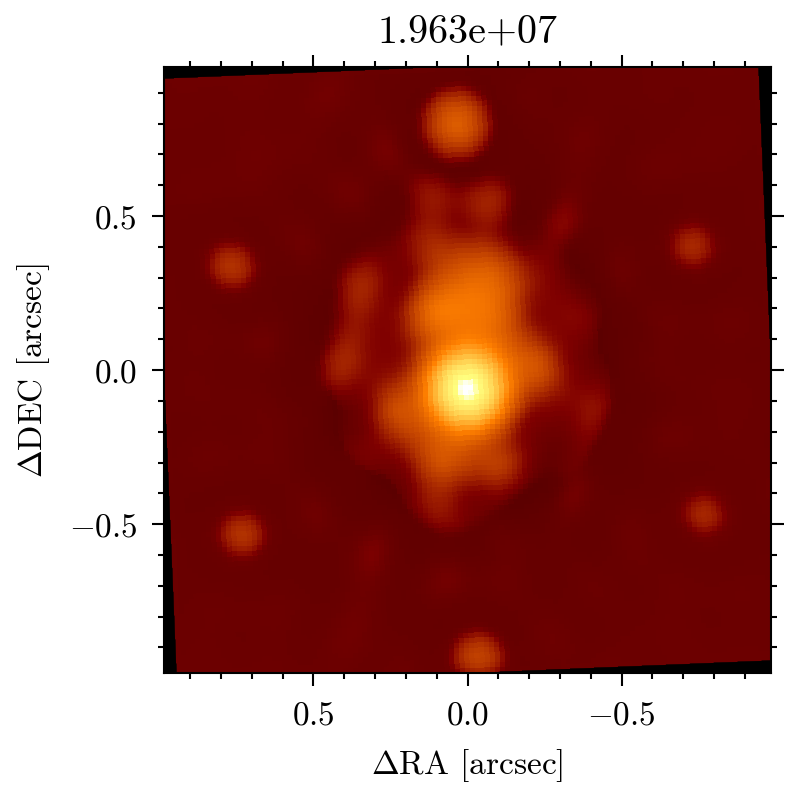

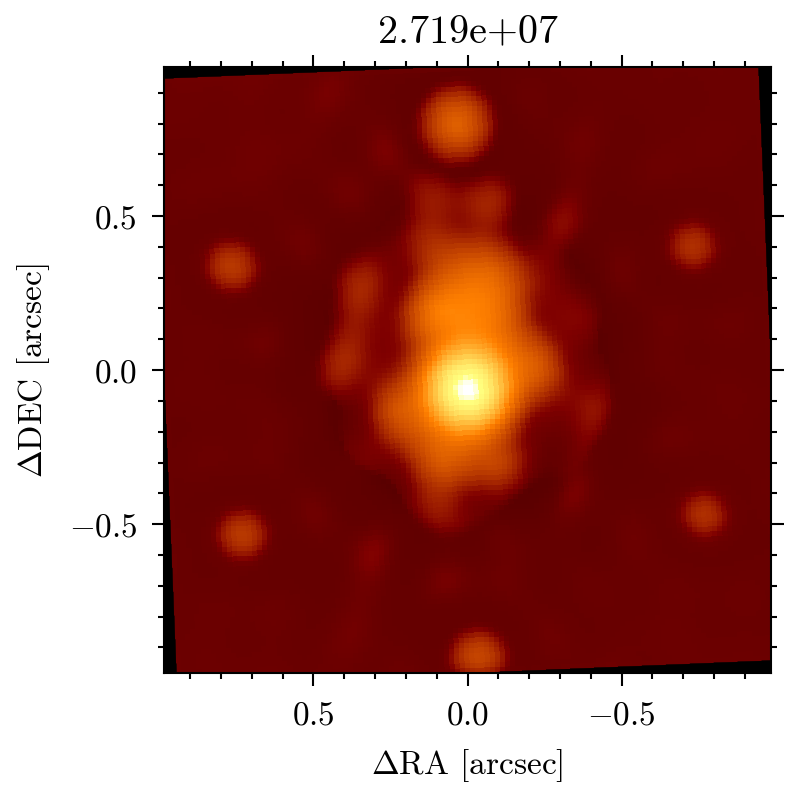

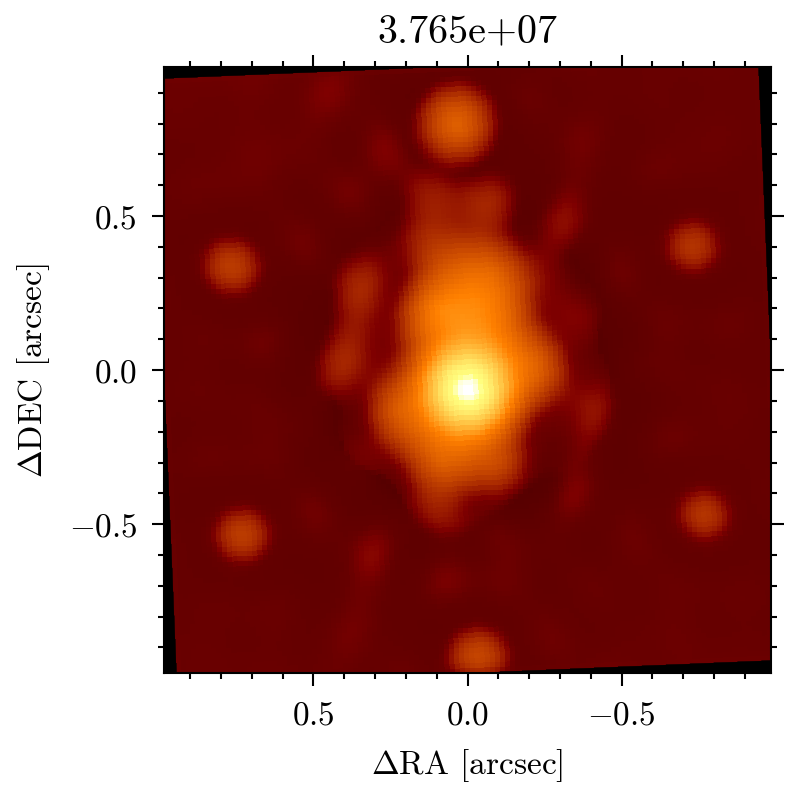

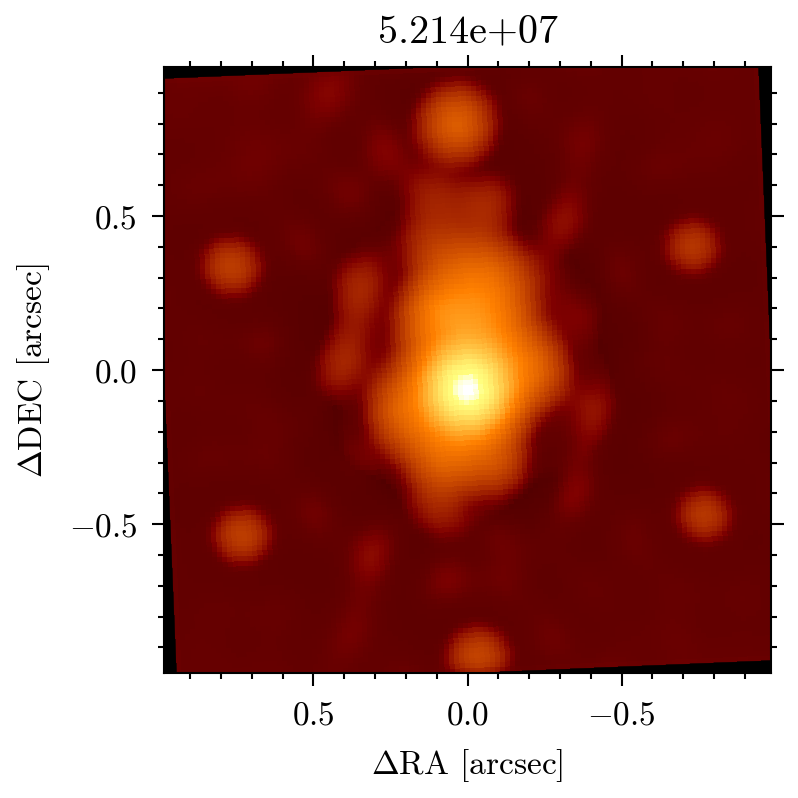

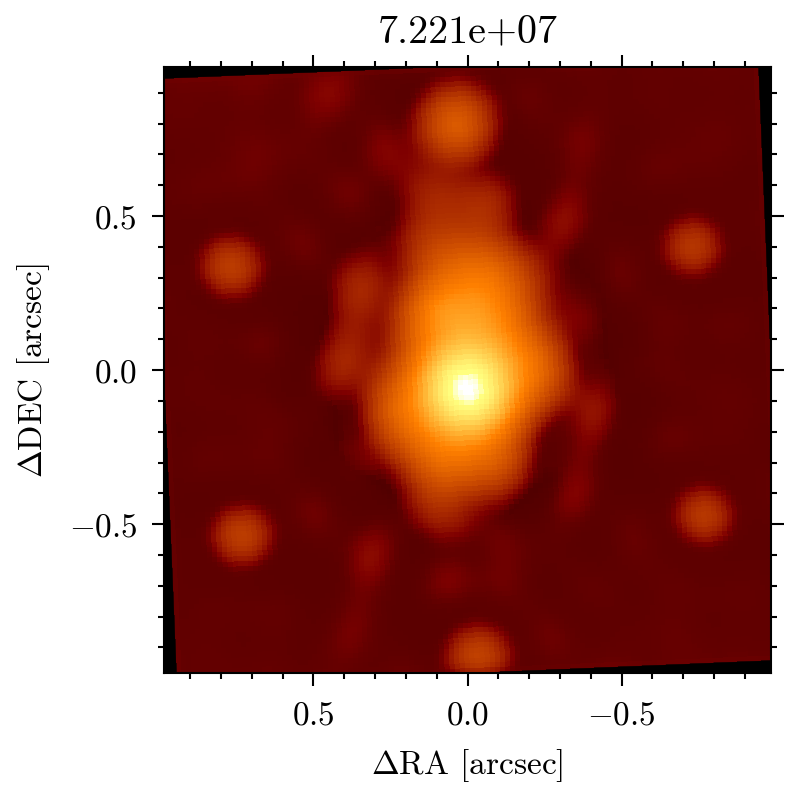

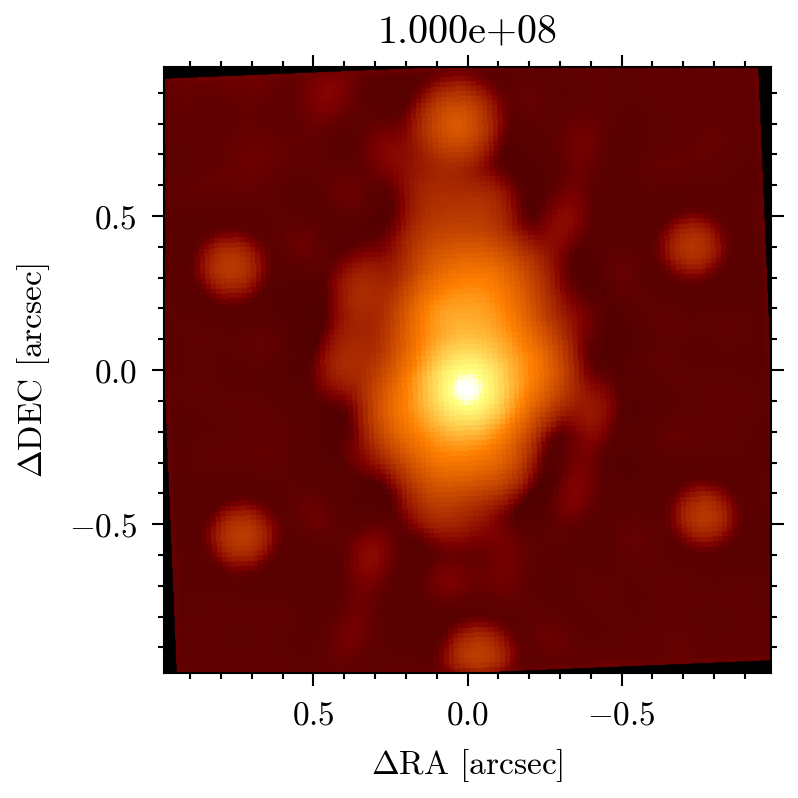

In [63]:
for i, l in enumerate(log_dists):
    # plt.imshow(10 ** l["F480M"], norm=mpl.colors.PowerNorm(0.5), cmap="afmhot_10u")
    fig, ax = plt.subplots(1, 1)
    c0 = dorito.plotting.plot_result(
        ax,
        10 ** l["F480M"],
        roll_angle_degrees=-rolls[fits[0].filename],
        cmap="afmhot_10u",
        power=0.3,
        # model=final_model,
        # vmin=None,
        # show_diff_lim=True,
        # vmax=io_peak_flux,
    )
    plt.title(f"{coeffs[i]:.3e}")
    plt.show()

In [33]:
sweep, coeffs, log_dists = dorito.stats.lcurve_sweep(
    "L2",
    np.logspace(-13, -8, 15),
    model,
    fits,
    args,
    config,
    fishers,
    # args=args,
    norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    # loss_fn=zdx.combine,
    # epochs=n_epoch,
    epochs=400,
    eps=1e-2,
    print_grads=False,
)

  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 1,290.18
Est time per epoch:  0:00:00
Est run time:  0:01:46
Convergence reached on 325 th epoch, exiting loop


  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 1,290.18
Est time per epoch:  0:00:00
Est run time:  0:01:49
Convergence reached on 325 th epoch, exiting loop


  0%|          | 0/400 [00:00<?, ?it/s]

...

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 1,290.32
Est time per epoch:  0:00:00
Est run time:  0:01:53
Full Time: 0:01:52
Final Loss: 126.42


  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 1,290.88
Est time per epoch:  0:00:00
Est run time:  0:01:53
Full Time: 0:01:50
Final Loss: 219.81


  0%|          | 0/400 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:03
Initial Loss: 1,293.77
Est time per epoch:  0:00:00
Est run time:  0:01:51
Full Time: 0:01:52
Final Loss: 372.22


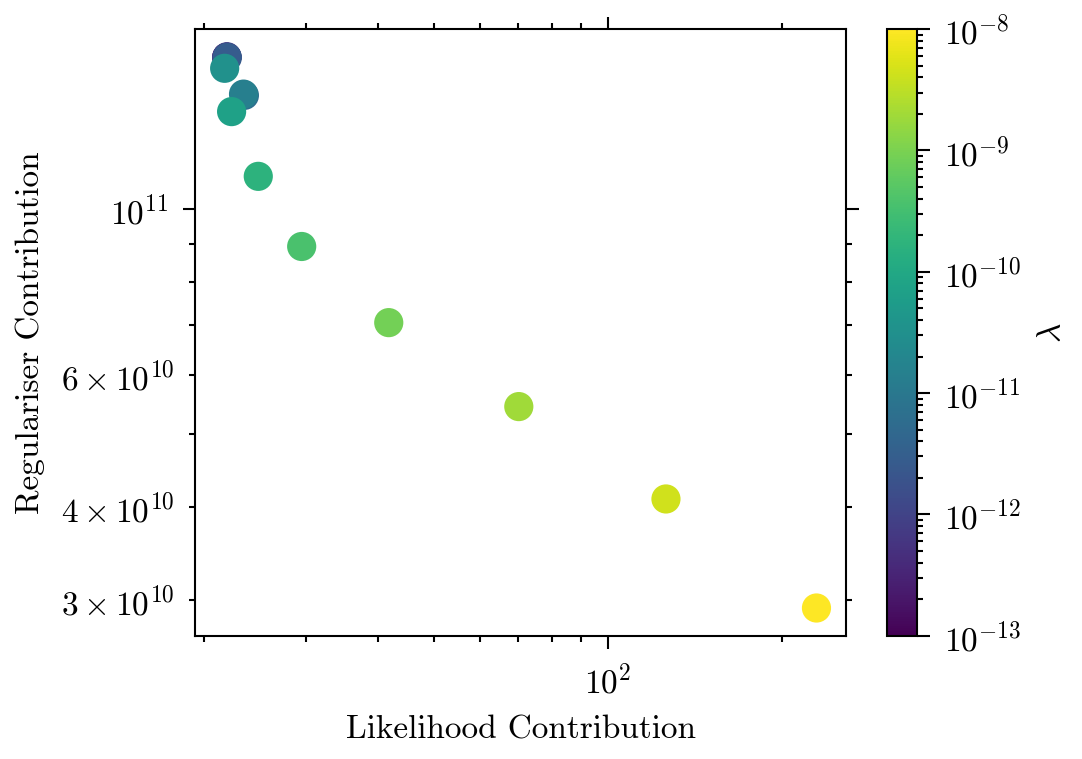

In [34]:
plt.figure()
plt.scatter(
    sweep[0],
    sweep[1],
    c=coeffs,
    cmap="viridis",
    norm=mpl.colors.LogNorm(),
)

plt.xscale("log")
plt.yscale("log")
plt.colorbar(label=r"$\lambda$")
plt.xlabel("Likelihood Contribution")
plt.ylabel("Regulariser Contribution")
plt.show()

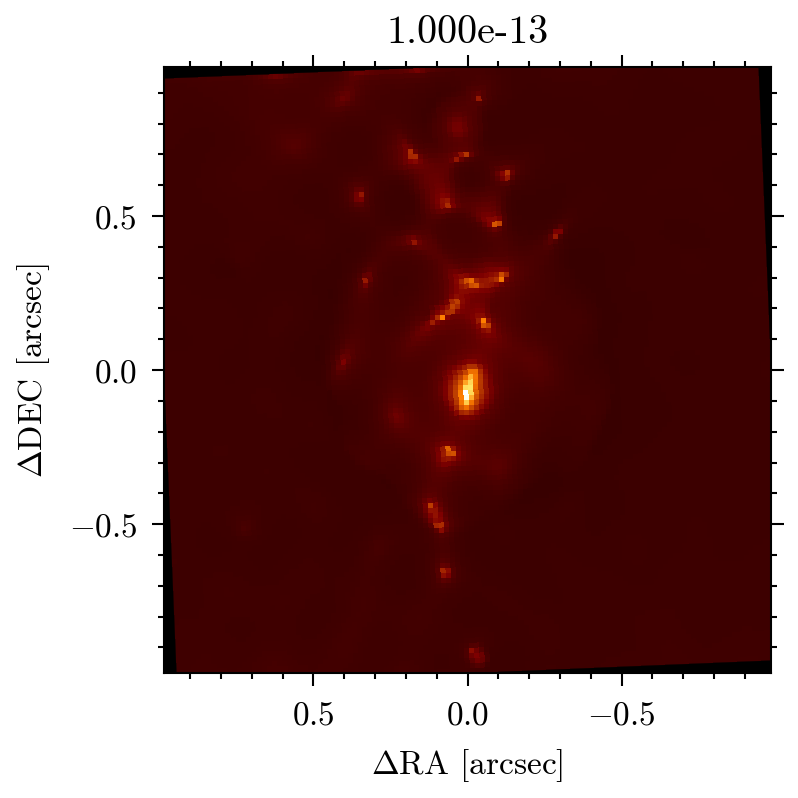

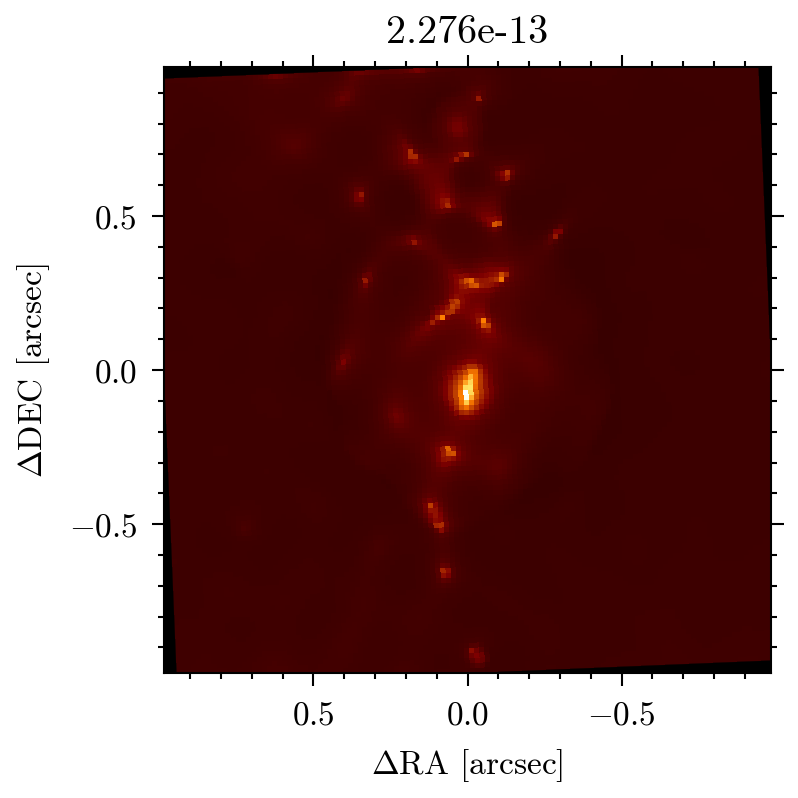

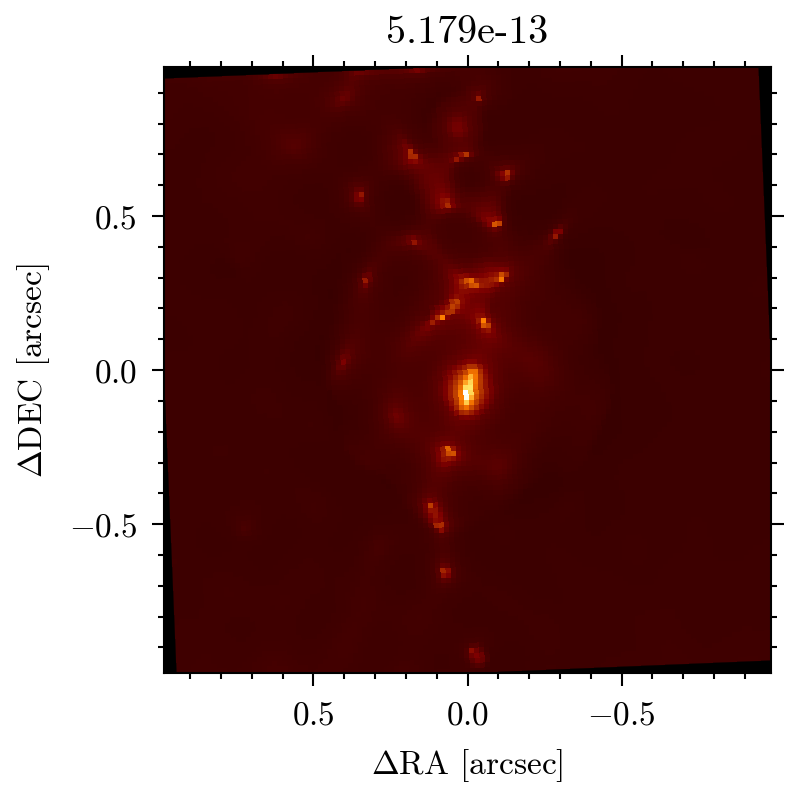

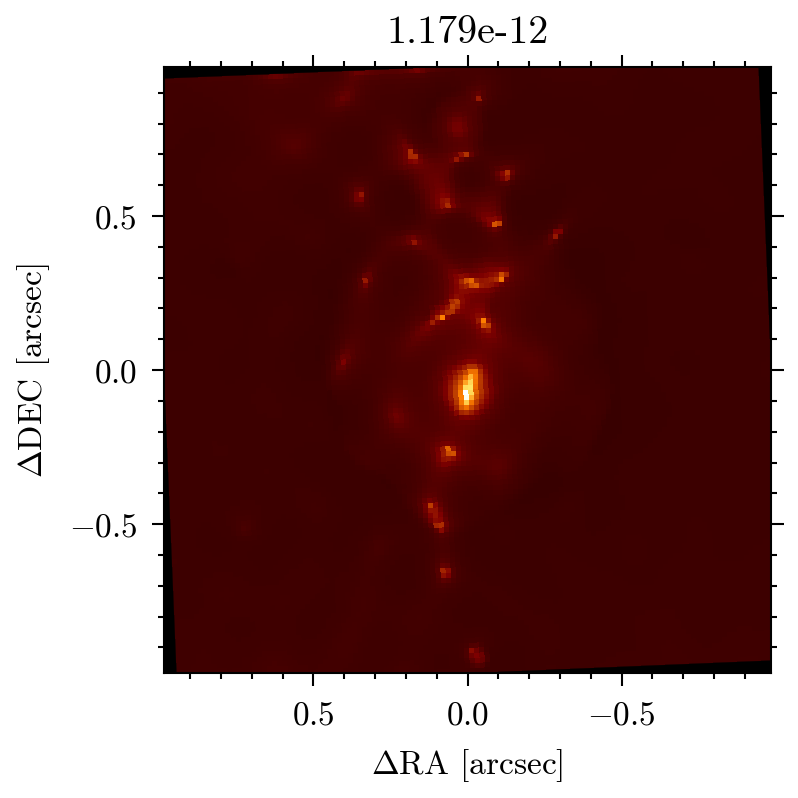

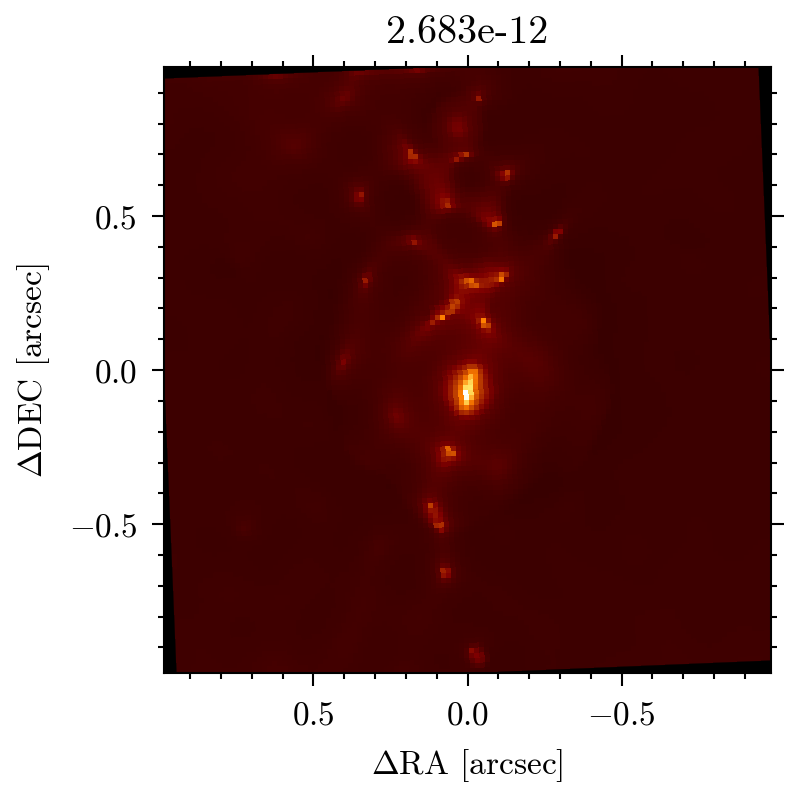

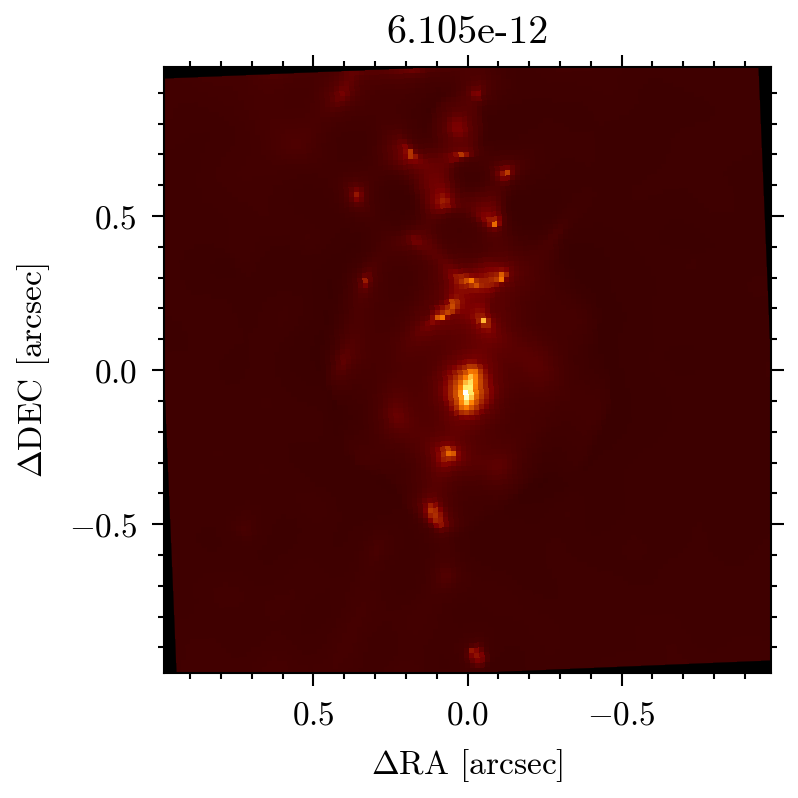

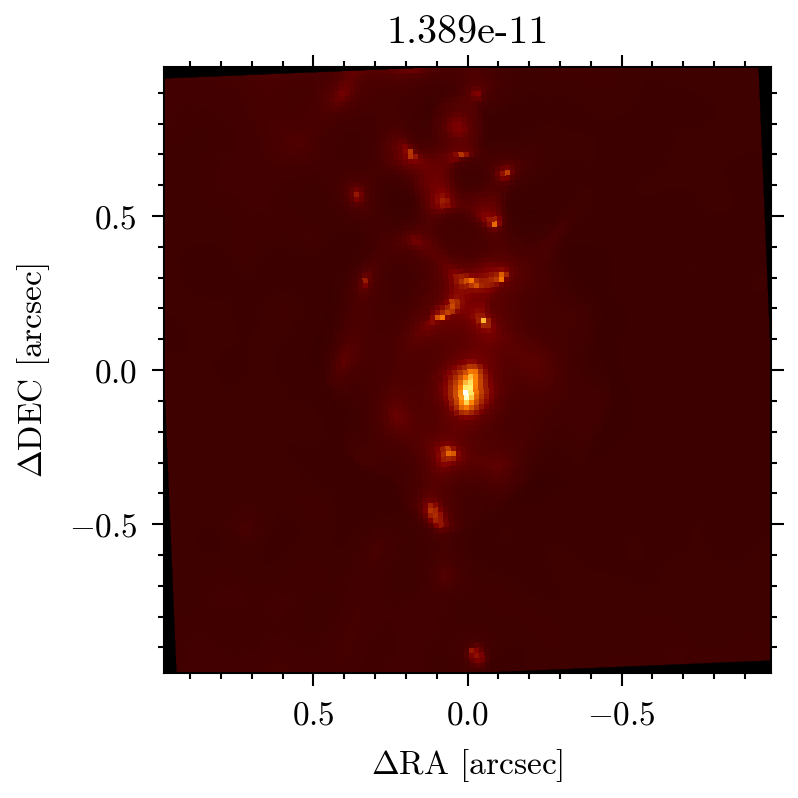

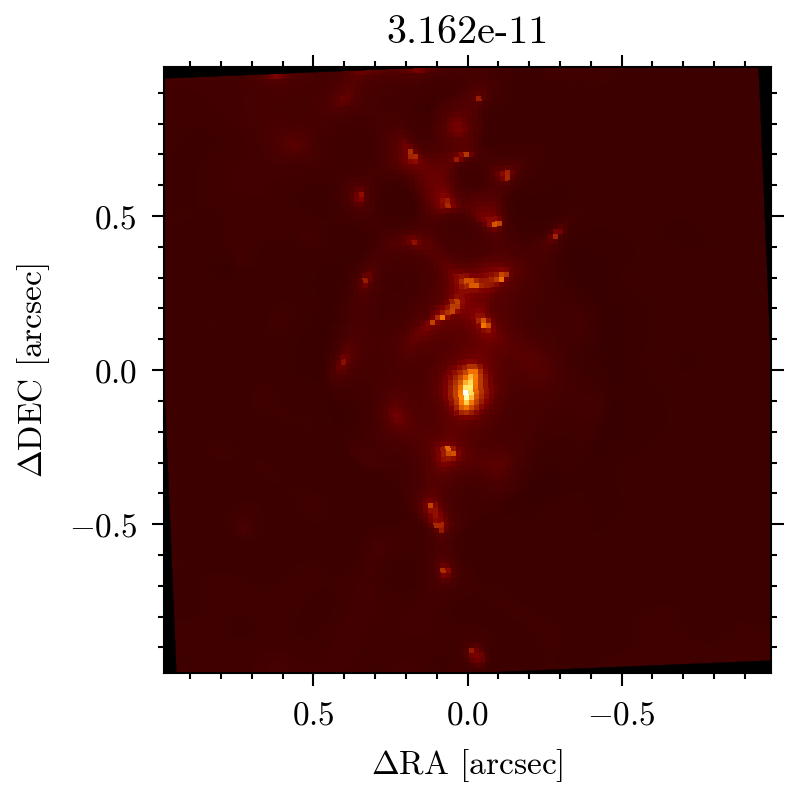

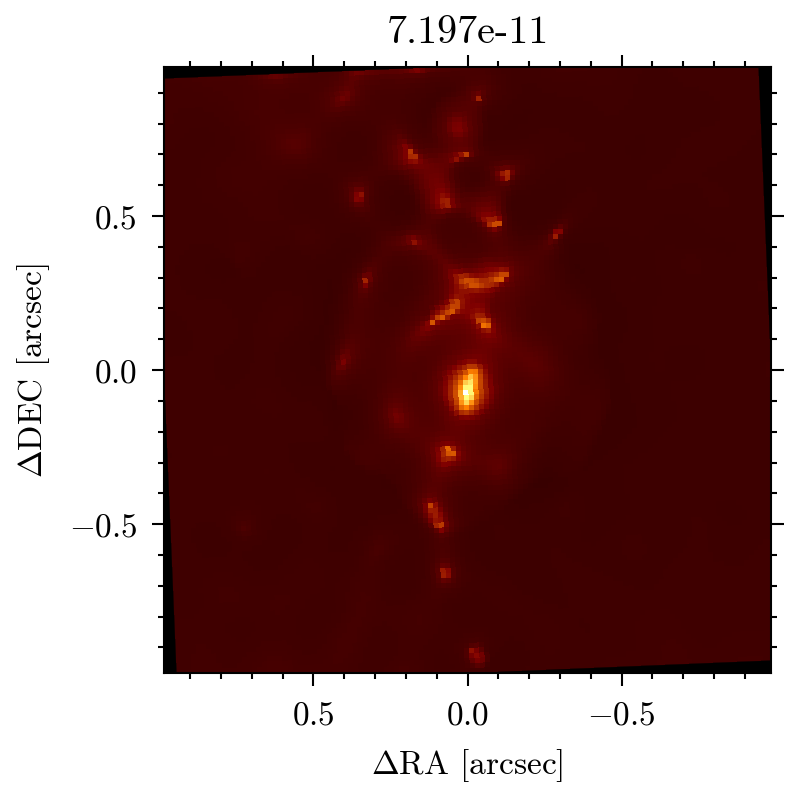

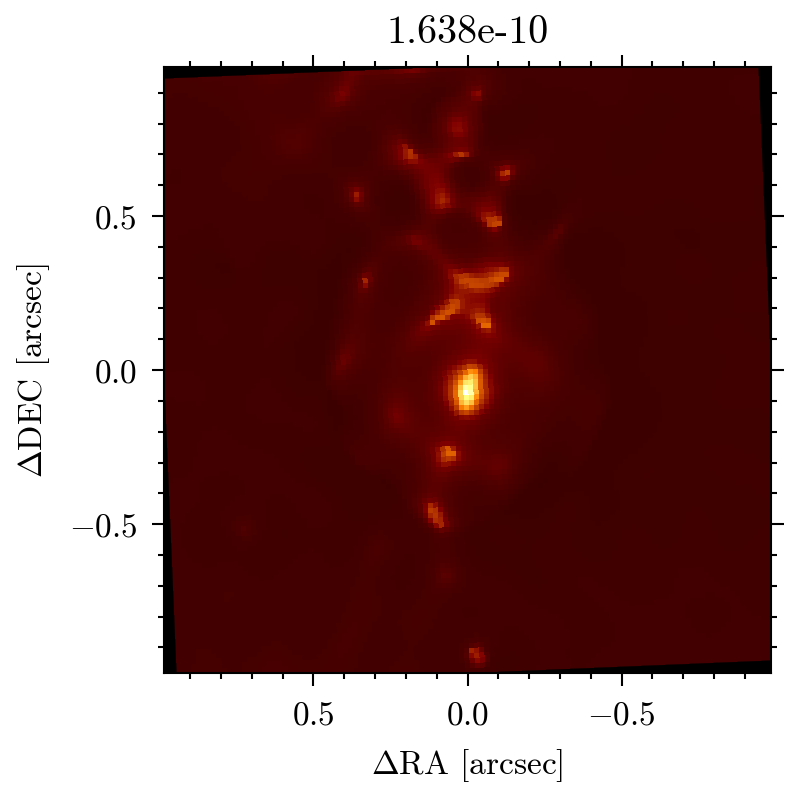

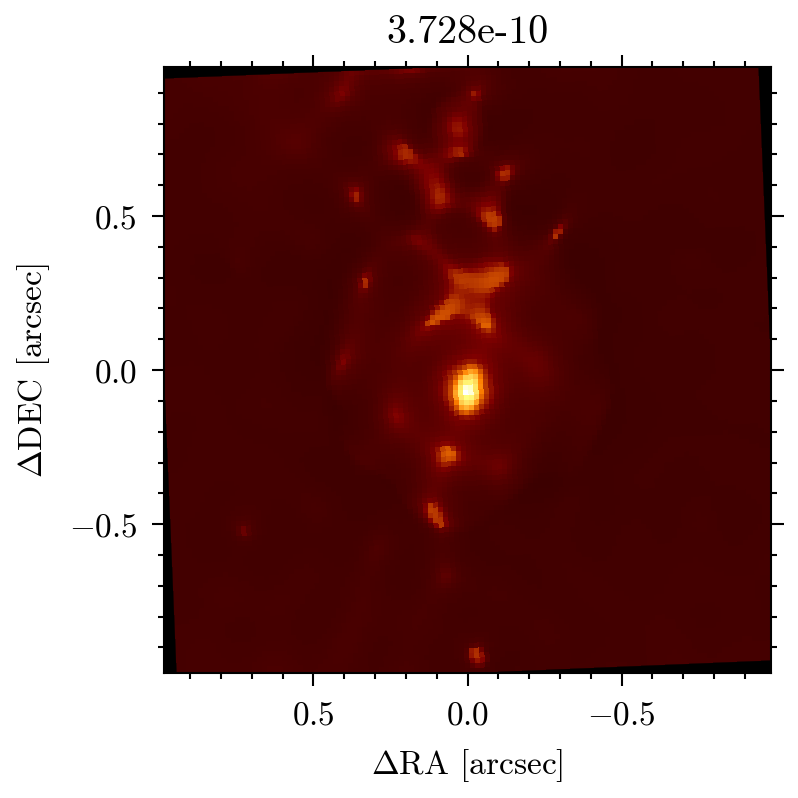

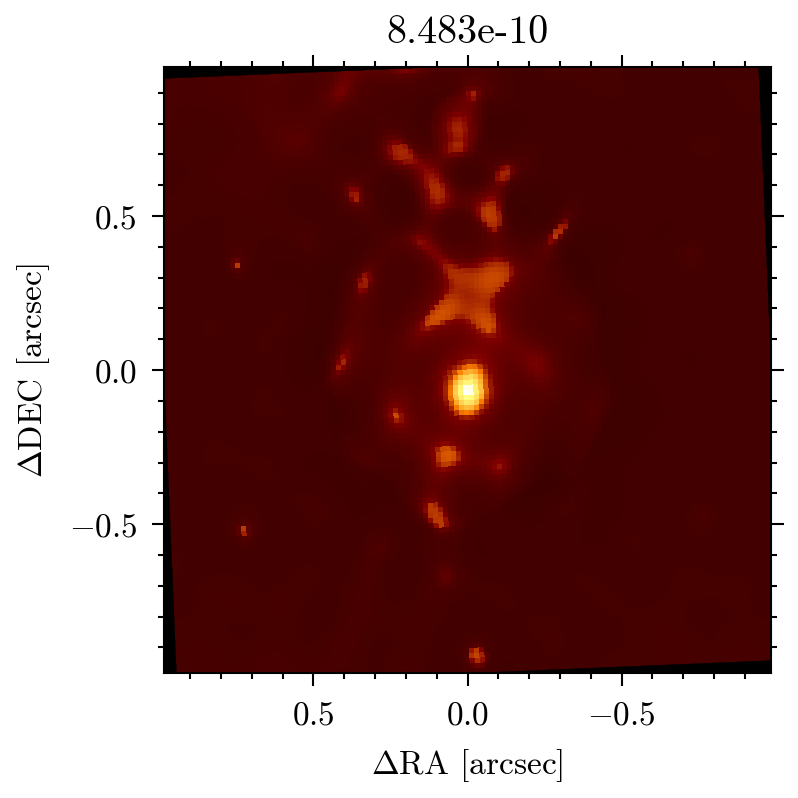

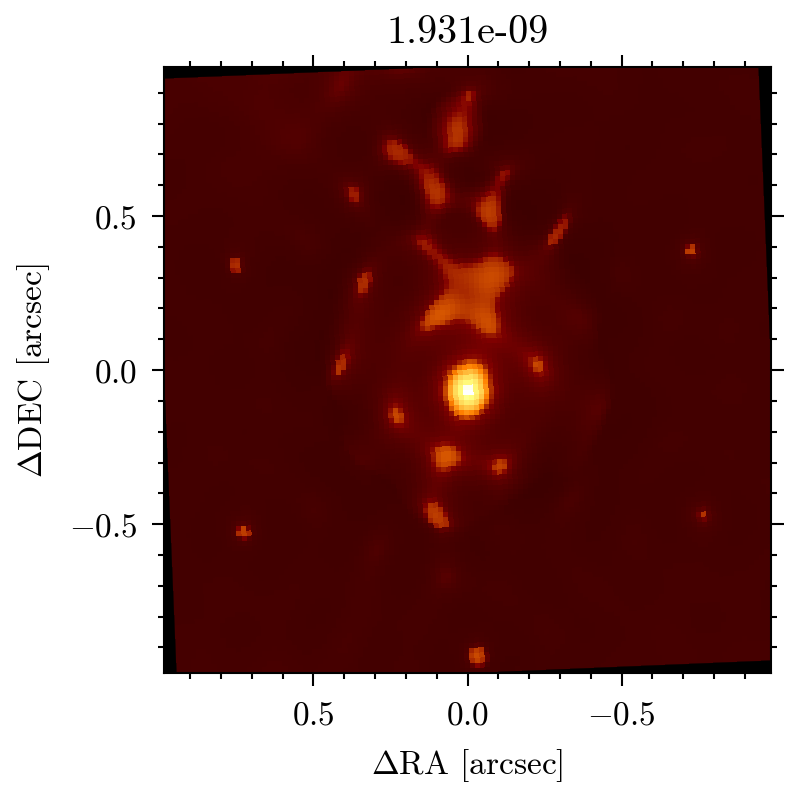

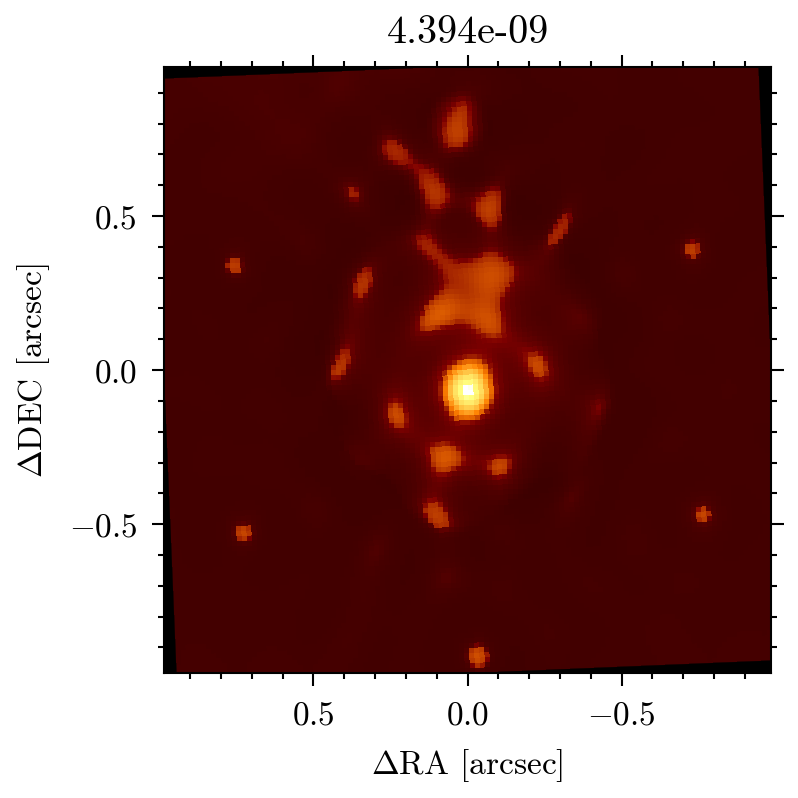

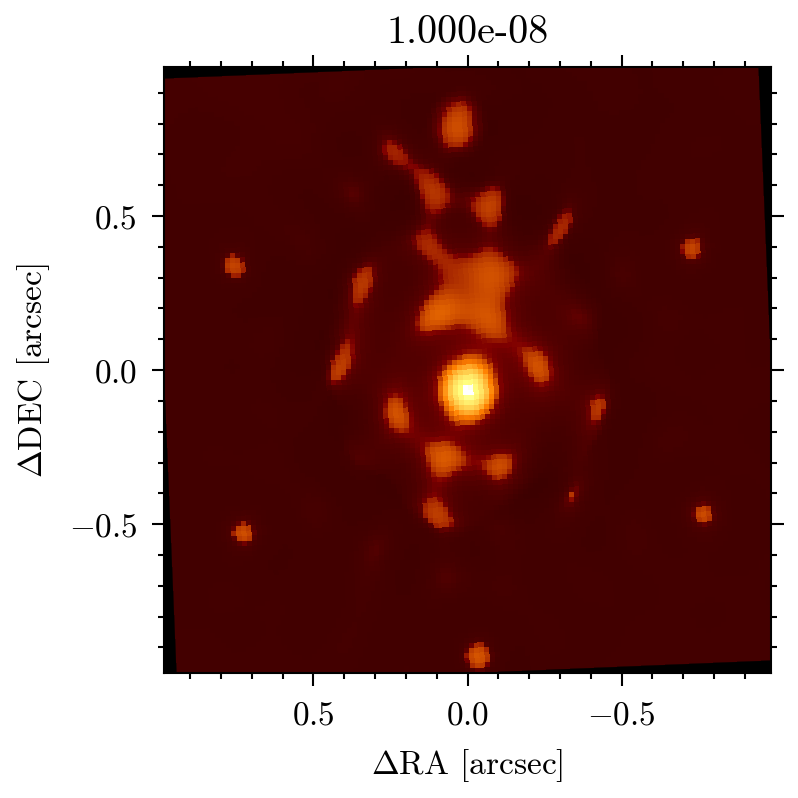

In [35]:
for i, l in enumerate(log_dists):
    # plt.imshow(10 ** l["F480M"], norm=mpl.colors.PowerNorm(0.5), cmap="afmhot_10u")
    fig, ax = plt.subplots(1, 1)
    c0 = dorito.plotting.plot_result(
        ax,
        10 ** l["F480M"],
        roll_angle_degrees=-rolls[fits[0].filename],
        cmap="afmhot_10u",
        power=0.3,
        # model=final_model,
        # vmin=None,
        # show_diff_lim=True,
        # vmax=io_peak_flux,
    )
    plt.title(f"{coeffs[i]:.3e}")
    plt.show()